In [ ]:
import marimo as mo

# QoS-HRGN v2: Heterogeneous Adaptive Graph Learning for BraTS 3D Segmentation

**Pipeline**

`BraTS MRI → modality-specific 3D SLIC (T1ce / FLAIR partitions) → heterogeneous supervoxel graph → HGT → adaptive multi-hop propagation → pathology-aware prediction → voxel reconstruction`

**What changed from v1 (400-segment notebook) and why**

The v1 run showed node-level Dice ≈ 0.78 but voxel-level Dice of only WT 0.45 / TC 0.33 / ET 0.24.
That gap is a *graph-construction* problem, not a graph-learning problem. v2 fixes the construction:

| # | Change | Reason |
|---|---|---|
| 1 | `N_SEGMENTS` 400 → **15 000** (Saueressig et al. optimum on BraTS) | 400 supervoxels ≈ 15 mm bricks; ET is a thin rim of a few thousand voxels and cannot be drawn at that resolution. |
| 2 | Hard priority labels → **fractional (soft) labels** per node | Priority labelling made ET 3.7× more frequent than NCR at node level (opposite of reality) and painted whole bricks ET at reconstruction → low ET precision. |
| 3 | 6 single-modality features → **32 features from all four modalities** (mean, std, 5 quantiles each + position + size) | A T1ce node could not see FLAIR (edema) and vice-versa; T1/T2 were loaded and discarded. |
| 4 | Centroid-matched cross edges → **voxel-overlap cross edges** with overlap fraction as edge attribute | Overlap is the natural correspondence between two partitions of the same volume; gives 3–8 typed edges per node instead of 1. |
| 5 | **Oracle / ASA cells** | Reconstructing from ground-truth node labels shows the ceiling of a partition; if the ceiling is low the model cannot be blamed. |
| 6 | Model selection on **per-patient volume-weighted Dice** (= voxel Dice under node-constant predictions), ET small-volume post-processing, hidden 64→128, residual HGT, cosine LR, 80 epochs | v1 selected on batched node Dice which does not track voxel Dice. |

BraTS 2020 facts used here: 369 training cases (293 HGG, 76 LGG), 240×240×155 at 1 mm³, co-registered and skull-stripped; labels 0 = background, 1 = NCR/NET, 2 = ED, 4 = ET; evaluated on ET, TC = NCR/NET ∪ ET and WT = TC ∪ ED. Many LGG cases have **no ET at all**, which is why ET post-processing matters.

## 1. Imports and configuration

Every tunable lives in this cell. `N_SEGMENTS` and `COMPACTNESS` define the graph cache; changing either builds a new cache directory.

In [ ]:
# packages added via marimo's package management: torch-geometric nibabel scikit-image matplotlib kagglehub scipy joblib
import os, glob, re, random, time, math
import numpy as np
import matplotlib.pyplot as plt
import nibabel as nib
import torch
import torch.nn as nn
import torch.nn.functional as F
from skimage.segmentation import slic
from torch_geometric.data import HeteroData
from torch_geometric.nn import HGTConv
from torch_geometric.loader import DataLoader
from joblib import Parallel, delayed
import kagglehub

print("PyTorch:", torch.__version__)
try:
    import torch_geometric
    print("PyG:", torch_geometric.__version__)
except Exception:
    pass

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# ── Graph construction ───────────────────────────────────────
N_SEGMENTS = 15000
COMPACTNESS = 0.3
SLIC_ITERS = 10
MIN_OVERLAP = 0.05
NODE_TYPES = ("t1ce", "flair")
MODALITIES = ("t1", "t1ce", "t2", "flair")
QUANTILES = (0.10, 0.25, 0.50, 0.75, 0.90)
NODE_FEAT_DIM = len(MODALITIES) * (2 + len(QUANTILES)) + 4
GRAPH_VERSION = 3

# ── Model / training ─────────────────────────────────────────
HIDDEN_DIM = 128
HEADS = 4
HGT_LAYERS = 2
HOPS = 2                    # fixed-hop baseline when USE_ADAPTIVE_HOPS=False
USE_ADAPTIVE_HOPS = True    # proposed node-wise learned receptive-field depth
K_MAX = 4                   # candidate depths are k=0,...,K_MAX
HOP_REG_WEIGHT = 0.002      # small expected-hop cost; discourages always choosing K_MAX
HOP_TEMPERATURE = 1.0       # softmax temperature; keep 1.0 for the main experiment
DROPOUT = 0.1
EPOCHS = 100
BATCH_SIZE = 8
LR = 1e-3
WEIGHT_DECAY = 1e-4
DICE_WEIGHT = 1.0
REGION_DICE_WEIGHTS = (1.0, 1.0, 1.5)   # (WT, TC, ET) weights inside region_dice_loss;
                                          # ET was previously averaged in as an equal 1/3
                                          # share despite being the hardest and rarest region

# ── Evaluation ───────────────────────────────────────────────
ET_MIN_VOXELS = 300         # starting default; RE-TUNED on VAL by the sweep cell
ET_SWEEP_VALUES = (0, 50, 100, 150, 200, 300, 500, 800)

# ── Oracle sweep ─────────────────────────────────────────────
ORACLE_CASES = 4
ORACLE_SWEEP = (400, 4000, 15000)

# ── Voxel refinement head ─────────────────────────────────────
USE_VOXEL_REFINEMENT = True
VOXEL_EPOCHS = 60             # was 40; val Dice was still improving at 40
VOXEL_LR = 1e-3
VOXEL_BASE_CHANNELS = 48      # was 32
VOXEL_DICE_WEIGHT = 1.0
VOXEL_FOCAL_WEIGHT = 0.5
VOXEL_FOCAL_GAMMA = 2.0
VOXEL_MARGIN = 10             # margin around the GT box (TRAINING only)
VOXEL_MAX_SIZE = 160          # was 128; less truncation of large tumours
VOXEL_PRED_MARGIN = 16        # margin around the PREDICTED box (inference)
VOXEL_TTA = True              # 8x flip test-time augmentation at inference
#
# LEAKAGE GUARD. The refinement window must be derived from the model's OWN
# prediction at evaluation time. Setting this True reproduces the previous
# (invalid) behaviour where the ground-truth tumour box was handed to the
# model at test time; it is kept only to quantify the size of that leak.
VOXEL_USE_GT_BOX_AT_EVAL = False

# ── Focal loss for the graph model ────────────────────────────
ET_FOCAL_WEIGHT = 0.5
FOCAL_GAMMA = 2.0
ET_FOCAL_CLASS_BOOST = 2.0   # extra multiplier on the ET term inside focal_loss_soft.
                              # Previously this loss weighted all 4 classes identically
                              # despite the "ET_FOCAL_WEIGHT" name -- it gave ET no more
                              # attention than BG/NCR/ED. Set to 1.0 to restore old behaviour.

# ── Connected-component post-processing ──────────────────────
USE_CC_POSTPROCESS = True

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
USE_AMP = device.type == "cuda"
if USE_AMP:
    torch.set_float32_matmul_precision("high")
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32 = True

print("Device:", device)
if USE_AMP:
    print("GPU:", torch.cuda.get_device_name(0))
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} GB")
print(f"\n{'='*60}")
print(f"  QoS-HRGN Config: N_SEGMENTS={N_SEGMENTS}  FEATURES={NODE_FEAT_DIM}")
print(f"  Adaptive hops={USE_ADAPTIVE_HOPS}  candidates=0..{K_MAX if USE_ADAPTIVE_HOPS else HOPS}")
print(f"{'='*60}\n")

PyTorch: 2.11.0+cu130
PyG: 2.8.0.post1
Device: cuda
GPU: NVIDIA RTX PRO 6000 Blackwell Server Edition
VRAM: 95.0 GB

  QoS-HRGN Config: N_SEGMENTS=15000  FEATURES=32
  Adaptive hops=True  candidates=0..4



## 1b. Option B configuration

In [ ]:
# ============================================================
# Option B: Structure-Aware Graph Refinement — configuration
# ------------------------------------------------------------
# Research ablation on top of the existing QoS-HRGN backbone. Set
# USE_STRUCTURAL_REFINEMENT = False to run the exact original baseline
# unchanged (nothing below in this cell affects that path). When True, an
# additional lightweight module analyses the STRUCTURE of the model's own
# predicted tumour graph -- not just node/edge features -- and uses it to
# refine the final classification (see the model cell below).
#
# We do NOT assume any structural relationship (e.g. "ET encloses NCR") is
# a universal biological rule. These are measurable graph properties the
# refinement module is free to learn to use, or to ignore.
USE_STRUCTURAL_REFINEMENT = False

# Individual descriptor toggles, so ablations can show WHICH structural
# signal (if any) actually helps.
STRUCTURAL_USE_NEIGHBOR_STATS = True    # tumour-neighbour / ET-neighbour fraction
STRUCTURAL_USE_DISTANCE = True          # hop-distance to nearest predicted ET / nearest predicted BG
STRUCTURAL_USE_COMPONENT_SIZE = True    # size of the predicted-tumour connected component
STRUCTURAL_USE_ENCLOSURE = True         # ET-neighbour fraction minus BG-neighbour fraction
STRUCTURAL_USE_CROSS_MODAL = True       # T1ce<->FLAIR correspondence fan-out

STRUCTURAL_HIDDEN = 32     # width of the structural MLP -- kept small on purpose
STRUCTURAL_DROPOUT = 0.1
STRUCTURAL_AUX_WEIGHT = 0.3   # loss = hierarchy_loss(final) + STRUCTURAL_AUX_WEIGHT * hierarchy_loss(initial)
                               # keeps the base model's OWN initial predictions well-calibrated,
                               # since the structural descriptors are derived from them, and avoids
                               # turning this into "a second, independent classifier."

# Scheduled sampling for structural context (the exposure-bias fix). Early in
# training, structural descriptors are computed mostly from ground-truth
# labels (a clean signal to bootstrap the refinement module). As training
# progresses we shift towards the model's OWN predicted labels, so the module
# learns to correct genuinely noisy structure rather than just to trust
# already-correct GT structure. GT is NEVER used for structural context
# outside of training -- validation/test always call with teacher_prob=0.0.
STRUCTURAL_TEACHER_PROB_START = 1.0
STRUCTURAL_TEACHER_PROB_END = 0.0

def structural_teacher_prob(epoch, total_epochs=EPOCHS):
    """Linear decay from STRUCTURAL_TEACHER_PROB_START to _END over training."""
    if total_epochs <= 1:
        return STRUCTURAL_TEACHER_PROB_END
    frac = min(max((epoch - 1) / (total_epochs - 1), 0.0), 1.0)
    return STRUCTURAL_TEACHER_PROB_START + (STRUCTURAL_TEACHER_PROB_END - STRUCTURAL_TEACHER_PROB_START) * frac

STRUCTURAL_FLAGS = dict(
    neighbor_stats=STRUCTURAL_USE_NEIGHBOR_STATS,
    distance=STRUCTURAL_USE_DISTANCE,
    component_size=STRUCTURAL_USE_COMPONENT_SIZE,
    enclosure=STRUCTURAL_USE_ENCLOSURE,
    cross_modal=STRUCTURAL_USE_CROSS_MODAL,
)

def structural_descriptor_dim(flags):
    dim = 0
    if flags["neighbor_stats"]:
        dim += 2   # tumour-neighbour fraction, ET-neighbour fraction
    if flags["distance"]:
        dim += 2   # hop-distance to nearest ET, hop-distance to nearest BG
    if flags["component_size"]:
        dim += 1   # log1p(tumour connected-component size), normalised
    if flags["enclosure"]:
        dim += 1   # ET-neighbour fraction minus BG-neighbour fraction
    if flags["cross_modal"]:
        dim += 1   # normalised cross-modal correspondence fan-out
    return dim

print(f"[Option B] USE_STRUCTURAL_REFINEMENT={USE_STRUCTURAL_REFINEMENT}  "
      f"structural_dim={structural_descriptor_dim(STRUCTURAL_FLAGS)}  flags={STRUCTURAL_FLAGS}")

[Option B] USE_STRUCTURAL_REFINEMENT=False  structural_dim=7  flags={'neighbor_stats': True, 'distance': True, 'component_size': True, 'enclosure': True, 'cross_modal': True}


## 1c. Option C configuration - heterogeneous masked graph reconstruction

Auxiliary self-supervised objective added on top of the existing segmentation task:

`L_total = L_segmentation + lambda_rec * L_reconstruction`

Set `USE_MASKED_RECONSTRUCTION = False` (default) to reproduce the exact baseline run.

In [ ]:
# ============================================================
# Option C: Heterogeneous Masked Graph Reconstruction (auxiliary task)
# ------------------------------------------------------------
#   L_total = L_segmentation + lambda_rec * L_reconstruction
#
# Segmentation stays the PRIMARY objective. With REC_SEPARATE_CLEAN_PASS=True
# the segmentation loss is computed on the CLEAN graph exactly as in the
# baseline, and the reconstruction loss on a separately corrupted graph, so the
# primary objective is mathematically unchanged and the ablation is clean.
#
# Set USE_MASKED_RECONSTRUCTION = False to run the exact original baseline
# (nothing in this cell affects that path).
USE_MASKED_RECONSTRUCTION = False

LAMBDA_REC = 0.3            # weight of the auxiliary reconstruction loss
REC_WARMUP_EPOCHS = 5       # linear ramp 0 -> LAMBDA_REC, so the aux task cannot
                            # dominate before the backbone produces useful embeddings

# ---- what gets masked -------------------------------------------------------
REC_MASK_RATE = 0.30        # fraction of nodes whose APPEARANCE features are masked
REC_EDGE_MASK_RATE = 0.15   # fraction of t1ce<->flair correspondence edges held out

# ---- which reconstruction targets are enabled -------------------------------
REC_USE_FEATURE = True          # (1) masked node appearance reconstruction
REC_USE_CORRESPONDENCE = True   # (2) T1ce <-> FLAIR correspondence relation prediction
REC_USE_SPATIAL_EDGE = False    # (3) spatial edge existence -- OFF BY DEFAULT, see note
#
# WHY SPATIAL EDGE RECONSTRUCTION IS OFF BY DEFAULT
# Spatial adjacency is a DETERMINISTIC function of the SLIC tessellation, and the
# normalised centroid (feature dims 28..30) is already part of every node's input.
# Face-adjacent supervoxels are exactly those within ~one supervoxel diameter, so
# with randomly sampled negatives the task is solved by centroid distance alone
# (AUC ~= 1.0 at initialisation): it produces an impressive-looking number, no
# gradient, and no representation learning. Enabling it uses distance-matched hard
# negatives (2-hop nodes), which makes it non-trivial but largely redundant with the
# correspondence task. Kept behind a flag so the ablation can REPORT this as a
# negative result rather than omitting it silently.

REC_NEG_PER_POS = 1         # hard negatives sampled per held-out positive edge
REC_DECODER_HIDDEN = 64     # reconstruction heads are deliberately lightweight
REC_FEAT_LOSS = "smooth_l1" # "smooth_l1" | "mse" | "sce" (GraphMAE scaled cosine error)
REC_SCE_GAMMA = 2.0         # only used when REC_FEAT_LOSS == "sce"
REC_SEPARATE_CLEAN_PASS = True
#   True  -> 2 forward passes/step: clean (segmentation) + corrupted (reconstruction).
#            Primary objective identical to baseline. ~2x step time. RECOMMENDED.
#   False -> 1 forward pass: segmentation AND reconstruction from the corrupted graph.
#            Cheaper, but masked nodes have no appearance, so their segmentation
#            targets are partly unanswerable and the primary objective changes.

# ---- appearance / geometry split of the 32-dim node feature vector ----------
# node_table() builds x as: [per-modality (mean, std, 5 quantiles)] + [centroid xyz] + [log size]
STATS_PER_MODALITY = 2 + len(QUANTILES)                       # 7
APPEARANCE_DIM = len(MODALITIES) * STATS_PER_MODALITY          # 28  (dims 0..27)
GEOMETRY_DIM = NODE_FEAT_DIM - APPEARANCE_DIM                  # 4   (dims 28..31)
MODALITY_SLICES = {m: slice(i * STATS_PER_MODALITY, (i + 1) * STATS_PER_MODALITY)
                   for i, m in enumerate(MODALITIES)}
assert APPEARANCE_DIM == 28 and GEOMETRY_DIM == 4, "feature layout changed; update Option C config"
#
# ONLY dims 0..27 (appearance) are ever masked. The geometry dims are left intact:
#  * a supervoxel centroid is recoverable almost exactly from its face-adjacent
#    neighbours, so reconstructing it is a degenerate target, and
#  * the segmentation head legitimately needs position.
# Masking the FULL 28-dim appearance block (never a single modality) is essential:
# if only the T1ce stats were masked while T1/T2/FLAIR remained, the model would
# solve the task by intra-node cross-modality correlation and never consult the
# graph at all -- the opposite of what this auxiliary task is for.

def rec_lambda(epoch):
    """lambda_rec with linear warm-up (epoch is 1-based)."""
    if not USE_MASKED_RECONSTRUCTION:
        return 0.0
    if REC_WARMUP_EPOCHS <= 0:
        return LAMBDA_REC
    return LAMBDA_REC * min(1.0, epoch / float(REC_WARMUP_EPOCHS))

REC_FLAGS = dict(feature=REC_USE_FEATURE, correspondence=REC_USE_CORRESPONDENCE,
                 spatial_edge=REC_USE_SPATIAL_EDGE)

print(f"[Option C] USE_MASKED_RECONSTRUCTION={USE_MASKED_RECONSTRUCTION}  lambda_rec={LAMBDA_REC}  "
      f"mask_rate={REC_MASK_RATE}  edge_mask_rate={REC_EDGE_MASK_RATE}")
print(f"[Option C] targets={[k for k, v in REC_FLAGS.items() if v]}  "
      f"appearance_dim={APPEARANCE_DIM} (masked)  geometry_dim={GEOMETRY_DIM} (kept)  "
      f"separate_clean_pass={REC_SEPARATE_CLEAN_PASS}")

[Option C] USE_MASKED_RECONSTRUCTION=False  lambda_rec=0.3  mask_rate=0.3  edge_mask_rate=0.15
[Option C] targets=['feature', 'correspondence']  appearance_dim=28 (masked)  geometry_dim=4 (kept)  separate_clean_pass=True


## Local graph cache storage

Graphs (`*.graph.pt`, small, kept in RAM) and reconstruction metadata (`*.meta.pt`, large, loaded lazily) are stored separately.

In [ ]:
PERSISTENT_BASE = os.path.join(os.getcwd(), "brats_qos_hrgn_data")
GRAPH_CACHE_PATH = os.path.join(PERSISTENT_BASE, "graphs", f"slic_{N_SEGMENTS}_c{COMPACTNESS}_v{GRAPH_VERSION}")
os.makedirs(GRAPH_CACHE_PATH, exist_ok=True)
print(f"Graph cache directory: {GRAPH_CACHE_PATH}")

Graph cache directory: /marimo/brats_qos_hrgn_data/graphs/slic_15000_c0.3_v3


## Persistent storage — Hugging Face backend (optional)

Fill in `HF_TOKEN_PLACEHOLDER` below yourself, or set the `HF_TOKEN` environment variable in the runtime instead (the env var wins if both are set). **Do not commit this cell with a real token filled in** — the v1 notebook contained a live token in plain text; revoke it at https://huggingface.co/settings/tokens.

In [ ]:
HF_TOKEN_PLACEHOLDER = ""  # <- paste your token here yourself, or set the HF_TOKEN env var instead
HF_TOKEN = os.environ.get("HF_TOKEN") or HF_TOKEN_PLACEHOLDER
HF_ENABLED = bool(HF_TOKEN)
HF_REPO_ID = "marvelpokemaster/brats-qos-hrgn-graphs"
if HF_ENABLED:
    from huggingface_hub import login as _hf_login, HfApi as _HfApi
    _hf_login(token=HF_TOKEN)
    hf_api = _HfApi()
    hf_api.create_repo(repo_id=HF_REPO_ID, repo_type="dataset", private=False, exist_ok=True)
    os.environ["HF_XET_HIGH_PERFORMANCE"] = "1"
    print(f"Hugging Face ready: {HF_REPO_ID}")
else:
    hf_api = None
    print("No HF token (placeholder empty, HF_TOKEN env var unset); Hugging Face backend disabled.")

Hugging Face ready: marvelpokemaster/brats-qos-hrgn-graphs


## 2. Download / discover BraTS 2020 data

The Kaggle mirror ships 369 training cases; `BraTS20_Training_355` has a mis-named segmentation file (`W39_1998.09.19_Segm.nii`), which v1 silently dropped. The regex below accepts it, so all 369 are usable.

In [ ]:
DATASET_SLUG = "awsaf49/brats20-dataset-training-validation"
dataset_root = kagglehub.dataset_download(DATASET_SLUG)
print("Dataset:", dataset_root)

def modality_kind(path):
    name = os.path.basename(path).lower()
    if re.search(r"(^|[_-])t1ce([_.-]|$)", name):
        return "t1ce"
    if re.search(r"(^|[_-])flair([_.-]|$)", name):
        return "flair"
    if re.search(r"(^|[_-])t2([_.-]|$)", name):
        return "t2"
    if re.search(r"(^|[_-])t1([_.-]|$)", name):
        return "t1"
    if re.search(r"(^|[_-])(seg|segm|mask)([_.-]|$)", name):
        return "seg"
    return None

all_nii = glob.glob(os.path.join(dataset_root, "**", "*.nii"), recursive=True)
all_nii = all_nii + glob.glob(os.path.join(dataset_root, "**", "*.nii.gz"), recursive=True)
case_map = {}
for _p in all_nii:
    _k = modality_kind(_p)
    if _k:
        case_map.setdefault(os.path.dirname(_p), {})[_k] = _p
valid_cases_all = sorted(
    (d, m) for d, m in case_map.items() if all(k in m for k in ("t1", "t1ce", "t2", "flair", "seg"))
)
valid_cases_all = [(d, m) for d, m in valid_cases_all if "training" in d.lower()] or valid_cases_all
MAX_CASES = None   # set to a small int while debugging
valid_cases = valid_cases_all if MAX_CASES is None else valid_cases_all[:MAX_CASES]
print("Complete cases available:", len(valid_cases_all))
print("Cases selected:", len(valid_cases))

100%|██████████| 4.16G/4.16G [00:26<00:00, 166MB/s]


Extracting files...
Dataset: /home/marimo/.cache/kagglehub/datasets/awsaf49/brats20-dataset-training-validation/versions/1
Complete cases available: 369
Cases selected: 369


## 3. Utility functions

Each modality is z-scored inside the brain mask. SLIC is only a **regionalisation step**; labels are voxel fractions per node.

In [ ]:
def load_nii(path):
    return nib.load(path).get_fdata().astype(np.float32)

def normalize_brain(vol):
    mask = vol > 0
    out = np.zeros_like(vol, dtype=np.float32)
    if mask.any():
        vals = vol[mask]
        out[mask] = (vals - vals.mean()) / (vals.std() + 1e-8)
    return out

CLASS_NAMES = ["BG", "NCR/NET", "ED", "ET"]
NUM_CLASSES = 4

def remap_labels(seg):
    # BraTS raw labels 0/1/2/4 -> 0/1/2/3
    out = np.zeros(seg.shape, dtype=np.uint8)
    out[seg == 1] = 1
    out[seg == 2] = 2
    out[seg == 4] = 3
    return out

def load_case(files):
    vols = {m: load_nii(files[m]) for m in MODALITIES}
    brain = np.zeros(vols["t1"].shape, dtype=bool)
    for m in MODALITIES:
        brain |= vols[m] > 0
    vols = {m: normalize_brain(v) for m, v in vols.items()}
    seg = remap_labels(load_nii(files["seg"]).round().astype(np.int64))
    return vols, seg, brain

def crop_bounds(brain):
    coords = np.argwhere(brain)
    return coords.min(axis=0), coords.max(axis=0) + 1

def crop(vol, lo, hi):
    return vol[lo[0]:hi[0], lo[1]:hi[1], lo[2]:hi[2]]

def dice_binary(pred, target, eps=1e-6):
    pred = pred.astype(bool)
    target = target.astype(bool)
    inter = np.logical_and(pred, target).sum()
    return float((2 * inter + eps) / (pred.sum() + target.sum() + eps))

def segmentation_metrics(pred, target):
    # pred/target use 0,1,2,3 where 1=NCR/NET, 2=ED, 3=ET
    wt_p, wt_t = pred > 0, target > 0
    tc_p, tc_t = np.logical_or(pred == 1, pred == 3), np.logical_or(target == 1, target == 3)
    et_p, et_t = pred == 3, target == 3
    return {
        "Dice_WT": dice_binary(wt_p, wt_t),
        "Dice_TC": dice_binary(tc_p, tc_t),
        "Dice_ET": dice_binary(et_p, et_t),
    }

def postprocess_prediction(pred, et_min_voxels=ET_MIN_VOXELS):
    """Standard BraTS trick: a tiny predicted ET is almost always a false positive
    (LGG cases often have no ET). Relabel it as NCR/NET so TC is preserved."""
    et = pred == 3
    n_et = int(et.sum())
    if 0 < n_et < et_min_voxels:
        pred = pred.copy()
        pred[et] = 1
    return pred

def fmt_metrics(m):
    return f"WT={m['Dice_WT']:.4f} | TC={m['Dice_TC']:.4f} | ET={m['Dice_ET']:.4f}"

# ============================================================
# Voxel refinement helpers
# ============================================================
def tumour_crop_bounds(seg_c, margin=VOXEL_MARGIN, max_size=VOXEL_MAX_SIZE):
    """Crop to the tumour bounding box + margin for the voxel refinement head.

    Returns (lo, hi) in the cropped-brain coordinate system, or (None, None) if
    the case has no tumour. If the crop exceeds max_size, it is centred and
    truncated to keep the U-Net memory-bounded.
    """
    coords = np.argwhere(seg_c > 0)
    if len(coords) == 0:
        return None, None
    lo = np.maximum(coords.min(axis=0) - margin, 0)
    hi = np.minimum(coords.max(axis=0) + margin + 1, np.asarray(seg_c.shape))
    # Clamp to max_size (centred on the tumour)
    sz = hi - lo
    for ax in range(3):
        if sz[ax] > max_size:
            ctr = (lo[ax] + hi[ax]) // 2
            lo[ax] = max(0, ctr - max_size // 2)
            hi[ax] = lo[ax] + max_size
    return lo, hi


def project_node_probs_cropped(node_probs, meta):
    """Return (X, Y, Z, NUM_CLASSES) probability maps in the cropped brain region."""
    crop_shape = tuple(meta["crop_shape"])
    acc = np.zeros(crop_shape + (NUM_CLASSES,), dtype=np.float32)
    count = np.zeros(crop_shape, dtype=np.float32)
    for nt, probs in node_probs.items():
        nm = meta["node_map"][nt]
        valid = nm >= 0
        acc[valid] += np.asarray(probs, dtype=np.float32)[nm[valid]]
        count[valid] += 1.0
    valid = count > 0
    acc[valid] /= count[valid, None]
    return acc


def postprocess_prediction_cc(pred, et_min_voxels=ET_MIN_VOXELS):
    """Connected-component post-processing: remove small ET islands individually.

    More precise than the global-volume-threshold approach: a large total ET
    volume with one big island and several tiny false-positive islands will
    keep the big island and remove only the spurious ones.
    """
    from scipy.ndimage import label as _cc_label
    pred = pred.copy()
    et = pred == 3
    if et.any():
        labeled, n_cc = _cc_label(et)
        for _i in range(1, n_cc + 1):
            comp = labeled == _i
            if int(comp.sum()) < et_min_voxels:
                pred[comp] = 1   # relabel as NCR/NET (preserves TC)
    return pred


def postprocess_prediction_auto(pred, et_min_voxels=ET_MIN_VOXELS):
    """Use connected-component post-processing when enabled, else the original."""
    if USE_CC_POSTPROCESS:
        return postprocess_prediction_cc(pred, et_min_voxels)
    return postprocess_prediction(pred, et_min_voxels)


def load_meta(mpath):
    return torch.load(mpath, weights_only=False)

## 4. Build the heterogeneous supervoxel graph (vectorised)

Two node types, each a separate SLIC partition of the *same* cropped brain:

- `t1ce`: supervoxels whose boundaries follow T1ce contrast (ET / NCR boundaries).
- `flair`: supervoxels whose boundaries follow FLAIR contrast (edema boundary).

Relations:

- `t1ce --spatial--> t1ce`, `flair --spatial--> flair`: face-adjacent supervoxels. Edge attributes `[normalised centroid distance, normalised shared-face count]`.
- `t1ce --corresponds--> flair` and back: supervoxels that **overlap in voxel space**. Edge attributes `[normalised centroid distance, overlap / min(volume)]`.

Per node (32 features): for each of T1, T1ce, T2, FLAIR → mean, std and the 10/25/50/75/90 % quantiles of the voxels inside the supervoxel; plus normalised centroid (3) and log relative volume (1).

Per node targets: `y_frac` (fraction of voxels in each of BG / NCR-NET / ED / ET), `y` (majority class, for reporting only), `vol` (fraction of brain voxels, used to volume-weight the Dice loss so it equals voxel Dice).

Everything is `bincount`/`lexsort` based — no per-supervoxel Python loops — so 15 000 nodes cost about the same as 400 did in v1.

In [ ]:
def _label_mean_std(lab, vals, K):
    cnt = np.bincount(lab, minlength=K).astype(np.float64)
    s1 = np.bincount(lab, weights=vals, minlength=K)
    s2 = np.bincount(lab, weights=vals * vals, minlength=K)
    mean = s1 / np.maximum(cnt, 1)
    var = np.maximum(s2 / np.maximum(cnt, 1) - mean * mean, 0.0)
    return mean, np.sqrt(var)

def _label_quantiles(lab, vals, K, qs):
    order = np.lexsort((vals, lab))            # sort by label, then value
    lab_s, vals_s = lab[order], vals[order]
    cnt = np.bincount(lab_s, minlength=K)
    starts = np.concatenate(([0], np.cumsum(cnt)[:-1]))
    out = np.empty((K, len(qs)), dtype=np.float64)
    for qi, q in enumerate(qs):
        pos = starts + np.floor(q * np.maximum(cnt - 1, 0)).astype(np.int64)
        out[:, qi] = vals_s[np.minimum(pos, len(vals_s) - 1)]
    return out

def slic_node_map(vol_c, brain_c, n_segments, compactness, max_iter):
    """Run SLIC inside the brain mask; return an int32 array of node indices (-1 outside the brain)."""
    segments = slic(
        vol_c, n_segments=n_segments, compactness=compactness, max_num_iter=max_iter,
        start_label=1, mask=brain_c, channel_axis=None,
    )
    ids = np.unique(segments[brain_c])
    lut = np.full(int(segments.max()) + 1, -1, dtype=np.int32)
    lut[ids] = np.arange(len(ids), dtype=np.int32)
    node_map = lut[segments]
    node_map[~brain_c] = -1
    return node_map, int(len(ids))

def node_table(node_map, brain_c, vols_c, seg_c):
    lab = node_map[brain_c].astype(np.int64)
    K = int(lab.max()) + 1
    cnt = np.bincount(lab, minlength=K).astype(np.float64)

    feats = []
    for m in MODALITIES:
        v = vols_c[m][brain_c].astype(np.float64)
        mean, std = _label_mean_std(lab, v, K)
        feats += [mean[:, None], std[:, None], _label_quantiles(lab, v, K, QUANTILES)]

    xyz = np.argwhere(brain_c).astype(np.float64)          # same C-order as node_map[brain_c]
    cent = np.stack([np.bincount(lab, weights=xyz[:, a], minlength=K) / cnt for a in range(3)], axis=1)
    cent_n = cent / np.asarray(brain_c.shape, dtype=np.float64)
    vol_frac = cnt / cnt.sum()
    feats += [cent_n, np.log(vol_frac * K)[:, None]]        # log relative size (0 = average node)
    x = np.concatenate(feats, axis=1).astype(np.float32)

    cls = seg_c[brain_c].astype(np.int64)
    y_frac = np.bincount(lab * NUM_CLASSES + cls, minlength=K * NUM_CLASSES).reshape(K, NUM_CLASSES)
    y_frac = (y_frac / cnt[:, None]).astype(np.float32)
    return dict(x=x, y_frac=y_frac, vol=vol_frac.astype(np.float32), cent=cent.astype(np.float32), cnt=cnt, K=K)

def spatial_edges(node_map, cent, K):
    keys = []
    for axis in range(3):
        a_sl = [slice(None)] * 3
        b_sl = [slice(None)] * 3
        a_sl[axis] = slice(0, -1)
        b_sl[axis] = slice(1, None)
        a, b = node_map[tuple(a_sl)], node_map[tuple(b_sl)]
        valid = (a >= 0) & (b >= 0) & (a != b)
        u, v = a[valid].astype(np.int64), b[valid].astype(np.int64)
        keys.append(u * K + v)
        keys.append(v * K + u)
    keys, faces = np.unique(np.concatenate(keys), return_counts=True)
    u, v = keys // K, keys % K
    dist = np.linalg.norm(cent[u] - cent[v], axis=1)
    attr = np.stack([dist / (dist.mean() + 1e-8), faces / (faces.mean() + 1e-8)], axis=1).astype(np.float32)
    return np.stack([u, v]).astype(np.int64), attr

def overlap_edges(map_a, map_b, brain_c, tab_a, tab_b, min_overlap=MIN_OVERLAP):
    la = map_a[brain_c].astype(np.int64)
    lb = map_b[brain_c].astype(np.int64)
    Kb = tab_b["K"]
    keys, n_shared = np.unique(la * Kb + lb, return_counts=True)
    i, j = keys // Kb, keys % Kb
    overlap = n_shared / np.minimum(tab_a["cnt"][i], tab_b["cnt"][j])

    def _best(group):                       # mark the strongest partner of every node in `group`
        order = np.lexsort((-n_shared, group))
        first = np.ones(len(group), dtype=bool)
        first[1:] = group[order][1:] != group[order][:-1]
        mark = np.zeros(len(group), dtype=bool)
        mark[order[first]] = True
        return mark

    keep = (overlap >= min_overlap) | _best(i) | _best(j)
    i, j, overlap = i[keep], j[keep], overlap[keep]
    dist = np.linalg.norm(tab_a["cent"][i] - tab_b["cent"][j], axis=1)
    attr = np.stack([dist / (dist.mean() + 1e-8), overlap], axis=1).astype(np.float32)
    return np.stack([i, j]).astype(np.int64), attr

def build_hetero_case(files, n_segments=N_SEGMENTS, compactness=COMPACTNESS, max_iter=SLIC_ITERS):
    vols, seg, brain = load_case(files)
    lo, hi = crop_bounds(brain)
    brain_c = crop(brain, lo, hi)
    seg_c = crop(seg, lo, hi)
    vols_c = {m: crop(v, lo, hi) for m, v in vols.items()}

    parts = {}
    for nt in NODE_TYPES:
        node_map, K = slic_node_map(vols_c[nt], brain_c, n_segments, compactness, max_iter)
        tab = node_table(node_map, brain_c, vols_c, seg_c)
        ei, ea = spatial_edges(node_map, tab["cent"], K)
        parts[nt] = dict(node_map=node_map, tab=tab, ei=ei, ea=ea)

    cross_ei, cross_ea = overlap_edges(
        parts["t1ce"]["node_map"], parts["flair"]["node_map"], brain_c,
        parts["t1ce"]["tab"], parts["flair"]["tab"],
    )

    data = HeteroData()
    for nt in NODE_TYPES:
        tab = parts[nt]["tab"]
        data[nt].x = torch.from_numpy(tab["x"])
        data[nt].y_frac = torch.from_numpy(tab["y_frac"])
        data[nt].y = torch.from_numpy(tab["y_frac"].argmax(axis=1).astype(np.int64))
        data[nt].vol = torch.from_numpy(tab["vol"])
        data[nt, "spatial", nt].edge_index = torch.from_numpy(parts[nt]["ei"])
        data[nt, "spatial", nt].edge_attr = torch.from_numpy(parts[nt]["ea"])
    data["t1ce", "corresponds", "flair"].edge_index = torch.from_numpy(cross_ei)
    data["t1ce", "corresponds", "flair"].edge_attr = torch.from_numpy(cross_ea)
    data["flair", "corresponds", "t1ce"].edge_index = torch.from_numpy(cross_ei[::-1].copy())
    data["flair", "corresponds", "t1ce"].edge_attr = torch.from_numpy(cross_ea.copy())

    meta = {
        "seg": seg.astype(np.uint8),
        "lo": lo, "hi": hi,
        "crop_shape": tuple(brain_c.shape),
        "original_shape": tuple(seg.shape),
        "node_map": {nt: parts[nt]["node_map"].astype(np.int32) for nt in NODE_TYPES},
        "vis": {m: vols_c[m].astype(np.float16) for m in MODALITIES},  # all 4 modalities for voxel head
    }
    return data, meta

## 5. Voxel reconstruction and the oracle (achievable segmentation accuracy)

`project_node_probs` paints each node's 4-class probability vector onto its supervoxel for both partitions, averages where both cover a voxel, and takes the arg-max.

The **oracle** feeds the *ground-truth* node fractions through the same projection. Its Dice is the upper bound any node classifier can reach on this partition. If the oracle is low, the fix is graph construction, not the model.

In [ ]:
def project_node_probs(node_probs, meta):
    crop_shape = tuple(meta["crop_shape"])
    acc = np.zeros(crop_shape + (NUM_CLASSES,), dtype=np.float32)
    count = np.zeros(crop_shape, dtype=np.float32)
    for nt, probs in node_probs.items():
        nm = meta["node_map"][nt]
        valid = nm >= 0
        acc[valid] += np.asarray(probs, dtype=np.float32)[nm[valid]]
        count[valid] += 1.0
    valid = count > 0
    acc[valid] /= count[valid, None]
    pred_c = acc.argmax(axis=-1).astype(np.uint8)
    pred_c[~valid] = 0
    pred = np.zeros(tuple(meta["original_shape"]), dtype=np.uint8)
    lo, hi = meta["lo"], meta["hi"]
    pred[lo[0]:hi[0], lo[1]:hi[1], lo[2]:hi[2]] = pred_c
    return pred

def oracle_prediction(data, meta, soft=False):
    """Reconstruction from ground-truth node labels. soft=True averages the class
    fractions; soft=False uses one-hot majority labels (what a perfect hard classifier gives)."""
    node_probs = {}
    for nt in NODE_TYPES:
        yf = data[nt].y_frac.cpu().numpy()
        node_probs[nt] = yf if soft else np.eye(NUM_CLASSES, dtype=np.float32)[yf.argmax(axis=1)]
    return project_node_probs(node_probs, meta)

def oracle_metrics(data, meta, soft=False):
    return segmentation_metrics(oracle_prediction(data, meta, soft=soft), meta["seg"])

@torch.no_grad()
def predict_node_probs(model, data):
    """Baseline-compatible: returns the FINAL prediction (identical to the
    plain model output when USE_STRUCTURAL_REFINEMENT=False; the refined
    prediction otherwise). Used by reconstruct_case/evaluate_items below,
    which therefore keeps reporting the same WT/TC/ET metrics either way.
    See predict_node_probs_both (Option B cell) for initial-vs-refined."""
    model.eval()
    dev = next(model.parameters()).device
    if USE_STRUCTURAL_REFINEMENT:
        _, logits, _ = model(data.to(dev), teacher_prob=0.0)  # never GT at eval
    else:
        logits, _ = model(data.to(dev))
    return {nt: torch.softmax(logits[nt].float(), dim=-1).cpu().numpy() for nt in NODE_TYPES}

def reconstruct_case(model, data, meta, postprocess=True):
    pred = project_node_probs(predict_node_probs(model, data), meta)
    return postprocess_prediction_auto(pred) if postprocess else pred

## 6. Oracle sweep over the number of supervoxels

Runs SLIC at several `n_segments` on a handful of cases and reports the ceiling Dice, node count and build time. Use this to justify `N_SEGMENTS` (Saueressig et al. tuned exactly this quantity, calling it ASA). Set `ORACLE_CASES = 0` in the config cell to skip.

In [ ]:
def partition_ceiling(files, n_segments, compactness):
    t0 = time.time()
    d, m = build_hetero_case(files, n_segments=n_segments, compactness=compactness)
    row = dict(case=os.path.basename(os.path.dirname(files["t1"])), k=n_segments,
               nodes=int(d["t1ce"].x.size(0)), secs=time.time() - t0)
    row.update({f"hard_{k[5:]}": v for k, v in oracle_metrics(d, m, soft=False).items()})
    row.update({f"soft_{k[5:]}": v for k, v in oracle_metrics(d, m, soft=True).items()})
    return row

oracle_rows = []
if ORACLE_CASES and ORACLE_SWEEP:
    _step = max(1, len(valid_cases) // ORACLE_CASES)
    _sweep_cases = [files for _, files in valid_cases[::_step][:ORACLE_CASES]]
    _tasks = [(f, k) for f in _sweep_cases for k in ORACLE_SWEEP]
    print(f"Oracle sweep: {len(_sweep_cases)} cases x {list(ORACLE_SWEEP)} segments ...")
    oracle_rows = Parallel(n_jobs=min(len(_tasks), os.cpu_count() or 4), backend="loky")(
        delayed(partition_ceiling)(f, k, COMPACTNESS) for f, k in _tasks
    )
    print(f"\n{'k':>7} | {'nodes':>6} | {'sec':>5} | {'oracle hard WT/TC/ET':^26} | {'oracle soft WT/TC/ET':^26}")
    print("-" * 85)
    for _k in ORACLE_SWEEP:
        _rs = [r for r in oracle_rows if r["k"] == _k]
        _mean = lambda key: np.mean([r[key] for r in _rs])
        print(f"{_k:>7} | {_mean('nodes'):>6.0f} | {_mean('secs'):>5.0f} | "
              f"{_mean('hard_WT'):.3f} / {_mean('hard_TC'):.3f} / {_mean('hard_ET'):.3f}       | "
              f"{_mean('soft_WT'):.3f} / {_mean('soft_TC'):.3f} / {_mean('soft_ET'):.3f}")
    print("\nThe oracle is the ceiling for a perfect node classifier on that partition.")
else:
    print("Oracle sweep skipped (ORACLE_CASES=0).")

Oracle sweep: 4 cases x [400, 4000, 15000] segments ...

      k |  nodes |   sec |    oracle hard WT/TC/ET    |    oracle soft WT/TC/ET   
-------------------------------------------------------------------------------------
    400 |    400 |    20 | 0.681 / 0.535 / 0.378       | 0.696 / 0.550 / 0.406
   4000 |   4000 |   106 | 0.821 / 0.801 / 0.652       | 0.832 / 0.814 / 0.682
  15000 |  15000 |   324 | 0.883 / 0.869 / 0.756       | 0.888 / 0.877 / 0.773

The oracle is the ceiling for a perfect node classifier on that partition.


## 7. Inspect one heterogeneous graph

In [ ]:
sample_data, sample_meta = build_hetero_case(valid_cases[0][1])
print(sample_data)
print("\nMetadata:", sample_data.metadata())
for _nt in sample_data.node_types:
    _yf = sample_data[_nt].y_frac
    print(f"{_nt}: nodes={_yf.size(0)}  pure nodes={(float((_yf.max(dim=1).values > 0.999).float().mean()) * 100):.1f}%  "
          f"class voxel-fraction={[round(float(v), 4) for v in (sample_data[_nt].vol[:, None] * _yf).sum(0)]}")
for _et in sample_data.edge_types:
    print(_et, "edges:", sample_data[_et].edge_index.shape[1])
print("\nOracle on this case (hard):", fmt_metrics(oracle_metrics(sample_data, sample_meta)))
print("Oracle on this case (soft):", fmt_metrics(oracle_metrics(sample_data, sample_meta, soft=True)))

HeteroData(
  t1ce={
    x=[15000, 32],
    y_frac=[15000, 4],
    y=[15000],
    vol=[15000],
  },
  flair={
    x=[15000, 32],
    y_frac=[15000, 4],
    y=[15000],
    vol=[15000],
  },
  (t1ce, spatial, t1ce)={
    edge_index=[2, 197078],
    edge_attr=[197078, 2],
  },
  (flair, spatial, flair)={
    edge_index=[2, 197094],
    edge_attr=[197094, 2],
  },
  (t1ce, corresponds, flair)={
    edge_index=[2, 16063],
    edge_attr=[16063, 2],
  },
  (flair, corresponds, t1ce)={
    edge_index=[2, 16063],
    edge_attr=[16063, 2],
  }
)

Metadata: (['t1ce', 'flair'], [('t1ce', 'spatial', 't1ce'), ('flair', 'spatial', 'flair'), ('t1ce', 'corresponds', 'flair'), ('flair', 'corresponds', 't1ce')])
t1ce: nodes=15000  pure nodes=83.9%  class voxel-fraction=[0.8421, 0.0115, 0.1257, 0.0207]
flair: nodes=15000  pure nodes=84.1%  class voxel-fraction=[0.8421, 0.0115, 0.1257, 0.0207]
('t1ce', 'spatial', 't1ce') edges: 197078
('flair', 'spatial', 'flair') edges: 197094
('t1ce', 'corresponds', 'fla

## 8. HGT + adaptive multi-hop propagation

### HGT
`HGTConv` is the heterogeneous backbone: separate node types, typed relations. v2 wraps each layer with a residual connection and LayerNorm so two layers train stably at `hidden_dim=128`.

### Adaptive propagation
After HGT, an adaptive message weight is computed for every edge from

- source / destination embeddings
- the edge attributes (distance and contact/overlap strength)
- feature cosine similarity
- cross-modal relation indicator
- current prediction uncertainty (normalised entropy)

Messages are gate-normalised (attention-style) rather than summed raw. Applied `HOPS` times, so information can travel beyond immediate neighbours. Set `HOPS = 0` for the *HGT-only* ablation.

In [ ]:
class AdaptiveHeteroPropagation(nn.Module):
    def __init__(self, hidden_dim, edge_types, node_types, edge_attr_dim=2, dropout=0.1):
        super().__init__()
        self.edge_types = edge_types
        self.msg = nn.ModuleDict()
        self.gate = nn.ModuleDict()
        for et in edge_types:
            key = "__".join(et)
            self.msg[key] = nn.Linear(hidden_dim, hidden_dim)
            self.gate[key] = nn.Sequential(
                nn.Linear(hidden_dim * 2 + edge_attr_dim + 3, hidden_dim // 2),
                nn.ReLU(),
                nn.Linear(hidden_dim // 2, 1),
            )
        self.norm = nn.ModuleDict({nt: nn.LayerNorm(hidden_dim) for nt in node_types})
        self.drop = nn.Dropout(dropout)

    def forward(self, x_dict, edge_index_dict, edge_attr_dict, logits_dict, return_gates=False):
        out = {nt: torch.zeros(x.size(0), x.size(1), device=x.device, dtype=torch.float32) for nt, x in x_dict.items()}
        denom = {nt: torch.zeros(x.size(0), 1, device=x.device, dtype=torch.float32) for nt, x in x_dict.items()}
        edge_gates = {}

        unc = {}
        for nt, logits in logits_dict.items():
            p = torch.softmax(logits.float(), dim=-1).clamp_min(1e-8)
            unc[nt] = -(p * p.log()).sum(dim=-1) / math.log(p.size(-1))

        for et in self.edge_types:
            src_t, rel, dst_t = et
            key = "__".join(et)
            ei = edge_index_dict[et]
            if ei.numel() == 0:
                if return_gates:
                    edge_gates[et] = torch.empty(0, device=x_dict[src_t].device)
                continue
            src, dst = ei
            hs = x_dict[src_t][src].float()
            hd = x_dict[dst_t][dst].float()
            ea = edge_attr_dict[et].float()
            sim = F.cosine_similarity(hs, hd, dim=-1).unsqueeze(1)
            cross = torch.full((ea.size(0), 1), 1.0 if rel == "corresponds" else 0.0, device=hs.device)
            u = ((unc[src_t][src] + unc[dst_t][dst]) / 2).unsqueeze(1)

            alpha = torch.sigmoid(self.gate[key](torch.cat([hs, hd, ea, sim, cross, u], dim=1))).float()
            out[dst_t].index_add_(0, dst, self.msg[key](hs).float() * alpha)
            denom[dst_t].index_add_(0, dst, alpha)
            if return_gates:
                edge_gates[et] = alpha.squeeze(1)

        updated = {
            nt: self.norm[nt](x_dict[nt].float() + self.drop(F.relu(out[nt] / (denom[nt] + 1.0))))
            for nt in x_dict
        }
        return (updated, edge_gates) if return_gates else updated


class QoSHRGN(nn.Module):
    def __init__(self, in_dim, hidden_dim=128, heads=4, num_classes=4, hops=2, hgt_layers=2,
                 dropout=0.1, adaptive_hops=USE_ADAPTIVE_HOPS, k_max=K_MAX,
                 hop_temperature=HOP_TEMPERATURE):
        super().__init__()
        self.metadata = (
            list(NODE_TYPES),
            [
                ("t1ce", "spatial", "t1ce"),
                ("flair", "spatial", "flair"),
                ("t1ce", "corresponds", "flair"),
                ("flair", "corresponds", "t1ce"),
            ],
        )
        self.adaptive_hops = adaptive_hops
        self.k_max = k_max
        self.hop_temperature = hop_temperature
        self.input_proj = nn.ModuleDict({
            nt: nn.Sequential(nn.Linear(in_dim, hidden_dim), nn.ReLU(), nn.LayerNorm(hidden_dim))
            for nt in NODE_TYPES
        })
        self.hgt = nn.ModuleList([
            HGTConv(in_channels=hidden_dim, out_channels=hidden_dim, metadata=self.metadata, heads=heads)
            for _ in range(hgt_layers)
        ])
        self.hgt_norm = nn.ModuleList([
            nn.ModuleDict({nt: nn.LayerNorm(hidden_dim) for nt in NODE_TYPES}) for _ in range(hgt_layers)
        ])
        self.pre_head = nn.ModuleDict({nt: nn.Linear(hidden_dim, num_classes) for nt in NODE_TYPES})
        if adaptive_hops:
            self.adaptive_prop = AdaptiveHeteroPropagation(
                hidden_dim, self.metadata[1], self.metadata[0], edge_attr_dim=2, dropout=dropout)
            self.hop_selector = nn.ModuleDict({
                nt: nn.Sequential(
                    nn.Linear(hidden_dim + 2, hidden_dim // 2), nn.ReLU(), nn.Dropout(dropout),
                    nn.Linear(hidden_dim // 2, 1),
                ) for nt in NODE_TYPES
            })
        else:
            self.adaptive = nn.ModuleList([
                AdaptiveHeteroPropagation(hidden_dim, self.metadata[1], self.metadata[0], edge_attr_dim=2, dropout=dropout)
                for _ in range(hops)
            ])
        self.final_head = nn.ModuleDict({nt: nn.Linear(hidden_dim, num_classes) for nt in NODE_TYPES})
        self.drop = nn.Dropout(dropout)
        self.hop_regularization = torch.tensor(0.0)
        self.last_hop_info = {}
        self.last_edge_gates = {}

    @staticmethod
    def _uncertainty(logits):
        p = torch.softmax(logits.float(), dim=-1).clamp_min(1e-8)
        return (-(p * p.log()).sum(dim=-1) / math.log(p.size(-1))).unsqueeze(1)

    def _adaptive_hop_mix(self, x_dict, edge_index_dict, edge_attr_dict):
        states = [{nt: x_dict[nt] for nt in NODE_TYPES}]
        logits_states = [{nt: self.pre_head[nt](x_dict[nt]) for nt in NODE_TYPES}]
        gate_history = []
        current = x_dict
        for _ in range(self.k_max):
            current, gates = self.adaptive_prop(
                current, edge_index_dict, edge_attr_dict, logits_states[-1], return_gates=True)
            states.append({nt: current[nt] for nt in NODE_TYPES})
            logits_states.append({nt: self.pre_head[nt](current[nt]) for nt in NODE_TYPES})
            gate_history.append({et: alpha.detach() for et, alpha in gates.items()})

        mixed = {}
        hop_info = {}
        expected_terms = []
        for nt in NODE_TYPES:
            scores = []
            previous = states[0][nt]
            for k, (state, logits) in enumerate(zip(states, logits_states)):
                h = state[nt]
                delta = torch.zeros(h.size(0), 1, device=h.device) if k == 0 else (
                    1.0 - F.cosine_similarity(h.float(), previous.float(), dim=-1)).unsqueeze(1)
                scores.append(self.hop_selector[nt](torch.cat([h, self._uncertainty(logits[nt]), delta], dim=1)))
                previous = h
            beta = torch.softmax(torch.cat(scores, dim=1) / self.hop_temperature, dim=1)
            mixed[nt] = sum(beta[:, k:k + 1] * states[k][nt] for k in range(self.k_max + 1))
            hop_values = torch.arange(self.k_max + 1, device=beta.device, dtype=beta.dtype)
            effective = (beta * hop_values.unsqueeze(0)).sum(dim=1)
            expected_terms.append(effective.mean())
            hop_info[nt] = {
                "weights": beta.detach(),
                "effective_hop": effective.detach(),
                "selected_hop": beta.detach().argmax(dim=1),
            }
        self.hop_regularization = torch.stack(expected_terms).mean() / max(self.k_max, 1)
        self.last_hop_info = hop_info
        self.last_edge_gates = gate_history
        return mixed

    def forward(self, data):
        x_dict = {nt: self.input_proj[nt](data[nt].x) for nt in NODE_TYPES}
        edge_index_dict = {et: data[et].edge_index for et in self.metadata[1]}
        edge_attr_dict = {et: data[et].edge_attr for et in self.metadata[1]}

        for conv, norms in zip(self.hgt, self.hgt_norm):
            h = conv(x_dict, edge_index_dict)
            x_dict = {nt: norms[nt](x_dict[nt] + self.drop(F.relu(h[nt]))) for nt in x_dict}

        if self.adaptive_hops:
            x_dict = self._adaptive_hop_mix(x_dict, edge_index_dict, edge_attr_dict)
        else:
            logits_dict = {nt: self.pre_head[nt](x_dict[nt]) for nt in x_dict}
            for layer in self.adaptive:
                x_dict = layer(x_dict, edge_index_dict, edge_attr_dict, logits_dict)
                logits_dict = {nt: self.pre_head[nt](x_dict[nt]) for nt in x_dict}
            self.hop_regularization = torch.zeros((), device=next(iter(x_dict.values())).device)
            self.last_hop_info = {}
            self.last_edge_gates = {}

        final_logits = {nt: self.final_head[nt](x_dict[nt]) for nt in x_dict}
        return final_logits, x_dict

## 8d. Voxel refinement head (3D U-Net)

The supervoxel oracle ceiling for ET is 0.7243 at 15k segments — **even a perfect
node classifier cannot reach 0.8** because ET and NCR/NET are mixed within the same
supervoxels. A voxel-level refinement head breaks this ceiling by discriminating
*within* supervoxels using the original MRI intensity at full voxel resolution.

**Input:** 4 MRI modalities + 4 projected node probability maps = 8 channels.
**Output:** 4-class voxel-level logits.
**Architecture:** lightweight 3D U-Net (2 downsample levels, ~1M params).
**Training:** two-stage — graph model is frozen, only the voxel head is trained.

In [ ]:
# ============================================================
# VoxelRefinementHead: 3D U-Net that refines node predictions at voxel resolution
# ============================================================
class VoxelRefinementHead(nn.Module):
    """Lightweight 3D U-Net for voxel-level refinement.

    Input: (B, 8, X, Y, Z) — 4 MRI modalities + 4 projected node probability maps
    Output: (B, 4, X, Y, Z) — 4-class voxel-level logits

    Can exceed the supervoxel oracle ceiling because it operates at voxel
    resolution and can split ET from NCR/NET within the same supervoxel using
    T1ce intensity patterns.
    """

    def __init__(self, in_channels=8, num_classes=4, base_channels=32):
        super().__init__()
        c = base_channels
        # Encoder
        self.enc1 = self._block(in_channels, c)       # full res
        self.enc2 = self._block(c, c * 2)              # half res
        # Bottleneck
        self.bot = self._block(c * 2, c * 4)           # quarter res
        # Decoder
        self.up2 = nn.ConvTranspose3d(c * 4, c * 2, 2, stride=2)
        self.dec2 = self._block(c * 4, c * 2)          # half res (with skip)
        self.up1 = nn.ConvTranspose3d(c * 2, c, 2, stride=2)
        self.dec1 = self._block(c * 2, c)             # full res (with skip)
        # Output
        self.out = nn.Conv3d(c, num_classes, 1)

    def _block(self, in_c, out_c):
        return nn.Sequential(
            nn.Conv3d(in_c, out_c, 3, padding=1), nn.GroupNorm(4, out_c), nn.ReLU(),
            nn.Conv3d(out_c, out_c, 3, padding=1), nn.GroupNorm(4, out_c), nn.ReLU(),
        )

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(F.max_pool3d(e1, 2))
        b = self.bot(F.max_pool3d(e2, 2))
        d2 = self.up2(b)
        if d2.shape[2:] != e2.shape[2:]:
            d2 = F.interpolate(d2, size=e2.shape[2:], mode="trilinear", align_corners=False)
        d2 = self.dec2(torch.cat([d2, e2], dim=1))
        d1 = self.up1(d2)
        if d1.shape[2:] != e1.shape[2:]:
            d1 = F.interpolate(d1, size=e1.shape[2:], mode="trilinear", align_corners=False)
        d1 = self.dec1(torch.cat([d1, e1], dim=1))
        return self.out(d1)


def voxel_loss(logits, seg, class_weights=None, dice_weight=1.0,
               focal_weight=0.0, focal_gamma=2.0):
    """Voxel-level loss: CE + Dice (WT/TC/ET) + optional Focal for ET.

    logits: (B, 4, X, Y, Z), seg: (B, X, Y, Z) with values 0-3.
    """
    ce = F.cross_entropy(logits, seg, weight=class_weights)
    probs = F.softmax(logits.float(), dim=1)          # (B, 4, X, Y, Z)
    # Region probabilities (same definitions as the graph-level loss)
    p_wt = probs[:, 1:].sum(dim=1)                      # BG vs tumour
    g_wt = (seg > 0).float()
    p_tc = probs[:, 1] + probs[:, 3]                    # NCR/NET + ET
    g_tc = ((seg == 1) | (seg == 3)).float()
    p_et = probs[:, 3]                                  # ET only
    g_et = (seg == 3).float()
    eps = 1e-7
    dice = ((1 - (2 * (p_wt * g_wt).sum() + eps) / ((p_wt + g_wt).sum() + eps)) +
             1 - (2 * (p_tc * g_tc).sum() + eps) / ((p_tc + g_tc).sum() + eps)) / 3.0
    # ET Dice is the hardest and most important — weight it explicitly
    dice = dice + (1 - (2 * (p_et * g_et).sum() + eps) / ((p_et + g_et).sum() + eps)) / 3.0
    loss = ce + dice_weight * dice
    if focal_weight > 0:
        logp = F.log_softmax(logits.float(), dim=1)
        p = torch.exp(logp)
        seg_oh = F.one_hot(seg, 4).float().permute(0, 4, 1, 2, 3)
        fl = -(seg_oh * (1 - p) ** focal_gamma * logp).sum(dim=1).mean()
        loss = loss + focal_weight * fl
    return loss


@torch.no_grad()
def voxel_probs_tta(voxel_head, x, tta=True):
    """Class probabilities from the voxel head, optionally averaged over the 8
    axis-flip augmentations. Flips are undone before averaging, so the result is
    in the original orientation. Pure inference-time change: no retraining, and
    it mostly helps the unstable cases where a single view is a coin-flip."""
    if not tta:
        return torch.softmax(voxel_head(x).float(), dim=1)
    acc, n = None, 0
    for flip_x in (False, True):
        for flip_y in (False, True):
            for flip_z in (False, True):
                dims = [d for d, f in zip((2, 3, 4), (flip_x, flip_y, flip_z)) if f]
                xi = torch.flip(x, dims) if dims else x
                out = torch.softmax(voxel_head(xi).float(), dim=1)
                if dims:
                    out = torch.flip(out, dims)
                acc = out if acc is None else acc + out
                n += 1
    return acc / n


@torch.no_grad()
def reconstruct_case_voxel(model, voxel_head, data, meta, postprocess=True,
                           use_gt_box=None, tta=None, et_min_voxels=None):
    """Graph model + voxel refinement head → full-volume prediction.

    LEAKAGE NOTE. The voxel head only refines inside a bounding box. Where that
    box comes from decides whether the metric is honest:

      use_gt_box=False (default)  window from the model's OWN graph prediction.
                                  Valid for validation and test.
      use_gt_box=True             window from the ground-truth segmentation.
                                  This hands the model the answer to "where is
                                  the tumour?" and is ONLY admissible while
                                  training. Kept so the leak can be measured.
    """
    use_gt_box = VOXEL_USE_GT_BOX_AT_EVAL if use_gt_box is None else use_gt_box
    tta = VOXEL_TTA if tta is None else tta
    et_min = ET_MIN_VOXELS if et_min_voxels is None else et_min_voxels

    node_probs = predict_node_probs(model, data)
    probs_c = project_node_probs_cropped(node_probs, meta)   # (X, Y, Z, 4)
    mri_c = np.stack([meta["vis"][m].astype(np.float32) for m in MODALITIES])  # (4, X, Y, Z)
    pred_c = probs_c.argmax(axis=-1).astype(np.uint8)        # graph-only in cropped region

    if use_gt_box:
        seg_c = crop(meta["seg"], meta["lo"], meta["hi"])
        tlo, thi = tumour_crop_bounds(seg_c, margin=VOXEL_MARGIN)
    else:
        # Window from the model's own predicted tumour, with a generous margin so
        # that ET the graph missed can still be recovered by the voxel head.
        tlo, thi = tumour_crop_bounds(pred_c, margin=VOXEL_PRED_MARGIN)

    if tlo is not None:
        x = np.concatenate([
            mri_c[:, tlo[0]:thi[0], tlo[1]:thi[1], tlo[2]:thi[2]],
            probs_c.transpose(3, 0, 1, 2)[:, tlo[0]:thi[0], tlo[1]:thi[1], tlo[2]:thi[2]]
        ], axis=0)                                            # (8, Xt, Yt, Zt)
        x = torch.from_numpy(x).float().unsqueeze(0).to(device)
        probs_t = voxel_probs_tta(voxel_head, x, tta=tta)
        pred_t = probs_t.argmax(dim=1).squeeze(0).cpu().numpy().astype(np.uint8)
        pred_c[tlo[0]:thi[0], tlo[1]:thi[1], tlo[2]:thi[2]] = pred_t

    pred = np.zeros(tuple(meta["original_shape"]), dtype=np.uint8)
    pred[meta["lo"][0]:meta["hi"][0], meta["lo"][1]:meta["hi"][1], meta["lo"][2]:meta["hi"][2]] = pred_c
    return postprocess_prediction_auto(pred, et_min) if postprocess else pred

## 8c. Option C: masking operators and heterogeneous reconstruction heads

**What is masked.** A fraction `REC_MASK_RATE` of nodes (independently in each partition) has its
entire 28-dim *appearance* block replaced by a learnable per-node-type `[MASK]` token; the 4 geometry
dims are kept. A fraction `REC_EDGE_MASK_RATE` of `t1ce <-> flair` correspondence edges is removed
from message passing (in **both** mirrored directions) and held out as positives.

**What is reconstructed.**

1. *Masked node appearance* - per-node-type MLP decoder on the final embedding. The node's own
   appearance never entered the encoder, so the only information routes are spatial neighbours and
   the cross-modal correspondence partner. No leakage, hence no re-masking trick needed.
2. *T1ce <-> FLAIR correspondence* - relation-specific scorer on `(h_t1ce, h_flair)`. Negatives are
   **distance-matched hard negatives**: for a held-out positive `(i, j)` we sample `(i, j')` where
   `j'` is a spatial neighbour of the true partner `j`. `j'` lies in the same neighbourhood at
   comparable distance from `i`, which removes the geometric shortcut and forces the model to judge
   whether the two partitions actually *align* there.

Heterogeneity is respected throughout: separate mask tokens, separate feature decoders per node
type, and separate scorers per relation.

In [ ]:
# ============================================================
# Option C: masking operators + heterogeneous reconstruction heads
# ============================================================
CORR_ET_FT = ("t1ce", "corresponds", "flair")
CORR_ET_TF = ("flair", "corresponds", "t1ce")


def _rand(n, device, gen):
    return torch.rand(n, device=device, generator=gen) if gen is not None else torch.rand(n, device=device)


def _randperm(n, device, gen):
    return torch.randperm(n, device=device, generator=gen) if gen is not None else torch.randperm(n, device=device)


class HeteroMaskedReconstructor(nn.Module):
    """Lightweight, type-aware reconstruction heads for Option C.

    Holds (a) a learnable [MASK] token per NODE TYPE, (b) a feature decoder per
    NODE TYPE, and (c) a pair scorer per RELATION -- so the heterogeneous graph is
    not collapsed into a homogeneous one. Attaches to the embeddings the EXISTING
    QoSHRGN already returns (`x_dict`); the backbone is not modified.
    """

    def __init__(self, hidden_dim, appearance_dim, node_types, decoder_hidden=64, dropout=0.1):
        super().__init__()
        self.appearance_dim = appearance_dim
        self.mask_token = nn.ParameterDict({
            nt: nn.Parameter(torch.zeros(appearance_dim)) for nt in node_types
        })
        self.feat_decoder = nn.ModuleDict({
            nt: nn.Sequential(
                nn.Linear(hidden_dim, decoder_hidden), nn.ReLU(), nn.Dropout(dropout),
                nn.Linear(decoder_hidden, appearance_dim),
            ) for nt in node_types
        })
        # One scorer per relation being reconstructed (relation-aware, not shared).
        self.link_decoder = nn.ModuleDict({
            rel: nn.Sequential(
                nn.Linear(hidden_dim * 3, decoder_hidden), nn.ReLU(), nn.Dropout(dropout),
                nn.Linear(decoder_hidden, 1),
            ) for rel in ("corresponds", "spatial__t1ce", "spatial__flair")
        })

    def decode_features(self, h, nt):
        return self.feat_decoder[nt](h)

    def score_pairs(self, h_src, h_dst, rel):
        """Symmetric-ish pair score from concat + Hadamard product."""
        if h_src.size(0) == 0:
            return h_src.new_zeros(0)
        z = torch.cat([h_src, h_dst, h_src * h_dst], dim=-1)
        return self.link_decoder[rel](z).squeeze(-1)


def _random_neighbour_map(spatial_ei, n_nodes, device, gen):
    """For every node, ONE pseudo-random spatial neighbour (-1 if isolated).

    Scatter-with-random-permutation: last write wins, and the permutation makes
    which neighbour wins random. O(E) and needs no CSR build or distance matrix.
    """
    nbr = torch.full((n_nodes,), -1, dtype=torch.long, device=device)
    if spatial_ei.numel() == 0:
        return nbr
    s, d = spatial_ei[0].long(), spatial_ei[1].long()
    perm = _randperm(s.size(0), device, gen)
    nbr[s[perm]] = d[perm]
    return nbr


def sample_hard_negatives(pos, dst_spatial_ei, n_dst, true_ei, neg_per_pos, device, gen,
                          exclude_self=False):
    """Distance-matched negatives for link reconstruction.

    For a positive (i, j) we return (i, j') with j' a spatial neighbour of j. j' sits
    in the same neighbourhood as the true partner, so centroid distance carries almost
    no signal and the geometric shortcut is removed. Any (i, j') that is actually a
    true edge (including a held-out one) is discarded, so no false negatives.
    """
    empty = pos.new_zeros((2, 0))
    if pos.numel() == 0 or n_dst == 0:
        return empty
    src, dst = pos[0].long(), pos[1].long()
    true_keys = true_ei[0].long() * n_dst + true_ei[1].long()
    outs = []
    for _ in range(max(1, int(neg_per_pos))):
        nbr = _random_neighbour_map(dst_spatial_ei, n_dst, device, gen)
        cand = nbr[dst]
        ok = cand >= 0
        if exclude_self:
            ok = ok & (cand != src)
        if not bool(ok.any()):
            continue
        s_ok, c_ok = src[ok], cand[ok]
        keep = ~torch.isin(s_ok * n_dst + c_ok, true_keys)
        if bool(keep.any()):
            outs.append(torch.stack([s_ok[keep], c_ok[keep]]))
    return torch.cat(outs, dim=1) if outs else empty


def mask_hetero_graph(data, rec, mask_rate=REC_MASK_RATE, edge_mask_rate=REC_EDGE_MASK_RATE,
                      flags=None, gen=None):
    """Return (corrupted_graph, info) without ever mutating the cached graph.

    info holds the reconstruction targets: masked node indices + their original
    appearance vectors, and the held-out positive edges per relation.
    """
    flags = REC_FLAGS if flags is None else flags
    corrupt = data.clone()
    info = {"masked_idx": {}, "feat_target": {}, "pos": {}, "n_nodes": {}}

    # ---- (1) node appearance masking -------------------------------------
    for nt in NODE_TYPES:
        x = data[nt].x
        n = x.size(0)
        info["n_nodes"][nt] = n
        if not flags.get("feature", False) or mask_rate <= 0 or n == 0:
            info["masked_idx"][nt] = torch.zeros(0, dtype=torch.long, device=x.device)
            continue
        m = _rand(n, x.device, gen) < mask_rate
        idx = m.nonzero(as_tuple=True)[0]
        app, geo = x[:, :APPEARANCE_DIM], x[:, APPEARANCE_DIM:]
        mf = m.unsqueeze(1).to(app.dtype)
        token = rec.mask_token[nt].to(app.dtype).unsqueeze(0)
        # Differentiable wrt the mask token; no in-place writes into a leaf tensor.
        corrupt[nt].x = torch.cat([app * (1.0 - mf) + token * mf, geo], dim=1)
        info["masked_idx"][nt] = idx
        info["feat_target"][nt] = app[idx].detach()

    # ---- (2) correspondence edge masking ---------------------------------
    if flags.get("correspondence", False) and edge_mask_rate > 0:
        ei_ft, ea_ft = data[CORR_ET_FT].edge_index, data[CORR_ET_FT].edge_attr
        ei_tf, ea_tf = data[CORR_ET_TF].edge_index, data[CORR_ET_TF].edge_attr
        e = ei_ft.size(1)
        # build_hetero_case() mirrors the SAME pair list into both directions, and PyG
        # collates each relation in the same per-graph order, so column k refers to the
        # same underlying pair in both. Assert rather than assume.
        assert ei_tf.size(1) == e, "correspondence relations are not mirrored 1:1"
        if e > 0:
            keep = _rand(e, ei_ft.device, gen) >= edge_mask_rate
            corrupt[CORR_ET_FT].edge_index = ei_ft[:, keep]
            corrupt[CORR_ET_FT].edge_attr = ea_ft[keep]
            corrupt[CORR_ET_TF].edge_index = ei_tf[:, keep]
            corrupt[CORR_ET_TF].edge_attr = ea_tf[keep]
            info["pos"]["corresponds"] = ei_ft[:, ~keep]

    # ---- (3) optional spatial edge masking -------------------------------
    if flags.get("spatial_edge", False) and edge_mask_rate > 0:
        for nt in NODE_TYPES:
            et = (nt, "spatial", nt)
            ei, ea = data[et].edge_index, data[et].edge_attr
            e = ei.size(1)
            if e == 0:
                continue
            keep = _rand(e, ei.device, gen) >= edge_mask_rate
            corrupt[et].edge_index = ei[:, keep]
            corrupt[et].edge_attr = ea[keep]
            info["pos"][f"spatial__{nt}"] = ei[:, ~keep]

    return corrupt, info


def _feature_recon_loss(pred, target, kind=None, gamma=None):
    kind = REC_FEAT_LOSS if kind is None else kind
    gamma = REC_SCE_GAMMA if gamma is None else gamma
    pred, target = pred.float(), target.float()
    if kind == "mse":
        return F.mse_loss(pred, target)
    if kind == "sce":   # GraphMAE scaled cosine error
        cos = F.cosine_similarity(pred, target, dim=-1).clamp(-1.0, 1.0)
        return ((1.0 - cos).pow(gamma)).mean()
    return F.smooth_l1_loss(pred, target)   # default: robust to quantile outliers


def reconstruction_loss(rec, h_dict, info, data, flags=None, gen=None, device=None):
    """L_reconstruction = mean over ENABLED components (so lambda_rec stays interpretable).

    Returns (total_loss, parts_dict) where parts_dict logs each component separately.
    """
    flags = REC_FLAGS if flags is None else flags
    device = h_dict[NODE_TYPES[0]].device if device is None else device
    parts, terms = {}, []

    # ---- masked node appearance ------------------------------------------
    if flags.get("feature", False):
        feat_terms = []
        for nt in NODE_TYPES:
            idx = info["masked_idx"].get(nt)
            if idx is None or idx.numel() == 0:
                continue
            pred = rec.decode_features(h_dict[nt][idx], nt)
            l = _feature_recon_loss(pred, info["feat_target"][nt])
            parts[f"feat_{nt}"] = float(l.detach())
            feat_terms.append(l)
        if feat_terms:
            l_feat = torch.stack(feat_terms).mean()
            parts["feat"] = float(l_feat.detach())
            terms.append(l_feat)

    # ---- link reconstruction ---------------------------------------------
    link_specs = []
    if flags.get("correspondence", False):
        link_specs.append(("corresponds", "t1ce", "flair", CORR_ET_FT, False))
    if flags.get("spatial_edge", False):
        for nt in NODE_TYPES:
            link_specs.append((f"spatial__{nt}", nt, nt, (nt, "spatial", nt), True))

    for rel, src_t, dst_t, et, same_type in link_specs:
        pos = info["pos"].get(rel)
        if pos is None or pos.numel() == 0:
            continue
        n_dst = info["n_nodes"][dst_t]
        neg = sample_hard_negatives(
            pos, data[(dst_t, "spatial", dst_t)].edge_index, n_dst,
            data[et].edge_index, REC_NEG_PER_POS, device, gen, exclude_self=same_type,
        )
        if neg.numel() == 0:
            continue
        h_src, h_dst = h_dict[src_t], h_dict[dst_t]
        s_pos = rec.score_pairs(h_src[pos[0].long()], h_dst[pos[1].long()], rel)
        s_neg = rec.score_pairs(h_src[neg[0].long()], h_dst[neg[1].long()], rel)
        scores = torch.cat([s_pos, s_neg]).float()
        labels = torch.cat([torch.ones_like(s_pos), torch.zeros_like(s_neg)]).float()
        l = F.binary_cross_entropy_with_logits(scores, labels)
        with torch.no_grad():
            acc = ((scores > 0).float() == labels).float().mean()
        parts[rel] = float(l.detach())
        parts[f"{rel}_acc"] = float(acc)
        terms.append(l)

    if not terms:
        return torch.zeros((), device=device), parts
    total = torch.stack(terms).mean()
    parts["total"] = float(total.detach())
    return total, parts

## 9b. Option B: structure-aware graph refinement (research ablation)

After the base model's HGT + adaptive propagation produce initial node predictions, this optional module analyses the STRUCTURE of that predicted tumour graph (neighbour-class fractions, hop-distance to nearest ET/BG, tumour connected-component size, enclosure score, cross-modal fan-out) and uses it to refine the final classification. Disabled by default (`USE_STRUCTURAL_REFINEMENT = False`); the baseline model/training/eval below is completely unaffected when disabled.

In [ ]:
# ============================================================
# Option B: structural descriptor computation (graph algorithms)
# ------------------------------------------------------------
# Descriptors are computed on the SPATIAL graph of a single node type
# (t1ce-spatial-t1ce or flair-spatial-flair) using a TEMPORARY discrete
# predicted class per node (mixed with GT via scheduled sampling during
# training only -- see StructuralQoSHRGN.forward). These are graph-algorithm
# operations (BFS, connected components) on a discrete label graph; they run
# on detached tensors via scipy sparse routines and are NOT part of the
# autograd graph. Gradients still reach the refinement module through the
# continuous embeddings/probabilities (h, p) that accompany the descriptors.
import scipy.sparse as sp
from scipy.sparse.csgraph import shortest_path, connected_components

_STRUCT_DIST_SENTINEL = 16.0   # finite "far / not present in this graph" hop-distance

def edge_index_to_csr(edge_index, num_nodes):
    if edge_index.numel() == 0:
        return sp.csr_matrix((num_nodes, num_nodes), dtype=np.float32)
    ei = edge_index.detach().cpu().numpy()
    data = np.ones(ei.shape[1], dtype=np.float32)
    return sp.csr_matrix((data, (ei[0], ei[1])), shape=(num_nodes, num_nodes))

def _multi_source_hop_distance(csr, seed_mask_np, sentinel=_STRUCT_DIST_SENTINEL):
    """Hop-distance from the nearest True node in seed_mask_np to every node,
    via a virtual super-source connected to all seeds (standard multi-source
    BFS trick): ONE sparse shortest-path call regardless of how many seed
    nodes there are -- no all-pairs shortest paths, no dense NxN matrix.
    Nodes with no reachable seed (e.g. no ET anywhere in this patient's
    graph) get the finite `sentinel` value, never inf/NaN."""
    n = csr.shape[0]
    seed_idx = np.nonzero(seed_mask_np)[0]
    if seed_idx.size == 0:
        return np.full(n, sentinel, dtype=np.float32)
    src_row = sp.csr_matrix(
        (np.ones(seed_idx.size, dtype=np.float32), (np.zeros(seed_idx.size, dtype=np.int64), seed_idx)),
        shape=(1, n),
    )
    aug = sp.vstack([
        sp.hstack([csr, src_row.T]),
        sp.hstack([src_row, sp.csr_matrix((1, 1), dtype=np.float32)]),
    ]).tocsr()
    d = shortest_path(aug, method="D", directed=False, unweighted=True, indices=n)
    d = d[:n] - 1.0                     # subtract the virtual source -> seed hop
    d[~np.isfinite(d)] = sentinel
    d = np.clip(d, 0.0, sentinel)
    return d.astype(np.float32)

def _tumour_component_sizes(csr, tumour_mask_np):
    """Size of the connected component (within the SPATIAL graph, restricted
    to predicted-tumour nodes) that each tumour node belongs to. Non-tumour
    nodes get 0. Uses the spatial graph only, per spec."""
    n = csr.shape[0]
    idx = np.nonzero(tumour_mask_np)[0]
    sizes = np.zeros(n, dtype=np.float32)
    if idx.size == 0:
        return sizes
    sub = csr[idx][:, idx]
    n_comp, labels = connected_components(sub, directed=False)
    comp_sizes = np.bincount(labels, minlength=n_comp)
    sizes[idx] = comp_sizes[labels]
    return sizes

def compute_structural_descriptors(edge_index, num_nodes, pred_class, cross_src_index, flags, device):
    """Build the [num_nodes, D] structural descriptor tensor for one node type.

    pred_class      : LongTensor [num_nodes], the TEMPORARY discrete predicted
                       class defining "the tumour graph" for this call (may be
                       a scheduled-sampling mix of GT and the model's own
                       prediction during training -- see the wrapper).
    cross_src_index : data[nt, 'corresponds', other_nt].edge_index, i.e. the
                       correspondence edges with THIS node type as source --
                       used only for the cross-modal fan-out descriptor.
    """
    pred_np = pred_class.detach().cpu().numpy()
    tumour_mask = pred_np != 0
    et_mask = pred_np == 3
    bg_mask = pred_np == 0
    csr = edge_index_to_csr(edge_index, num_nodes)
    deg = np.asarray(csr.sum(axis=1)).reshape(-1)

    parts = []
    et_nbr = None
    if flags["neighbor_stats"]:
        tumour_nbr = np.asarray(csr @ tumour_mask.astype(np.float32)).reshape(-1) / np.maximum(deg, 1.0)
        et_nbr = np.asarray(csr @ et_mask.astype(np.float32)).reshape(-1) / np.maximum(deg, 1.0)
        parts += [tumour_nbr, et_nbr]

    if flags["distance"]:
        dist_et = _multi_source_hop_distance(csr, et_mask) / _STRUCT_DIST_SENTINEL
        dist_bg = _multi_source_hop_distance(csr, bg_mask) / _STRUCT_DIST_SENTINEL
        parts += [dist_et, dist_bg]

    if flags["component_size"]:
        comp = _tumour_component_sizes(csr, tumour_mask)
        parts += [np.log1p(comp) / np.log1p(max(num_nodes, 2))]   # normalised, roughly in [0, 1]

    if flags["enclosure"]:
        # Local enclosure/boundary score, EXPLICITLY defined as:
        #   ET-neighbour fraction minus BG-neighbour fraction, in [-1, 1].
        #   +1 => every spatial neighbour is predicted ET  (deep interior of an ET region)
        #   -1 => every spatial neighbour is predicted BG  (isolated / far from any tumour)
        #    0 => mixed / boundary neighbourhood, or ambiguous
        # This is a MEASURED graph property, not an assumption that ET always
        # encloses anything -- the refinement module decides whether/how to use it.
        et_nbr_e = et_nbr if et_nbr is not None else (
            np.asarray(csr @ et_mask.astype(np.float32)).reshape(-1) / np.maximum(deg, 1.0))
        bg_nbr_e = np.asarray(csr @ bg_mask.astype(np.float32)).reshape(-1) / np.maximum(deg, 1.0)
        parts += [et_nbr_e - bg_nbr_e]

    if flags["cross_modal"]:
        fanout = np.bincount(cross_src_index[0].detach().cpu().numpy(), minlength=num_nodes).astype(np.float32)
        fanout = fanout[:num_nodes]
        fanout = fanout / max(float(fanout.mean()), 1e-6)
        parts += [fanout]

    if not parts:
        return torch.zeros(num_nodes, 0, device=device)
    s = np.stack(parts, axis=1).astype(np.float32)
    return torch.from_numpy(s).to(device)


class StructuralRefinementHead(nn.Module):
    """Per-node-type refinement head for Option B.

    Combines the base model's node embedding (h), its initial class
    probabilities (p), and the structural descriptor vector (s) computed
    from the temporary predicted tumour graph. Outputs a RESIDUAL correction
    to the initial logits -- the final linear layer is zero-initialised, so
    at the start of training final_logits == initial_logits exactly, and the
    module only learns to deviate where structural evidence helps.
    """
    def __init__(self, hidden_dim, num_classes, structural_dim, refine_hidden=32, dropout=0.1):
        super().__init__()
        self.structural_dim = structural_dim
        if structural_dim > 0:
            self.structural_mlp = nn.Sequential(
                nn.Linear(structural_dim, refine_hidden), nn.ReLU(),
                nn.Linear(refine_hidden, refine_hidden), nn.ReLU(),
            )
            combine_in = hidden_dim + num_classes + refine_hidden
        else:
            self.structural_mlp = None
            combine_in = hidden_dim + num_classes
        self.combine = nn.Sequential(
            nn.Linear(combine_in, hidden_dim // 2), nn.ReLU(), nn.Dropout(dropout),
        )
        self.out = nn.Linear(hidden_dim // 2, num_classes)
        nn.init.zeros_(self.out.weight)
        nn.init.zeros_(self.out.bias)

    def forward(self, h, p, s, initial_logits):
        feats = [h, p]
        if self.structural_mlp is not None and s.size(1) > 0:
            feats.append(self.structural_mlp(s))
        z = self.combine(torch.cat(feats, dim=-1))
        delta = self.out(z)
        return initial_logits + delta


class StructuralQoSHRGN(nn.Module):
    """QoS-HRGN + Option B: structure-aware graph refinement.

    Wraps an EXISTING, UNCHANGED QoSHRGN instance (`base_model`) -- does not
    redesign the backbone. Reuses its HGT + adaptive propagation output
    (embeddings `x_dict` and initial per-node logits) and adds a second,
    lightweight, per-modality refinement stage conditioned on the structure
    of the model's own current tumour-graph prediction.

    This is a hypothesis-driven ablation: we do NOT assume enclosure, or any
    other structural pattern, is a universal biological rule. Whether these
    descriptors help is exactly what the STRUCTURAL_USE_* flags let you
    measure (see the diagnostics cell after evaluation).
    """
    def __init__(self, base_model, hidden_dim, num_classes, flags=STRUCTURAL_FLAGS,
                 refine_hidden=STRUCTURAL_HIDDEN, dropout=STRUCTURAL_DROPOUT):
        super().__init__()
        self.base_model = base_model
        self.flags = flags
        self.structural_dim = structural_descriptor_dim(flags)
        self.refine = nn.ModuleDict({
            nt: StructuralRefinementHead(hidden_dim, num_classes, self.structural_dim, refine_hidden, dropout)
            for nt in NODE_TYPES
        })

    def forward(self, data, teacher_prob=0.0):
        initial_logits, x_dict = self.base_model(data)
        final_logits = {}
        for nt in NODE_TYPES:
            other_nt = [t for t in NODE_TYPES if t != nt][0]
            edge_index = data[nt, "spatial", nt].edge_index
            num_nodes = data[nt].x.size(0)
            dev = data[nt].x.device

            init_prob = torch.softmax(initial_logits[nt].float(), dim=-1)
            pred_class = init_prob.detach().argmax(dim=-1)

            if self.training and teacher_prob > 0:
                # Scheduled sampling: mix GT-derived and model-predicted
                # structure during TRAINING ONLY. Never at eval/test.
                gt_class = data[nt].y
                use_gt = torch.rand(num_nodes, device=dev) < teacher_prob
                struct_class = torch.where(use_gt, gt_class, pred_class)
            else:
                struct_class = pred_class   # eval/test: prediction only, never GT

            cross_src_index = data[nt, "corresponds", other_nt].edge_index
            s = compute_structural_descriptors(
                edge_index, num_nodes, struct_class, cross_src_index, self.flags, dev)
            final_logits[nt] = self.refine[nt](x_dict[nt], init_prob, s, initial_logits[nt])
        return initial_logits, final_logits, x_dict

## 9. Pathology-aware loss on fractional labels

- **Soft cross-entropy**: `-Σ_c w_c · y_frac_c · log p_c`, so a node that is 60 % ED / 40 % ET is not forced to pick one.
- **Volume-weighted region Dice** for WT / TC / ET computed *per patient*. Because every voxel in a supervoxel receives the node's prediction, `Σ_nodes vol·p·g` is exactly the voxel-level soft Dice — the loss now optimises the metric BraTS reports.

`ET = class 3`, `TC = NCR/NET ∪ ET`, `WT = NCR/NET ∪ ED ∪ ET`, as in the BraTS definition.

In [ ]:
def soft_cross_entropy(logits, y_frac, class_weights=None):
    logp = F.log_softmax(logits.float(), dim=-1)
    w = class_weights.view(1, -1).float() if class_weights is not None else 1.0
    return -(w * y_frac.float() * logp).sum(dim=-1).mean()

def _region_pairs(probs, y_frac):
    return (
        (1.0 - probs[:, 0], 1.0 - y_frac[:, 0]),                      # WT
        (probs[:, 1] + probs[:, 3], y_frac[:, 1] + y_frac[:, 3]),      # TC
        (probs[:, 3], y_frac[:, 3]),                                   # ET
    )

def region_dice_loss(probs, y_frac, vol, batch, num_graphs, eps=1e-7, region_weights=(1.0, 1.0, 1.0)):
    """Per-patient, volume-weighted soft Dice averaged over WT/TC/ET (== voxel soft Dice
    when region_weights are all equal). region_weights lets ET count for more of the
    mean without changing what each term measures."""
    probs, y_frac, vol = probs.float(), y_frac.float(), vol.float()
    loss = 0.0
    total_w = sum(region_weights)
    for w, (p, g) in zip(region_weights, _region_pairs(probs, y_frac)):
        inter = torch.zeros(num_graphs, device=p.device).index_add_(0, batch, vol * p * g)
        den = torch.zeros(num_graphs, device=p.device).index_add_(0, batch, vol * (p + g))
        loss = loss + w * (1.0 - (2.0 * inter + eps) / (den + eps)).mean()
    return loss / total_w

def focal_loss_soft(logits, y_frac, gamma=2.0, class_weights=None):
    """Soft focal loss for fractional labels. Emphasises hard (low-confidence) examples.
    class_weights (optional, shape [num_classes]) lets a rare/hard class such as ET
    contribute more than an equal-gamma treatment of every class would give it --
    previously ET_FOCAL_WEIGHT/FOCAL_GAMMA were named for ET but weighted all four
    classes identically, so ET got no special treatment from this term at all."""
    logp = F.log_softmax(logits.float(), dim=-1)
    p = torch.exp(logp)
    w = class_weights.view(1, -1).float() if class_weights is not None else 1.0
    return -(w * y_frac.float() * (1 - p) ** gamma * logp).sum(dim=-1).mean()

def hierarchy_loss(logits, data_nt, num_graphs, class_weights=None, dice_weight=DICE_WEIGHT):
    ce = soft_cross_entropy(logits, data_nt.y_frac, class_weights)
    probs = torch.softmax(logits.float(), dim=-1)
    batch = data_nt.batch if hasattr(data_nt, "batch") and data_nt.batch is not None else torch.zeros(
        probs.size(0), dtype=torch.long, device=probs.device)
    d = region_dice_loss(probs, data_nt.y_frac, data_nt.vol, batch, num_graphs,
                         region_weights=REGION_DICE_WEIGHTS)
    loss = ce + dice_weight * d
    if ET_FOCAL_WEIGHT > 0:
        focal_class_weights = None
        if ET_FOCAL_CLASS_BOOST != 1.0:
            focal_class_weights = torch.ones(NUM_CLASSES, device=logits.device)
            focal_class_weights[3] = ET_FOCAL_CLASS_BOOST     # class 3 = ET
        loss = loss + ET_FOCAL_WEIGHT * focal_loss_soft(logits, data_nt.y_frac, gamma=FOCAL_GAMMA,
                                                          class_weights=focal_class_weights)
    return loss

@torch.no_grad()
def node_region_dice(logits_dict, data, eps=1e-7):
    """Per-patient volume-weighted hard Dice (mean of WT/TC/ET), pooled over both node types.
    This tracks voxel Dice closely and is used for model selection."""
    num_graphs = data.num_graphs if hasattr(data, "num_graphs") else 1
    inter = torch.zeros(3, num_graphs, device=device)
    den = torch.zeros(3, num_graphs, device=device)
    for nt in NODE_TYPES:
        pred = F.one_hot(logits_dict[nt].argmax(dim=-1), NUM_CLASSES).float()
        yf, vol = data[nt].y_frac.float(), data[nt].vol.float()
        batch = data[nt].batch if hasattr(data[nt], "batch") and data[nt].batch is not None else torch.zeros(
            vol.size(0), dtype=torch.long, device=vol.device)
        for r, (p, g) in enumerate(_region_pairs(pred, yf)):
            inter[r].index_add_(0, batch, vol * p * g)
            den[r].index_add_(0, batch, vol * (p + g))
    dice = (2.0 * inter + eps) / (den + eps)             # [3, num_graphs]
    return dice.mean(dim=0)                               # per patient

## 10. Build the dataset graphs

Graphs are built in parallel and cached. Each worker saves its own files (`*.graph.pt` ≈ a few MB, `*.meta.pt` ≈ 50 MB) so nothing large is shipped back to the main process. Only the graphs are kept in memory; metadata is loaded lazily during evaluation.

In [ ]:
print(f"[Cache] N_SEGMENTS={N_SEGMENTS}  COMPACTNESS={COMPACTNESS}  version={GRAPH_VERSION}")
print(f"[Cache] {GRAPH_CACHE_PATH}")

def get_case_id(files):
    return os.path.basename(os.path.dirname(files["t1"]))

def cache_paths(case_id):
    return (os.path.join(GRAPH_CACHE_PATH, f"{case_id}.graph.pt"),
            os.path.join(GRAPH_CACHE_PATH, f"{case_id}.meta.pt"))

def _build_and_save(files, n_segments, compactness, max_iter, gpath, mpath):
    d, m = build_hetero_case(files, n_segments=n_segments, compactness=compactness, max_iter=max_iter)
    torch.save((d.cpu(), {"n_segments": n_segments, "compactness": compactness, "version": GRAPH_VERSION}), gpath)
    torch.save(m, mpath)
    return gpath

_todo = []
_ready = []
for _, _files in valid_cases:
    _g, _m = cache_paths(get_case_id(_files))
    (_ready if os.path.exists(_g) and os.path.exists(_m) else _todo).append((_files, _g, _m))
print(f"Found {len(_ready)} cached graphs; {len(_todo)} to build.")

if _todo:
    _n_jobs = min(os.cpu_count() or 4, len(_todo))
    print(f"Building graphs with {_n_jobs} workers ...")
    _t0 = time.time()
    _done = Parallel(n_jobs=_n_jobs, backend="loky", verbose=10)(
        delayed(_build_and_save)(f, N_SEGMENTS, COMPACTNESS, SLIC_ITERS, g, m) for f, g, m in _todo
    )
    print(f"Built {len(_done)} graphs in {(time.time() - _t0) / 60:.1f} min.")

graph_items = []
print("\nLoading graphs into memory (metadata stays on disk) ...")
for _, _files in valid_cases:
    _g, _m = cache_paths(get_case_id(_files))
    if not (os.path.exists(_g) and os.path.exists(_m)):
        print(f"  missing: {_g}")
        continue
    _d, _cache_meta = torch.load(_g, weights_only=False, map_location="cpu")
    assert _cache_meta.get("version") == GRAPH_VERSION and _cache_meta.get("n_segments") == N_SEGMENTS, (
        f"CACHE MISMATCH in {_g}: {_cache_meta} vs N_SEGMENTS={N_SEGMENTS}, version={GRAPH_VERSION}")
    graph_items.append((_d, _m))
print("Usable graphs:", len(graph_items))
_nodes = [d["t1ce"].x.size(0) + d["flair"].x.size(0) for d, _ in graph_items]
print(f"Nodes per graph (both types): mean={np.mean(_nodes):.0f}  min={np.min(_nodes)}  max={np.max(_nodes)}")

[Cache] N_SEGMENTS=15000  COMPACTNESS=0.3  version=3
[Cache] /marimo/brats_qos_hrgn_data/graphs/slic_15000_c0.3_v3
Found 0 cached graphs; 369 to build.
Building graphs with 20 workers ...


[Parallel(n_jobs=20)]: Using backend LokyBackend with 20 concurrent workers.
[Parallel(n_jobs=20)]: Done   1 tasks      | elapsed:  4.8min
[Parallel(n_jobs=20)]: Done  10 tasks      | elapsed:  5.7min
[Parallel(n_jobs=20)]: Done  21 tasks      | elapsed:  9.4min
[Parallel(n_jobs=20)]: Done  32 tasks      | elapsed: 10.9min
[Parallel(n_jobs=20)]: Done  45 tasks      | elapsed: 15.4min
[Parallel(n_jobs=20)]: Done  58 tasks      | elapsed: 17.0min
[Parallel(n_jobs=20)]: Done  73 tasks      | elapsed: 21.3min
[Parallel(n_jobs=20)]: Done  88 tasks      | elapsed: 26.0min
[Parallel(n_jobs=20)]: Done 105 tasks      | elapsed: 30.9min
[Parallel(n_jobs=20)]: Done 122 tasks      | elapsed: 35.4min
[Parallel(n_jobs=20)]: Done 141 tasks      | elapsed: 40.3min
[Parallel(n_jobs=20)]: Done 160 tasks      | elapsed: 43.7min
[Parallel(n_jobs=20)]: Done 181 tasks      | elapsed: 49.8min
[Parallel(n_jobs=20)]: Done 202 tasks      | elapsed: 55.5min
[Parallel(n_jobs=20)]: Done 225 tasks      | elapsed: 6

Built 369 graphs in 99.5 min.

Loading graphs into memory (metadata stays on disk) ...
Usable graphs: 369
Nodes per graph (both types): mean=30000  min=29992  max=30001


## 11. Patient-level train / validation / test split and class weights

Split by **patient**. Class weights come from *voxel* fractions (`Σ vol · y_frac`) rather than node counts, so the priority-labelling distortion of v1 cannot happen. Square-root inverse frequency keeps them moderate; the Dice term handles the rest of the imbalance.

In [ ]:
random.Random(SEED).shuffle(graph_items)
n_items = len(graph_items)
n_train = max(1, int(0.7 * n_items))
n_val = max(1, int(0.15 * n_items)) if n_items >= 7 else 1
train_items = graph_items[:n_train]
val_items = graph_items[n_train:n_train + n_val]
test_items = graph_items[n_train + n_val:] or val_items
print("Train:", len(train_items), "| Val:", len(val_items), "| Test:", len(test_items))

voxel_fractions = torch.zeros(NUM_CLASSES, dtype=torch.float64)
for _d, _ in train_items:
    for _nt in NODE_TYPES:
        voxel_fractions += (_d[_nt].vol[:, None].double() * _d[_nt].y_frac.double()).sum(0)
voxel_fractions = voxel_fractions / voxel_fractions.sum()
class_weights = (1.0 / (NUM_CLASSES * voxel_fractions.clamp_min(1e-6))).sqrt()
class_weights = (class_weights / class_weights.mean()).float()
print("Training voxel fraction per class:", [f"{c}={v:.4f}" for c, v in zip(CLASS_NAMES, voxel_fractions.tolist())])
print("Class weights (sqrt inverse freq):", [f"{c}={v:.3f}" for c, v in zip(CLASS_NAMES, class_weights.tolist())])

Train: 258 | Val: 55 | Test: 56
Training voxel fraction per class: ['BG=0.9309', 'NCR/NET=0.0146', 'ED=0.0407', 'ET=0.0138']
Class weights (sqrt inverse freq): ['BG=0.182', 'NCR/NET=1.453', 'ED=0.870', 'ET=1.495']


## 12. Train QoS-HRGN

`HGT → uncertainty-aware adaptive propagation × HOPS → pathology prediction`, trained with soft-CE + per-patient volume-weighted Dice, AdamW + cosine schedule, AMP. The checkpoint is selected on **per-patient node Dice**, which under node-constant prediction equals voxel Dice (up to the two-partition averaging).

In [ ]:
base_model = QoSHRGN(
    in_dim=NODE_FEAT_DIM, hidden_dim=HIDDEN_DIM, heads=HEADS, num_classes=NUM_CLASSES,
    hops=HOPS, hgt_layers=HGT_LAYERS, dropout=DROPOUT,
    adaptive_hops=USE_ADAPTIVE_HOPS, k_max=K_MAX, hop_temperature=HOP_TEMPERATURE,
).to(device)
# Option B: wrap the UNCHANGED base model with structural refinement when enabled.
# Baseline mode (USE_STRUCTURAL_REFINEMENT=False) is untouched: model is base_model.
if USE_STRUCTURAL_REFINEMENT:
    model = StructuralQoSHRGN(base_model, hidden_dim=HIDDEN_DIM, num_classes=NUM_CLASSES,
                               flags=STRUCTURAL_FLAGS, refine_hidden=STRUCTURAL_HIDDEN,
                               dropout=STRUCTURAL_DROPOUT).to(device)
else:
    model = base_model

# Option C: reconstruction heads live OUTSIDE the backbone and are trained jointly.
# When disabled, rec_module is None and the optimizer/loss are identical to baseline.
rec_module = None
if USE_MASKED_RECONSTRUCTION:
    rec_module = HeteroMaskedReconstructor(
        hidden_dim=HIDDEN_DIM, appearance_dim=APPEARANCE_DIM, node_types=NODE_TYPES,
        decoder_hidden=REC_DECODER_HIDDEN, dropout=DROPOUT,
    ).to(device)

_params = list(model.parameters()) + (list(rec_module.parameters()) if rec_module is not None else [])
optimizer = torch.optim.AdamW(_params, lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=LR * 0.02)
scaler = torch.amp.GradScaler("cuda", enabled=USE_AMP)
class_weights_dev = class_weights.to(device)

train_graphs = [d for d, _ in train_items]
val_graphs = [d for d, _ in val_items]

# Reproducible masking: train generator advances, val generator is reseeded every
# epoch so the validation reconstruction loss is comparable across epochs.
rec_gen = torch.Generator(device=device)
rec_gen.manual_seed(SEED)
REC_VAL_SEED = SEED + 1234

def make_loader(graphs, shuffle):
    return DataLoader(graphs, batch_size=BATCH_SIZE, shuffle=shuffle, pin_memory=device.type == "cuda", num_workers=0)

def forward_model(model, data, teacher_prob=0.0):
    """Uniform call across baseline and Option-B modes.
    Returns (logits_for_main_loss, aux_initial_logits_or_None, x_dict)."""
    if USE_STRUCTURAL_REFINEMENT:
        initial_logits, final_logits, x_dict = model(data, teacher_prob=teacher_prob)
        return final_logits, initial_logits, x_dict
    else:
        final_logits, x_dict = model(data)
        return final_logits, None, x_dict

def batch_loss(logits, data, aux_logits=None):
    main = sum(hierarchy_loss(logits[nt], data[nt], data.num_graphs, class_weights_dev) for nt in NODE_TYPES) / len(NODE_TYPES)
    if aux_logits is not None:
        # Option B auxiliary term: keeps the base model's OWN initial predictions
        # well-calibrated, since structural descriptors are derived from them.
        aux = sum(hierarchy_loss(aux_logits[nt], data[nt], data.num_graphs, class_weights_dev) for nt in NODE_TYPES) / len(NODE_TYPES)
        main = main + STRUCTURAL_AUX_WEIGHT * aux
    # Charged exactly once per clean segmentation forward pass. The normalized
    # expected-hop cost discourages the selector from always choosing K_MAX.
    if USE_ADAPTIVE_HOPS and HOP_REG_WEIGHT > 0:
        main = main + HOP_REG_WEIGHT * base_model.hop_regularization
    return main

def step_losses(data, teacher_prob=0.0, lam=0.0, gen=None):
    """One optimisation step's losses: (total, seg_detached, rec_detached, rec_parts, logits).

    Option C off  -> single clean pass, total == seg (bit-identical to baseline).
    Option C on   -> segmentation from the CLEAN graph (primary objective unchanged)
                     and reconstruction from a separately corrupted graph.
    """
    if rec_module is None or lam <= 0.0:
        logits, aux_logits, _ = forward_model(model, data, teacher_prob=teacher_prob)
        seg = batch_loss(logits, data, aux_logits=aux_logits)
        return seg, float(seg.detach()), 0.0, {}, logits

    if REC_SEPARATE_CLEAN_PASS:
        logits, aux_logits, _ = forward_model(model, data, teacher_prob=teacher_prob)
        seg = batch_loss(logits, data, aux_logits=aux_logits)
        corrupt, info = mask_hetero_graph(data, rec_module, gen=gen)
        _, _, h_dict = forward_model(model, corrupt, teacher_prob=0.0)
    else:
        corrupt, info = mask_hetero_graph(data, rec_module, gen=gen)
        logits, aux_logits, h_dict = forward_model(model, corrupt, teacher_prob=teacher_prob)
        seg = batch_loss(logits, data, aux_logits=aux_logits)

    rec, parts = reconstruction_loss(rec_module, h_dict, info, data, gen=gen, device=device)
    return seg + lam * rec, float(seg.detach()), float(rec.detach()), parts, logits

history = []
best_val_dice = -1.0
best_state = None
best_rec_state = None
best_epoch = 0
print(f"Training on {device} | patients={len(train_graphs)} | batch={BATCH_SIZE} | epochs={EPOCHS} | AMP={USE_AMP}")
print(f"Parameters: {sum(p.numel() for p in _params) / 1e6:.2f} M"
      + (f"  (backbone {sum(p.numel() for p in model.parameters()) / 1e6:.2f} M"
         f" + rec heads {sum(p.numel() for p in rec_module.parameters()) / 1e3:.1f} k)"
         if rec_module is not None else ""))
if USE_ADAPTIVE_HOPS:
    print(f"Adaptive-hop propagation ACTIVE: k=0..{K_MAX}, shared propagation weights, "
          f"expected-hop penalty={HOP_REG_WEIGHT}, temperature={HOP_TEMPERATURE}")
if rec_module is not None:
    print(f"Option C ACTIVE: lambda_rec={LAMBDA_REC} (warmup {REC_WARMUP_EPOCHS} ep), "
          f"targets={[k for k, v in REC_FLAGS.items() if v]}, "
          f"separate_clean_pass={REC_SEPARATE_CLEAN_PASS}")

for _epoch in range(1, EPOCHS + 1):
    _lam = rec_lambda(_epoch)
    model.train()
    if rec_module is not None:
        rec_module.train()
    _tl = _ts = _tr = 0.0
    _nb = 0
    _tparts = {}
    for _data in make_loader(train_graphs, shuffle=True):
        _data = _data.to(device, non_blocking=True)
        optimizer.zero_grad(set_to_none=True)
        _teacher_prob = structural_teacher_prob(_epoch) if USE_STRUCTURAL_REFINEMENT else 0.0
        with torch.amp.autocast(device_type="cuda", dtype=torch.float16, enabled=USE_AMP):
            _loss, _seg_v, _rec_v, _parts, _ = step_losses(
                _data, teacher_prob=_teacher_prob, lam=_lam, gen=rec_gen)
        scaler.scale(_loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(_params, 2.0)
        scaler.step(optimizer)
        scaler.update()
        _tl += float(_loss.detach()); _ts += _seg_v; _tr += _rec_v
        for _k, _v in _parts.items():
            _tparts[_k] = _tparts.get(_k, 0.0) + _v
        _nb += 1
    scheduler.step()

    model.eval()
    if rec_module is not None:
        rec_module.eval()
        rec_gen.manual_seed(REC_VAL_SEED)      # identical val corruption every epoch
    _vl = _vs = _vr = 0.0
    _vb = 0
    _vparts = {}
    _dices = []
    with torch.no_grad():
        for _data in make_loader(val_graphs, shuffle=False):
            _data = _data.to(device, non_blocking=True)
            with torch.amp.autocast(device_type="cuda", dtype=torch.float16, enabled=USE_AMP):
                # teacher_prob=0.0: validation structural context is NEVER derived from GT.
                _loss, _seg_v, _rec_v, _parts, _logits = step_losses(
                    _data, teacher_prob=0.0, lam=_lam, gen=rec_gen)
            _vl += float(_loss); _vs += _seg_v; _vr += _rec_v
            for _k, _v in _parts.items():
                _vparts[_k] = _vparts.get(_k, 0.0) + _v
            _vb += 1
            _dices.append(node_region_dice(_logits, _data).cpu())
    if rec_module is not None:
        rec_gen.manual_seed(SEED + _epoch)     # decorrelate next epoch's train masking
    _val_dice = float(torch.cat(_dices).mean())
    _nb_s, _vb_s = max(1, _nb), max(1, _vb)
    history.append(dict(
        epoch=_epoch, lam=_lam,
        train_total=_tl / _nb_s, train_seg=_ts / _nb_s, train_rec=_tr / _nb_s,
        val_total=_vl / _vb_s, val_seg=_vs / _vb_s, val_rec=_vr / _vb_s,
        val_dice=_val_dice,
        train_rec_parts={_k: _v / _nb_s for _k, _v in _tparts.items()},
        val_rec_parts={_k: _v / _vb_s for _k, _v in _vparts.items()},
    ))
    # Model selection is ALWAYS on segmentation quality, never on the auxiliary loss.
    if _val_dice > best_val_dice:
        best_val_dice, best_epoch = _val_dice, _epoch
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        if rec_module is not None:
            best_rec_state = {k: v.detach().cpu().clone() for k, v in rec_module.state_dict().items()}
    if _epoch == 1 or _epoch % 5 == 0:
        _h = history[-1]
        _msg = (f"Epoch {_epoch:03d} | Train tot {_h['train_total']:.4f} seg {_h['train_seg']:.4f}"
                f" rec {_h['train_rec']:.4f} | Val tot {_h['val_total']:.4f} seg {_h['val_seg']:.4f}"
                f" rec {_h['val_rec']:.4f} | Val patient-Dice {_val_dice:.4f}"
                f" | lr {scheduler.get_last_lr()[0]:.2e}")
        if device.type == "cuda":
            _msg += f" | GPU peak {torch.cuda.max_memory_allocated() / 1024**3:.2f} GB"
        print(_msg)
        if _h["val_rec_parts"]:
            print("            rec breakdown (val): " + "  ".join(
                f"{_k}={_v:.4f}" for _k, _v in sorted(_h["val_rec_parts"].items()) if _k != "total"))

if best_state is not None:
    model.load_state_dict(best_state)
    model.to(device)
if rec_module is not None and best_rec_state is not None:
    rec_module.load_state_dict(best_rec_state)
    rec_module.to(device)
print(f"\nRestored best model from epoch {best_epoch} (val patient-Dice {best_val_dice:.4f}). Training finished.")

Training on cuda | patients=258 | batch=8 | epochs=100 | AMP=True
Parameters: 0.49 M
Adaptive-hop propagation ACTIVE: k=0..4, shared propagation weights, expected-hop penalty=0.002, temperature=1.0
Epoch 001 | Train tot 0.7759 seg 0.7759 rec 0.0000 | Val tot 0.5418 seg 0.5418 rec 0.0000 | Val patient-Dice 0.6899 | lr 1.00e-03 | GPU peak 63.50 GB
Epoch 005 | Train tot 0.4215 seg 0.4215 rec 0.0000 | Val tot 0.4478 seg 0.4478 rec 0.0000 | Val patient-Dice 0.7335 | lr 9.94e-04 | GPU peak 63.60 GB
Epoch 010 | Train tot 0.3830 seg 0.3830 rec 0.0000 | Val tot 0.4244 seg 0.4244 rec 0.0000 | Val patient-Dice 0.7435 | lr 9.76e-04 | GPU peak 63.60 GB
Epoch 015 | Train tot 0.3689 seg 0.3689 rec 0.0000 | Val tot 0.4135 seg 0.4135 rec 0.0000 | Val patient-Dice 0.7545 | lr 9.47e-04 | GPU peak 63.60 GB
Epoch 020 | Train tot 0.3602 seg 0.3602 rec 0.0000 | Val tot 0.4180 seg 0.4180 rec 0.0000 | Val patient-Dice 0.7463 | lr 9.06e-04 | GPU peak 63.60 GB
Epoch 025 | Train tot 0.3336 seg 0.3336 rec 0.0000 |

## 12b. Voxel refinement head training (Stage 2)

Two-stage training: the graph model (QoS-HRGN) is already trained and frozen.
Only the voxel refinement head is trained here. It learns to correct the graph
model's supervoxel-constant predictions at voxel resolution, using the original
MRI intensity to split mixed supervoxels (especially ET vs NCR/NET).

Model selection is on the mean of WT/TC/ET validation Dice.

In [ ]:
voxel_head = None
vox_history = []
if USE_VOXEL_REFINEMENT:
    voxel_head = VoxelRefinementHead(
        in_channels=len(MODALITIES) + NUM_CLASSES, num_classes=NUM_CLASSES,
        base_channels=VOXEL_BASE_CHANNELS).to(device)
    voxel_optimizer = torch.optim.AdamW(voxel_head.parameters(), lr=VOXEL_LR, weight_decay=WEIGHT_DECAY)
    voxel_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        voxel_optimizer, T_max=VOXEL_EPOCHS, eta_min=VOXEL_LR * 0.02)
    voxel_scaler = torch.amp.GradScaler("cuda", enabled=USE_AMP)

    # Freeze the graph model — Stage 2 trains ONLY the voxel head
    model.eval()
    for _p in model.parameters():
        _p.requires_grad = False
    if rec_module is not None:
        rec_module.eval()
        for _p in rec_module.parameters():
            _p.requires_grad = False

    _vox_params = sum(p.numel() for p in voxel_head.parameters()) / 1e6
    print(f"Voxel refinement head: {_vox_params:.2f} M params")
    print(f"Training for {VOXEL_EPOCHS} epochs (graph model frozen)...")
    print(f"  Input: {len(MODALITIES)} MRI + {NUM_CLASSES} node probs = {len(MODALITIES) + NUM_CLASSES} channels")
    print(f"  Loss: CE + {VOXEL_DICE_WEIGHT} Dice + {VOXEL_FOCAL_WEIGHT} Focal(gamma={VOXEL_FOCAL_GAMMA})")
    print(f"  Train window: union(GT tumour, predicted tumour) + {VOXEL_PRED_MARGIN} margin")
    print(f"  Eval  window: predicted tumour only (GT box at eval = {VOXEL_USE_GT_BOX_AT_EVAL})")
    print(f"  Inference TTA: {VOXEL_TTA} (8x flip)")

    best_vox_dice = -1.0
    best_vox_state = None

    for _ve in range(1, VOXEL_EPOCHS + 1):
        voxel_head.train()
        _vl = 0.0
        _vn = 0
        for _data, _mpath in train_items:
            _meta = load_meta(_mpath)
            with torch.no_grad():
                _np = predict_node_probs(model, _data)
            _probs_c = project_node_probs_cropped(_np, _meta)
            _mri_c = np.stack([_meta["vis"][_m].astype(np.float32) for _m in MODALITIES])
            _seg_c = crop(_meta["seg"], _meta["lo"], _meta["hi"])
            # Train on the SAME kind of window the head will see at inference.
            # At eval the window comes from the prediction alone, so training on a
            # perfectly-centred GT box would be a train/test mismatch. The union of
            # GT and predicted tumour keeps full label coverage while exposing the
            # head to the misalignment it will actually face.
            # Using GT here is legitimate: this is training, not evaluation.
            _pred_c = _probs_c.argmax(axis=-1).astype(np.uint8)
            _box = ((_seg_c > 0) | (_pred_c > 0)).astype(np.uint8)
            _tlo, _thi = tumour_crop_bounds(_box, margin=VOXEL_PRED_MARGIN)
            if _tlo is None:
                continue
            _x = np.concatenate([
                _mri_c[:, _tlo[0]:_thi[0], _tlo[1]:_thi[1], _tlo[2]:_thi[2]],
                _probs_c.transpose(3, 0, 1, 2)[:, _tlo[0]:_thi[0], _tlo[1]:_thi[1], _tlo[2]:_thi[2]]
            ], axis=0)
            _x = torch.from_numpy(_x).float().unsqueeze(0).to(device)
            _seg_t = torch.from_numpy(
                _seg_c[_tlo[0]:_thi[0], _tlo[1]:_thi[1], _tlo[2]:_thi[2]]
            ).long().unsqueeze(0).to(device)

            voxel_optimizer.zero_grad(set_to_none=True)
            with torch.amp.autocast(device_type="cuda", dtype=torch.float16, enabled=USE_AMP):
                _logits = voxel_head(_x)
                _loss = voxel_loss(_logits, _seg_t, class_weights_dev,
                                   dice_weight=VOXEL_DICE_WEIGHT,
                                   focal_weight=VOXEL_FOCAL_WEIGHT,
                                   focal_gamma=VOXEL_FOCAL_GAMMA)
            voxel_scaler.scale(_loss).backward()
            voxel_scaler.unscale_(voxel_optimizer)
            torch.nn.utils.clip_grad_norm_(voxel_head.parameters(), 2.0)
            voxel_scaler.step(voxel_optimizer)
            voxel_scaler.update()
            _vl += float(_loss.detach())
            _vn += 1
        voxel_scheduler.step()

        # Validation: mean WT/TC/ET Dice. Uses the PREDICTED window (no GT leak),
        # so model selection is honest. TTA is off here to keep epochs cheap.
        voxel_head.eval()
        _vd = 0.0
        with torch.no_grad():
            for _data, _mpath in val_items:
                _meta = load_meta(_mpath)
                _pred = reconstruct_case_voxel(model, voxel_head, _data, _meta,
                                               postprocess=True, use_gt_box=False, tta=False)
                _m = segmentation_metrics(_pred, _meta["seg"])
                _vd += (_m["Dice_WT"] + _m["Dice_TC"] + _m["Dice_ET"]) / 3
        _vd /= max(1, len(val_items))
        vox_history.append(dict(epoch=_ve, train_loss=_vl / max(1, _vn), val_dice=_vd))

        if _vd > best_vox_dice:
            best_vox_dice = _vd
            best_vox_state = {k: v.detach().cpu().clone() for k, v in voxel_head.state_dict().items()}

        if _ve == 1 or _ve % 5 == 0:
            _msg = (f"Voxel epoch {_ve:03d} | train loss {_vl / max(1, _vn):.4f}"
                    f" | val Dice {_vd:.4f} | lr {voxel_scheduler.get_last_lr()[0]:.2e}")
            if device.type == "cuda":
                _msg += f" | GPU peak {torch.cuda.max_memory_allocated() / 1024**3:.2f} GB"
            print(_msg)

    if best_vox_state is not None:
        voxel_head.load_state_dict(best_vox_state)
        voxel_head.to(device)
    print(f"\nVoxel head trained. Best val Dice {best_vox_dice:.4f}")

    # ── Evaluate: graph-only vs graph + voxel ──────────────────
    def evaluate_items_voxel(items, name="Set"):
        rows = {"graph": [], "voxel": []}
        for _i, (_d, _mpath) in enumerate(items):
            _meta = load_meta(_mpath)
            _pred_g = reconstruct_case(model, _d, _meta, postprocess=True)
            _pred_v = reconstruct_case_voxel(model, voxel_head, _d, _meta, postprocess=True)
            _m_g = segmentation_metrics(_pred_g, _meta["seg"])
            _m_v = segmentation_metrics(_pred_v, _meta["seg"])
            rows["graph"].append(_m_g)
            rows["voxel"].append(_m_v)
            _delta_et = _m_v["Dice_ET"] - _m_g["Dice_ET"]
            print(f"{name} {_i + 1:02d}: graph {fmt_metrics(_m_g)} | voxel {fmt_metrics(_m_v)}  ET delta {_delta_et:+.4f}")
        summary = {}
        for _kind, _rs in rows.items():
            summary[_kind] = {k: float(np.mean([r[k] for r in _rs])) for k in _rs[0]}
        print(f"\n{name} mean  graph-only: {fmt_metrics(summary['graph'])}")
        print(f"{name} mean  +voxel    : {fmt_metrics(summary['voxel'])}")
        _d_wt = summary['voxel']['Dice_WT'] - summary['graph']['Dice_WT']
        _d_tc = summary['voxel']['Dice_TC'] - summary['graph']['Dice_TC']
        _d_et = summary['voxel']['Dice_ET'] - summary['graph']['Dice_ET']
        print(f"{name} mean  delta     : WT {_d_wt:+.4f}  TC {_d_tc:+.4f}  ET {_d_et:+.4f}")
        return summary

    print("\n" + "=" * 70)
    print("VOXEL REFINEMENT EVALUATION (graph-only vs graph + voxel)")
    print(f"Refinement window from PREDICTION (GT box at eval = {VOXEL_USE_GT_BOX_AT_EVAL}), TTA={VOXEL_TTA}")
    print("=" * 70)
    val_vox_metrics = evaluate_items_voxel(val_items, "VAL")
    print()
    test_vox_metrics = evaluate_items_voxel(test_items, "TEST")
else:
    print("Voxel refinement disabled (USE_VOXEL_REFINEMENT=False)")

Voxel refinement head: 1.36 M params
Training for 40 epochs (graph model frozen)...
  Input: 4 MRI + 4 node probs = 8 channels
  Loss: CE + 1.0 Dice + 0.5 Focal(gamma=2.0)
Voxel epoch 001 | train loss 0.7680 | val Dice 0.8176 | lr 9.98e-04 | GPU peak 63.86 GB
Voxel epoch 005 | train loss 0.3589 | val Dice 0.8255 | lr 9.63e-04 | GPU peak 63.86 GB
Voxel epoch 010 | train loss 0.3371 | val Dice 0.8349 | lr 8.56e-04 | GPU peak 63.86 GB
Voxel epoch 015 | train loss 0.3270 | val Dice 0.8387 | lr 6.98e-04 | GPU peak 63.86 GB
Voxel epoch 020 | train loss 0.3196 | val Dice 0.8380 | lr 5.10e-04 | GPU peak 63.86 GB
Voxel epoch 025 | train loss 0.3125 | val Dice 0.8367 | lr 3.22e-04 | GPU peak 63.86 GB
Voxel epoch 030 | train loss 0.3049 | val Dice 0.8402 | lr 1.64e-04 | GPU peak 63.86 GB
Voxel epoch 035 | train loss 0.2998 | val Dice 0.8429 | lr 5.73e-05 | GPU peak 63.86 GB
Voxel epoch 040 | train loss 0.2965 | val Dice 0.8426 | lr 2.00e-05 | GPU peak 63.86 GB

Voxel head trained. Best val Dice 0

## 13. Validation / test metrics (voxel level)

For every case we report the model's Dice **raw**, **post-processed** (small-ET removal) and the **oracle** ceiling of the partition. The gap `oracle − post-processed` is what better graph learning can still gain; the gap `1 − oracle` can only be closed by a finer partition or a voxel-level refinement head.

In [ ]:
def evaluate_items(items, name="Set", verbose=True):
    rows = {"raw": [], "pp": [], "oracle": []}
    for _i, (_d, _mpath) in enumerate(items):
        _meta = load_meta(_mpath)
        _pred_raw = reconstruct_case(model, _d, _meta, postprocess=False)
        _m_raw = segmentation_metrics(_pred_raw, _meta["seg"])
        _m_pp = segmentation_metrics(postprocess_prediction_auto(_pred_raw), _meta["seg"])
        _m_or = oracle_metrics(_d, _meta, soft=False)
        rows["raw"].append(_m_raw); rows["pp"].append(_m_pp); rows["oracle"].append(_m_or)
        if verbose:
            print(f"{name} {_i + 1:02d}: {fmt_metrics(_m_pp)}   [oracle {fmt_metrics(_m_or)}]")
    summary = {}
    for _kind, _rs in rows.items():
        summary[_kind] = {k: float(np.mean([r[k] for r in _rs])) for k in _rs[0]}
    print(f"\n{name} mean  raw          : {fmt_metrics(summary['raw'])}")
    print(f"{name} mean  post-processed: {fmt_metrics(summary['pp'])}")
    print(f"{name} mean  oracle ceiling: {fmt_metrics(summary['oracle'])}")
    return summary

val_metrics = evaluate_items(val_items, "VAL")
test_metrics = evaluate_items(test_items, "TEST")

VAL 01: WT=0.8830 | TC=0.9093 | ET=0.7419   [oracle WT=0.9057 | TC=0.9191 | ET=0.7102]
VAL 02: WT=0.8661 | TC=0.8840 | ET=0.6975   [oracle WT=0.9011 | TC=0.9019 | ET=0.6825]
VAL 03: WT=0.8998 | TC=0.8822 | ET=0.6759   [oracle WT=0.9010 | TC=0.8919 | ET=0.7485]
VAL 04: WT=0.9335 | TC=0.7581 | ET=0.2953   [oracle WT=0.9464 | TC=0.8972 | ET=0.4620]
VAL 05: WT=0.8799 | TC=0.3189 | ET=0.7623   [oracle WT=0.9257 | TC=0.8382 | ET=0.7888]
VAL 06: WT=0.9205 | TC=0.8337 | ET=0.8748   [oracle WT=0.9323 | TC=0.9019 | ET=0.8980]
VAL 07: WT=0.8776 | TC=0.8708 | ET=0.0000   [oracle WT=0.9088 | TC=0.9025 | ET=0.7761]
VAL 08: WT=0.7798 | TC=0.8407 | ET=0.8155   [oracle WT=0.8654 | TC=0.8338 | ET=0.8066]
VAL 09: WT=0.8392 | TC=0.8455 | ET=0.7019   [oracle WT=0.9000 | TC=0.8807 | ET=0.7344]
VAL 10: WT=0.9140 | TC=0.8041 | ET=0.7967   [oracle WT=0.9339 | TC=0.9200 | ET=0.8252]
VAL 11: WT=0.8984 | TC=0.8293 | ET=0.8208   [oracle WT=0.8984 | TC=0.8179 | ET=0.8076]
VAL 12: WT=0.9233 | TC=0.9275 | ET=0.8267  

In [ ]:
# ============================================================
# Option B: reconstruction helpers (initial vs refined)
# ------------------------------------------------------------
# Generalises predict_node_probs/reconstruct_case to return BOTH the base
# model's initial prediction and the (possibly refined) final prediction, so
# we can measure whether refinement actually helps. In baseline mode
# (USE_STRUCTURAL_REFINEMENT=False) initial and final are identical by
# construction -- the plain model output, unchanged.
@torch.no_grad()
def predict_node_probs_both(model, data):
    model.eval()
    dev = next(model.parameters()).device
    if USE_STRUCTURAL_REFINEMENT:
        initial_logits, final_logits, _ = model(data.to(dev), teacher_prob=0.0)  # never GT at eval
    else:
        final_logits, _ = model(data.to(dev))
        initial_logits = final_logits
    init_p = {nt: torch.softmax(initial_logits[nt].float(), dim=-1).cpu().numpy() for nt in NODE_TYPES}
    fin_p = {nt: torch.softmax(final_logits[nt].float(), dim=-1).cpu().numpy() for nt in NODE_TYPES}
    return init_p, fin_p

def reconstruct_case_both(model, data, meta, postprocess=True):
    init_p, fin_p = predict_node_probs_both(model, data)
    pred_init = project_node_probs(init_p, meta)
    pred_fin = project_node_probs(fin_p, meta)
    if postprocess:
        pred_init = postprocess_prediction(pred_init)
        pred_fin = postprocess_prediction(pred_fin)
    return pred_init, pred_fin

## 13a. Learned-hop diagnostics and graph-node visualization

When adaptive hops are enabled, every node receives a probability distribution over propagation depths $k=0,\ldots,K_{max}$. The expected depth $k_{eff}=\sum_k k\beta_k$ is a differentiable, interpretable receptive-field size. The plots below report the learned distribution by modality and class, color graph nodes by effective hop, and summarize learned edge-gate strengths at every propagation step.

t1ce: mean effective hop=1.888
  mean beta: k=0:0.018  k=1:0.571  k=2:0.127  k=3:0.073  k=4:0.211
  BG: n=13231  mean k_eff=1.619
  NCR/NET: n=821  mean k_eff=3.945
  ED: n=784  mean k_eff=3.901
  ET: n=164  mean k_eff=3.639
flair: mean effective hop=1.856
  mean beta: k=0:0.019  k=1:0.623  k=2:0.069  k=3:0.061  k=4:0.228
  BG: n=13228  mean k_eff=1.573
  NCR/NET: n=814  mean k_eff=3.985
  ED: n=795  mean k_eff=3.955
  ET: n=163  mean k_eff=3.977

Learned adaptive edge-gate alpha by propagation step:
  hop 1: t1ce-spatial-t1ce=0.132  flair-spatial-flair=0.377  t1ce-corresponds-flair=0.831  flair-corresponds-t1ce=0.810
  hop 2: t1ce-spatial-t1ce=0.108  flair-spatial-flair=0.069  t1ce-corresponds-flair=0.775  flair-corresponds-t1ce=0.227
  hop 3: t1ce-spatial-t1ce=0.108  flair-spatial-flair=0.050  t1ce-corresponds-flair=0.711  flair-corresponds-t1ce=0.183
  hop 4: t1ce-spatial-t1ce=0.122  flair-spatial-flair=0.047  t1ce-corresponds-flair=0.692  flair-corresponds-t1ce=0.174


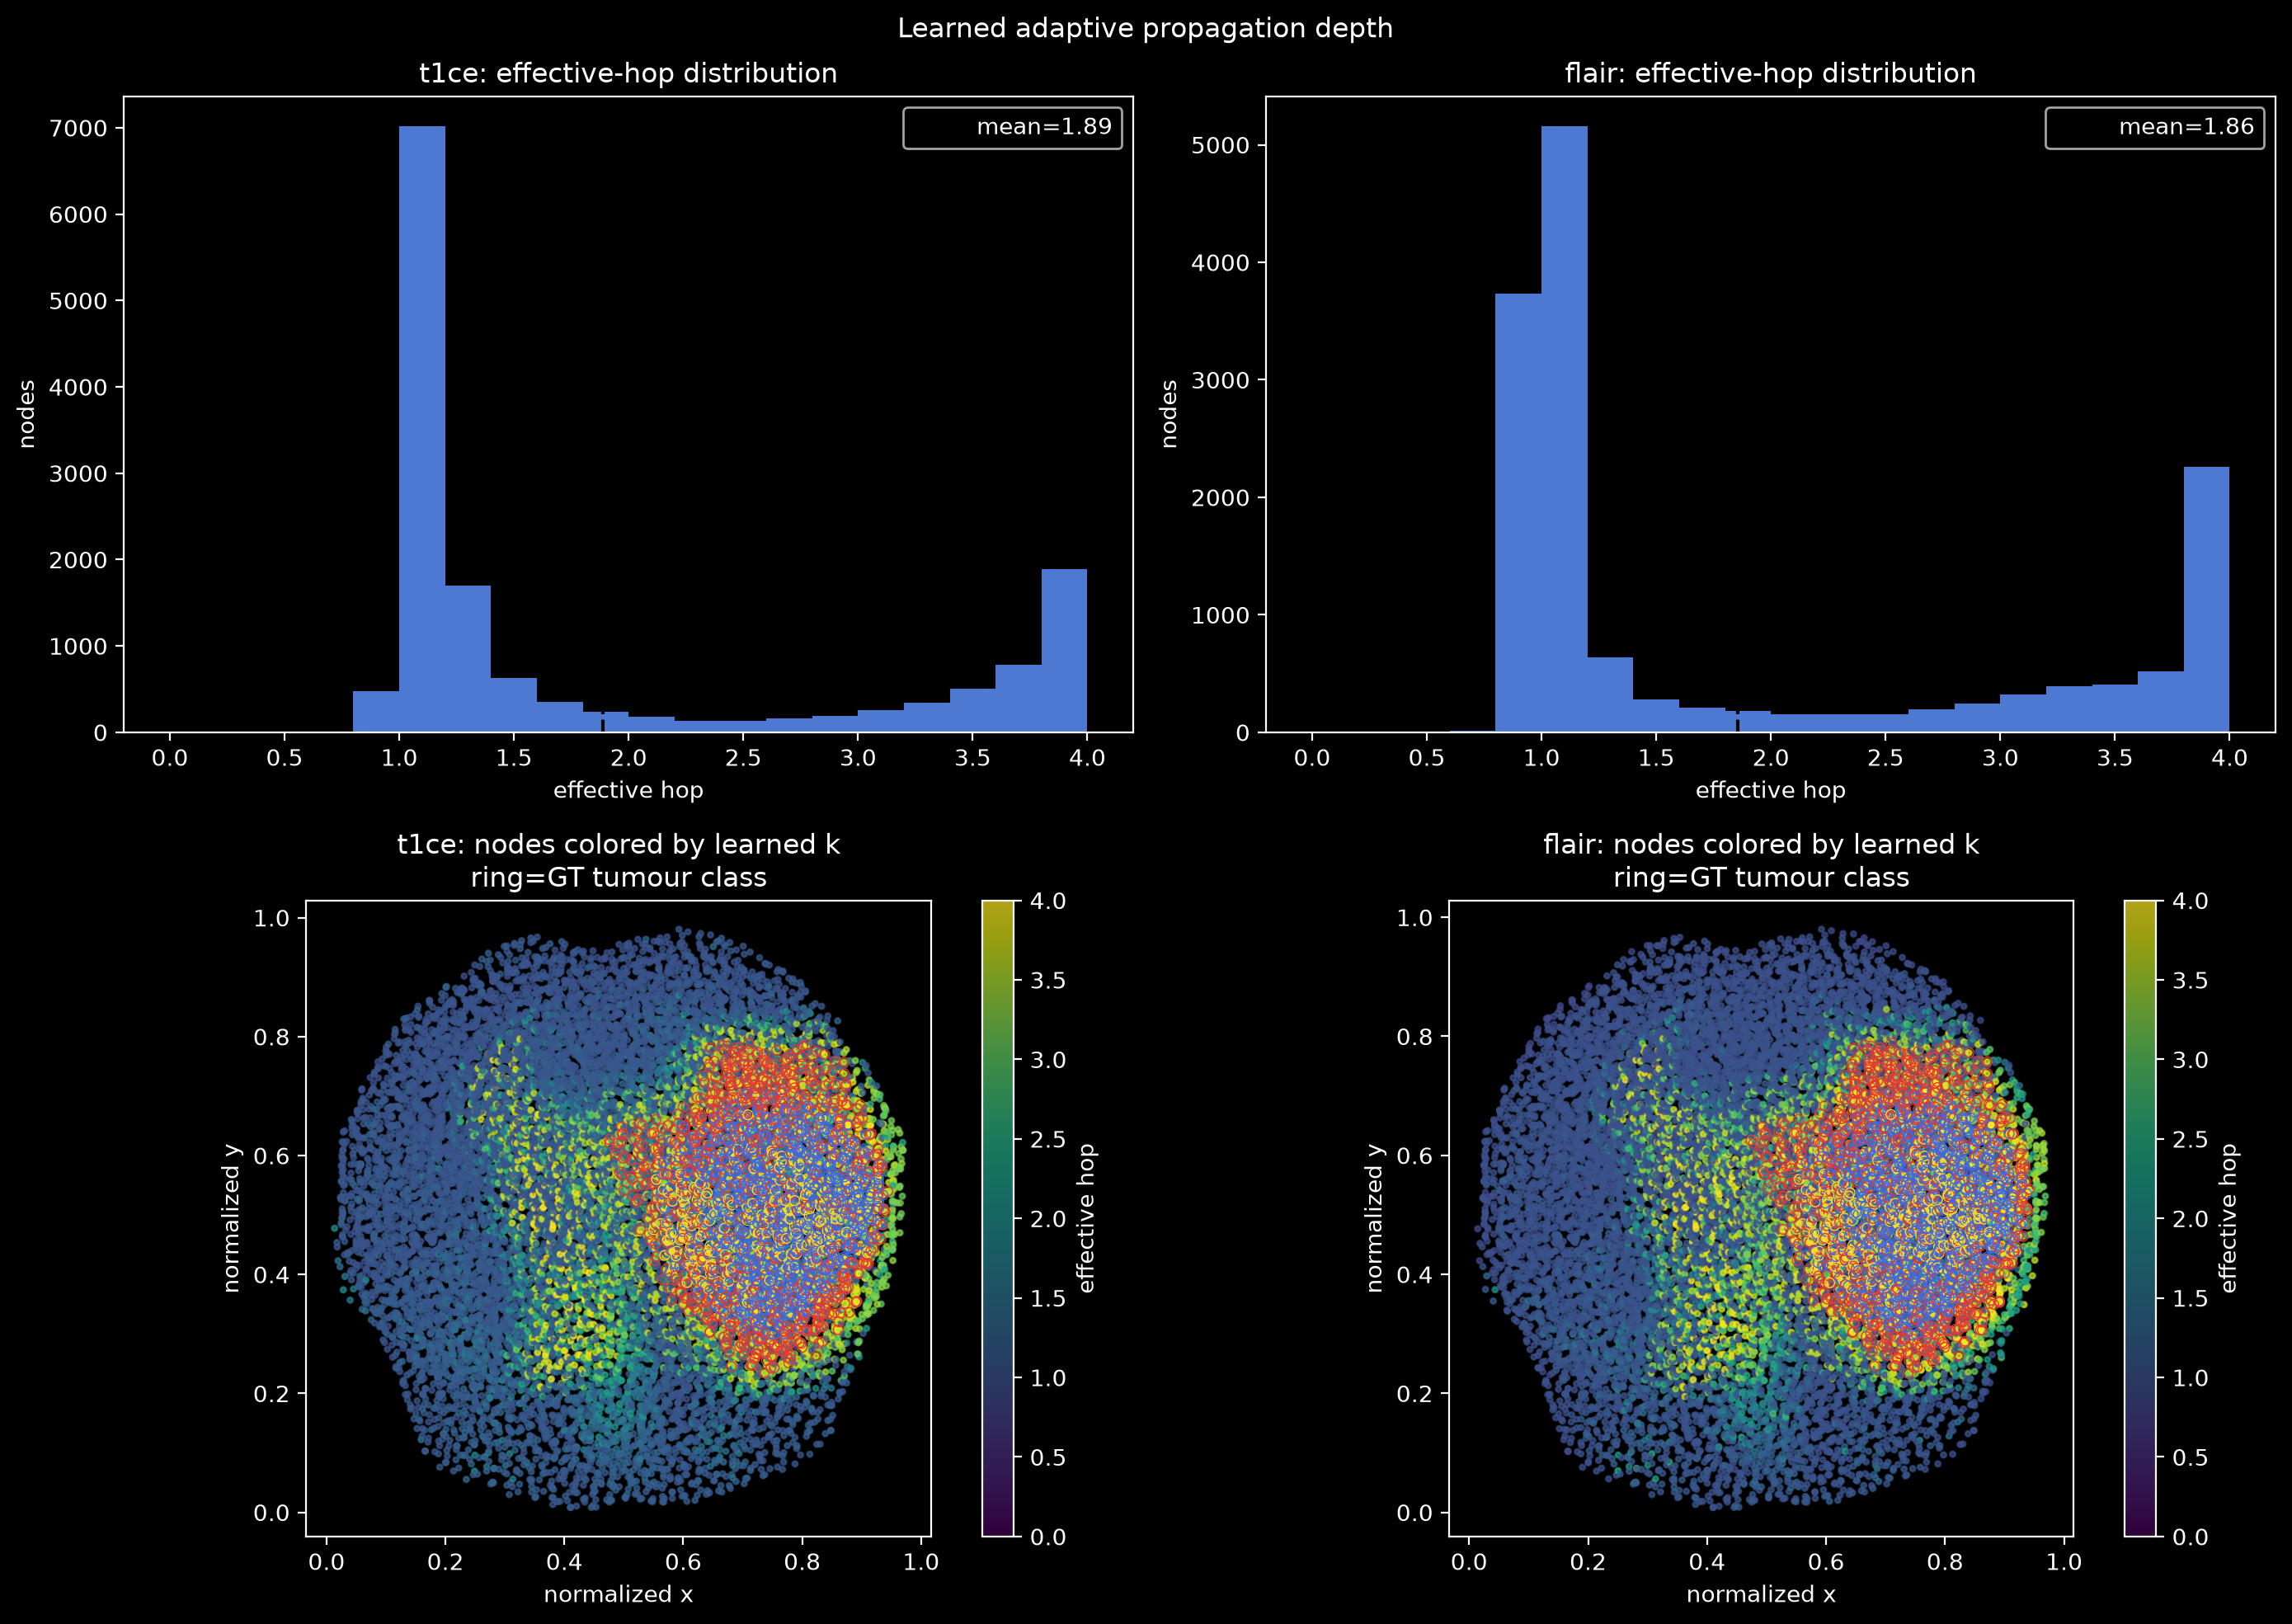

In [ ]:
@torch.no_grad()
def adaptive_hop_diagnostics(item, title="Learned adaptive propagation depth"):
    if not USE_ADAPTIVE_HOPS:
        print("Adaptive hops disabled; set USE_ADAPTIVE_HOPS=True to generate these diagnostics.")
        return None
    data, mpath = item
    meta = load_meta(mpath)
    predict_node_probs(model, data)
    hop_info = base_model.last_hop_info
    gate_history = base_model.last_edge_gates
    if not hop_info:
        print("No hop diagnostics available; run a model forward pass first.")
        return None

    fig, axes = plt.subplots(2, len(NODE_TYPES), figsize=(7 * len(NODE_TYPES), 10))
    class_colors = np.asarray(["#808080", "#4169e1", "#e53935", "#fdd835"])
    summaries = {}
    for col, nt in enumerate(NODE_TYPES):
        effective = hop_info[nt]["effective_hop"].cpu().numpy()
        selected = hop_info[nt]["selected_hop"].cpu().numpy()
        weights = hop_info[nt]["weights"].cpu().numpy()
        labels = data[nt].y.cpu().numpy()
        centroids = data[nt].x[:, 28:31].cpu().numpy()
        summaries[nt] = {
            "mean_effective_hop": float(effective.mean()),
            "mean_hop_weights": weights.mean(axis=0).tolist(),
            "selected_hop_counts": np.bincount(selected, minlength=K_MAX + 1).tolist(),
        }

        axes[0, col].hist(effective, bins=np.linspace(0, K_MAX, 21), color="#5b8ff9", alpha=0.85)
        axes[0, col].axvline(effective.mean(), color="black", linestyle="--",
                             label=f"mean={effective.mean():.2f}")
        axes[0, col].set(title=f"{nt}: effective-hop distribution", xlabel="effective hop", ylabel="nodes")
        axes[0, col].legend()

        scatter = axes[1, col].scatter(centroids[:, 0], centroids[:, 1], c=effective,
                                       cmap="viridis", vmin=0, vmax=K_MAX, s=5, alpha=0.7)
        tumour = labels > 0
        axes[1, col].scatter(centroids[tumour, 0], centroids[tumour, 1],
                             facecolors="none", edgecolors=class_colors[labels[tumour]], s=18, linewidths=0.5)
        axes[1, col].set(title=f"{nt}: nodes colored by learned k\nring=GT tumour class",
                         xlabel="normalized x", ylabel="normalized y", aspect="equal")
        fig.colorbar(scatter, ax=axes[1, col], label="effective hop")

        print(f"{nt}: mean effective hop={effective.mean():.3f}")
        print("  mean beta:", "  ".join(f"k={k}:{v:.3f}" for k, v in enumerate(weights.mean(axis=0))))
        for cls, name in enumerate(CLASS_NAMES):
            mask = labels == cls
            if mask.any():
                print(f"  {name}: n={mask.sum()}  mean k_eff={effective[mask].mean():.3f}")

    if gate_history:
        print("\nLearned adaptive edge-gate alpha by propagation step:")
        for step, gates in enumerate(gate_history, start=1):
            print(f"  hop {step}: " + "  ".join(
                f"{et[0]}-{et[1]}-{et[2]}={float(alpha.mean()):.3f}"
                for et, alpha in gates.items() if alpha.numel()))
    fig.suptitle(title)
    fig.tight_layout()
    plt.show()
    return summaries

hop_diagnostics = adaptive_hop_diagnostics(test_items[0]) if test_items else None

## 13b. Option B diagnostics: initial vs refined, structural statistics

In [ ]:
# ============================================================
# Option B diagnostics: does structural refinement actually help?
# ------------------------------------------------------------
# Reports initial (pre-refinement) vs final (post-refinement) Dice, plus
# structural diagnostics. In baseline mode (USE_STRUCTURAL_REFINEMENT=False)
# initial == final by construction, so this section mainly confirms that and
# skips the structure-specific diagnostics.
import time as _optb_time

def _class_neighbor_transition_matrix(items, n_cases=8):
    """[NUM_CLASSES, NUM_CLASSES] matrix: rows = a node's predicted class,
    cols = the class distribution among its spatial neighbours. Row-normalised.
    Computed on the FINAL prediction, on up to n_cases test graphs (a
    diagnostic, not a training-time metric -- kept small on purpose)."""
    trans = np.zeros((NUM_CLASSES, NUM_CLASSES), dtype=np.float64)
    for _d, _mpath in items[:n_cases]:
        _dev_d = _d.to(device)
        with torch.no_grad():
            if USE_STRUCTURAL_REFINEMENT:
                _, _final_logits, _ = model(_dev_d, teacher_prob=0.0)
            else:
                _final_logits, _ = model(_dev_d)
        for nt in NODE_TYPES:
            pc = _final_logits[nt].argmax(dim=-1).cpu().numpy()
            ei = _d[nt, "spatial", nt].edge_index.cpu().numpy()
            if ei.size == 0:
                continue
            src, dst = ei
            for c in range(NUM_CLASSES):
                mask = pc[src] == c
                if not mask.any():
                    continue
                nb = pc[dst[mask]]
                trans[c] += np.bincount(nb, minlength=NUM_CLASSES)
    row_sums = trans.sum(axis=1, keepdims=True)
    return trans / np.maximum(row_sums, 1.0)

def _tumour_component_diagnostics(items, n_cases=8):
    """Average/median predicted-tumour connected-component size and the
    number of isolated (size==1) tumour components, on the FINAL prediction."""
    sizes_all = []
    for _d, _mpath in items[:n_cases]:
        _dev_d = _d.to(device)
        with torch.no_grad():
            if USE_STRUCTURAL_REFINEMENT:
                _, _final_logits, _ = model(_dev_d, teacher_prob=0.0)
            else:
                _final_logits, _ = model(_dev_d)
        for nt in NODE_TYPES:
            pc = _final_logits[nt].argmax(dim=-1).cpu().numpy()
            tumour_mask = pc != 0
            idx = np.nonzero(tumour_mask)[0]
            if idx.size == 0:
                continue
            csr = edge_index_to_csr(_d[nt, "spatial", nt].edge_index, pc.shape[0])
            sub = csr[idx][:, idx]
            _, labels = connected_components(sub, directed=False)
            sizes_all.extend(np.bincount(labels).tolist())
    sizes_all = np.asarray(sizes_all, dtype=np.float64)
    if sizes_all.size == 0:
        return dict(mean=0.0, median=0.0, isolated=0, n_components=0)
    return dict(
        mean=float(sizes_all.mean()), median=float(np.median(sizes_all)),
        isolated=int((sizes_all == 1).sum()), n_components=int(sizes_all.size),
    )

print("=" * 60)
print("Option B diagnostics")
print("=" * 60)
print(f"USE_STRUCTURAL_REFINEMENT = {USE_STRUCTURAL_REFINEMENT}")
if USE_STRUCTURAL_REFINEMENT:
    print(f"Enabled descriptors: {[k for k, v in STRUCTURAL_FLAGS.items() if v]}")

_optb_t0 = _optb_time.time()
_init_rows, _fin_rows = [], []
for _d, _mpath in test_items:
    _meta = load_meta(_mpath)
    _pred_init, _pred_fin = reconstruct_case_both(model, _d, _meta, postprocess=True)
    _init_rows.append(segmentation_metrics(_pred_init, _meta["seg"]))
    _fin_rows.append(segmentation_metrics(_pred_fin, _meta["seg"]))
init_mean = {k: float(np.mean([r[k] for r in _init_rows])) for k in _init_rows[0]}
fin_mean = {k: float(np.mean([r[k] for r in _fin_rows])) for k in _fin_rows[0]}

print(f"\nInitial (pre-refinement) : {fmt_metrics(init_mean)}")
print(f"Refined (post-refinement): {fmt_metrics(fin_mean)}")
print("Improvement (Refined - Initial):", {k: f"{fin_mean[k] - init_mean[k]:+.4f}" for k in init_mean})

if USE_STRUCTURAL_REFINEMENT:
    _comp_diag = _tumour_component_diagnostics(test_items)
    print(f"\nTumour connected components (final prediction, first {min(8, len(test_items))} test cases):")
    print(f"  count={_comp_diag['n_components']}  mean_size={_comp_diag['mean']:.1f}  "
          f"median_size={_comp_diag['median']:.1f}  isolated(size=1)={_comp_diag['isolated']}")

    _trans = _class_neighbor_transition_matrix(test_items)
    print("\nClass-neighbour transition matrix (row = node class, col = neighbour-class fraction):")
    print("        " + "".join(f"{c:>10s}" for c in CLASS_NAMES))
    for _i, _c in enumerate(CLASS_NAMES):
        print(f"{_c:>8s}" + "".join(f"{_trans[_i, _j]:10.3f}" for _j in range(NUM_CLASSES)))
else:
    print("\n(Structure-specific diagnostics skipped -- baseline mode.)")

print(f"\nDiagnostics computed in {(_optb_time.time() - _optb_t0) / 60:.1f} min.")

Option B diagnostics
USE_STRUCTURAL_REFINEMENT = False

Initial (pre-refinement) : WT=0.8575 | TC=0.7430 | ET=0.6558
Refined (post-refinement): WT=0.8575 | TC=0.7430 | ET=0.6558
Improvement (Refined - Initial): {'Dice_WT': '+0.0000', 'Dice_TC': '+0.0000', 'Dice_ET': '+0.0000'}

(Structure-specific diagnostics skipped -- baseline mode.)

Diagnostics computed in 0.9 min.


## 14. Visualise one segmentation result

The slice with the largest ground-truth tumour area is shown.

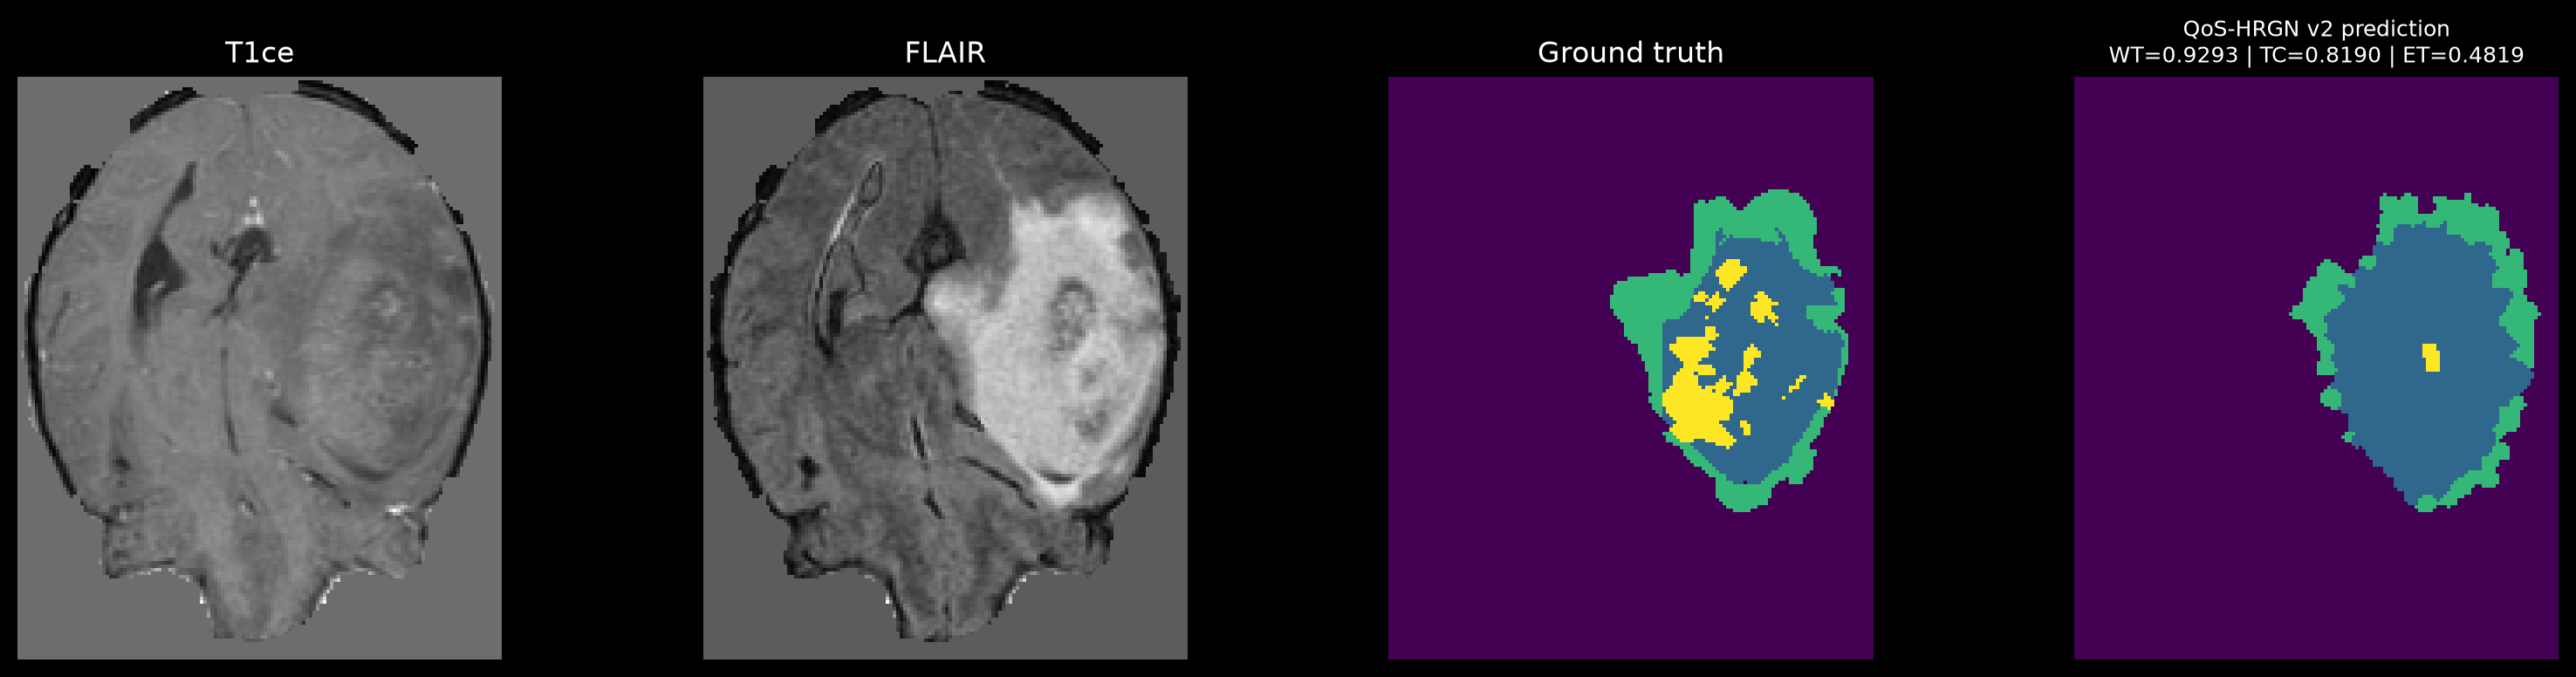

In [ ]:
def show_prediction(item, title="QoS-HRGN v2 prediction"):
    d, mpath = item
    meta = load_meta(mpath)
    pred = reconstruct_case(model, d, meta)
    lo, hi = meta["lo"], meta["hi"]
    seg_c = crop(meta["seg"], lo, hi)
    pred_c = crop(pred, lo, hi)
    z = int(np.argmax((seg_c > 0).sum(axis=(0, 1))))
    fig, ax = plt.subplots(1, 4, figsize=(16, 4))
    ax[0].imshow(meta["vis"]["t1ce"][:, :, z].astype(np.float32).T, cmap="gray", origin="lower"); ax[0].set_title("T1ce")
    ax[1].imshow(meta["vis"]["flair"][:, :, z].astype(np.float32).T, cmap="gray", origin="lower"); ax[1].set_title("FLAIR")
    ax[2].imshow(seg_c[:, :, z].T, cmap="viridis", origin="lower", vmin=0, vmax=3); ax[2].set_title("Ground truth")
    ax[3].imshow(pred_c[:, :, z].T, cmap="viridis", origin="lower", vmin=0, vmax=3)
    ax[3].set_title(f"{title}\n{fmt_metrics(segmentation_metrics(pred, meta['seg']))}", fontsize=9)
    for a in ax:
        a.axis("off")
    plt.tight_layout()
    plt.show()

show_prediction(test_items[0])

## 14d. Paper-style visualisation (Saueressig et al., 2021)

Reproduces the two key figures from the reference paper this pipeline builds on
("Exploring graph-based neural networks for automatic brain tumor segmentation",
Saueressig, Berkley, Kang, Munbodh & Singh -- *MICCAI Brainlesion Workshop*, 2020):

- **Fig. 1 (model overview)**: MRI -> SLIC supervoxels -> node-link graph -> GNN
  node classification -> map back to image space. The full graph (~15,000 nodes
  per modality) isn't visually interpretable, so -- exactly as the paper's own
  toy diagram does with `X0`..`X9` -- this draws a small local neighbourhood as
  an actual node-link graph, not the full supervoxel field.
- **Fig. 2 (tri-planar comparison)**: axial / coronal / sagittal slices, ground
  truth vs. predicted, using the paper's own colour convention (blue =
  NCR/necrosis, red = edema, yellow = enhancing tumour) for direct visual
  comparability with the paper's reported qualitative results.

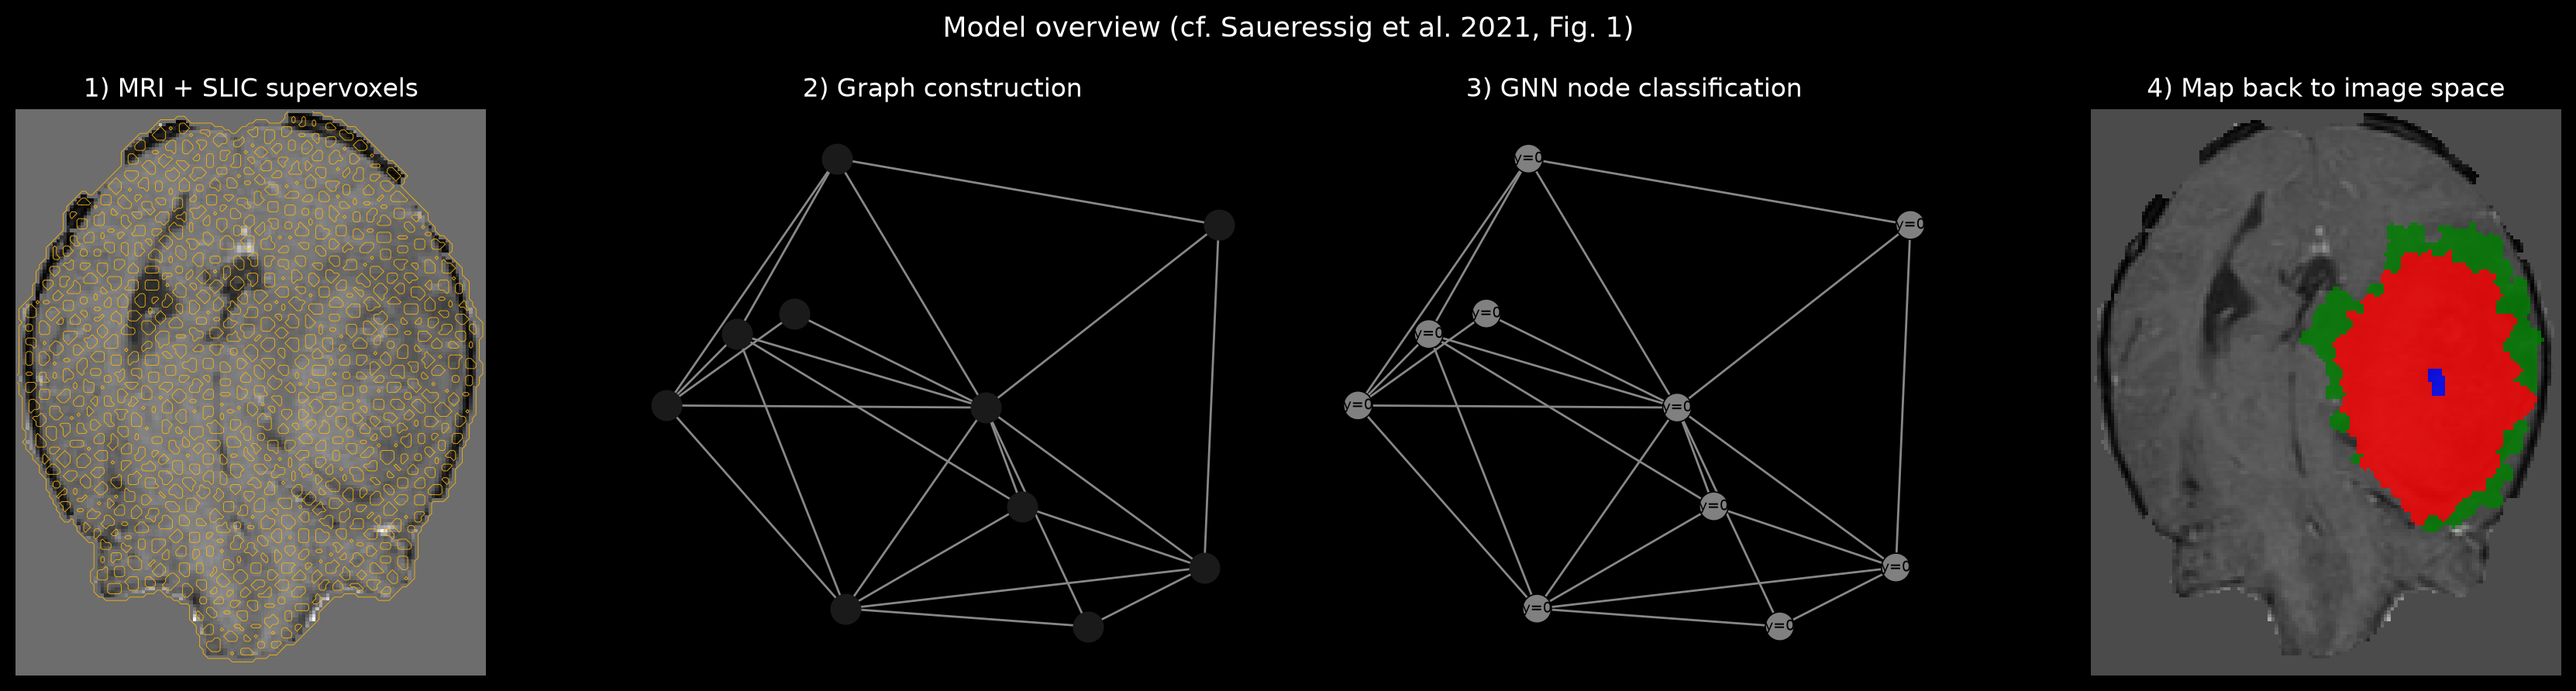

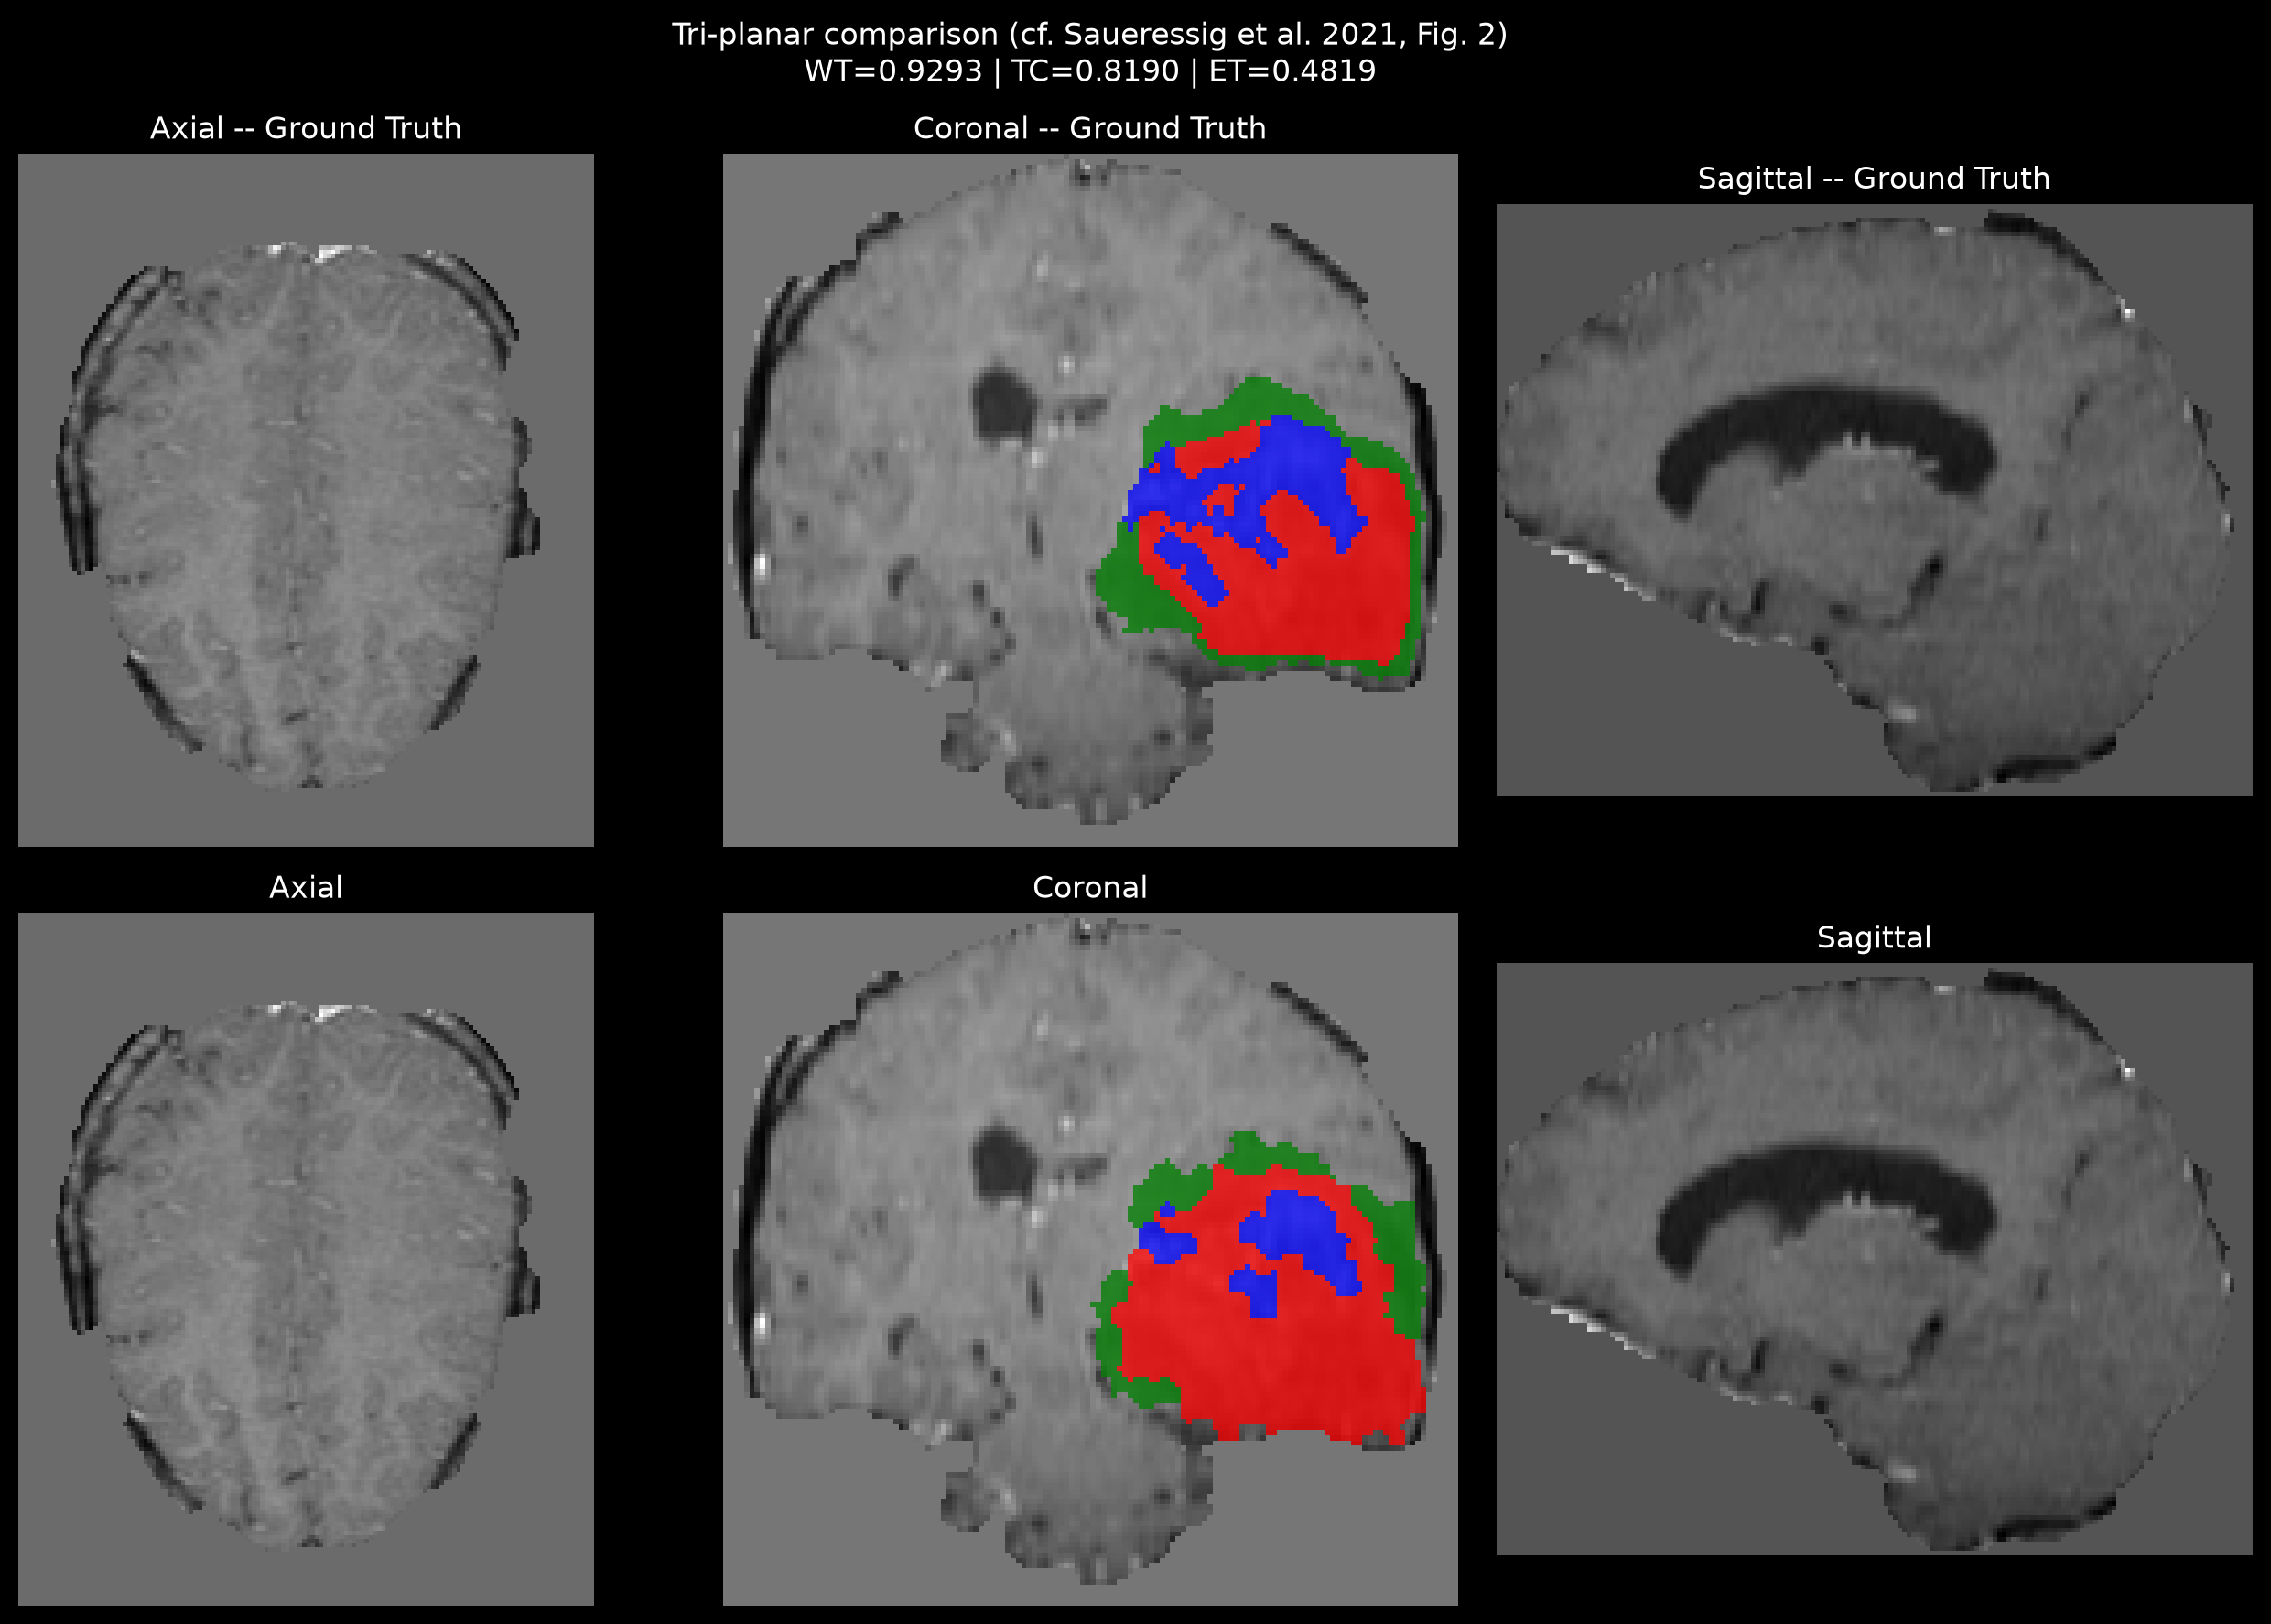

In [ ]:
from matplotlib.colors import ListedColormap
from skimage.segmentation import find_boundaries
import networkx as nx

# BG, NCR/NET, ED, ET -- matches Saueressig et al. Fig. 2's colour convention
# (blue = NCR/necrosis, red = edema, yellow = enhancing tumour).
_PAPER_CMAP = ListedColormap(["#808080", "red", "green", "blue"])


def plot_pipeline_overview(item, node_type="t1ce", n_local_nodes=10, seed=SEED):
    """Reproduces Fig. 1 of Saueressig et al. (2021): MRI -> supervoxels -> graph
    -> GNN classification -> map back to image. The full graph is not visually
    interpretable at ~15,000 nodes, so (as in the paper's own toy diagram) a
    small local neighbourhood is drawn as an actual node-link graph."""
    d, mpath = item
    meta = load_meta(mpath)
    pred = reconstruct_case(model, d, meta)
    lo, hi = meta["lo"], meta["hi"]
    seg_c = crop(meta["seg"], lo, hi)
    pred_c = crop(pred, lo, hi)
    node_map = meta["node_map"][node_type]
    z = int(np.argmax((seg_c > 0).sum(axis=(0, 1))))

    fig, axes = plt.subplots(1, 4, figsize=(18, 4.5))

    # (1) MRI slice with SLIC supervoxel boundaries
    axes[0].imshow(meta["vis"][node_type][:, :, z].astype(np.float32).T, cmap="gray", origin="lower")
    boundaries = find_boundaries(node_map[:, :, z], mode="thick")
    axes[0].contour(boundaries.T, colors="#ffb703", linewidths=0.3)
    axes[0].set_title("1) MRI + SLIC supervoxels")
    axes[0].axis("off")

    # (2)/(3) local node-link graph: raw construction vs. GNN classification
    rng = np.random.default_rng(seed)
    slice_ids = np.unique(node_map[:, :, z])
    slice_ids = slice_ids[slice_ids >= 0]
    center_id = int(rng.choice(slice_ids))
    ei = d[node_type, "spatial", node_type].edge_index.cpu().numpy()
    neighbours = {center_id}
    frontier = {center_id}
    while len(neighbours) < n_local_nodes and frontier:
        nxt = set(ei[1][np.isin(ei[0], list(frontier))].tolist())
        nxt -= neighbours
        neighbours |= nxt
        frontier = nxt
    neighbours = list(neighbours)[:n_local_nodes]

    centroids = d[node_type].x[:, 28:31].cpu().numpy()
    probs = predict_node_probs(model, d)[node_type]
    labels_pred = probs.argmax(axis=-1)

    G = nx.Graph()
    G.add_nodes_from(neighbours)
    mask = np.isin(ei[0], neighbours) & np.isin(ei[1], neighbours)
    G.add_edges_from(zip(ei[0][mask].tolist(), ei[1][mask].tolist()))
    pos = {n: (centroids[n, 0], centroids[n, 1]) for n in neighbours}

    for ax, colored, title in [(axes[1], False, "2) Graph construction"),
                                (axes[2], True, "3) GNN node classification")]:
        nx.draw_networkx_edges(G, pos, ax=ax, edge_color="#888888", width=1.0)
        if not colored:
            nx.draw_networkx_nodes(G, pos, ax=ax, node_color="#1a1a1a", node_size=180)
        else:
            colors = [_PAPER_CMAP(labels_pred[n]) for n in G.nodes()]
            nx.draw_networkx_nodes(G, pos, ax=ax, node_color=colors, node_size=180,
                                    edgecolors="black", linewidths=0.6)
            nx.draw_networkx_labels(G, pos, ax=ax,
                                     labels={n: f"y={labels_pred[n]}" for n in G.nodes()},
                                     font_size=7, font_color="black")
        ax.set_title(title)
        ax.axis("off")

    # (4) map back to image space
    axes[3].imshow(meta["vis"][node_type][:, :, z].astype(np.float32).T, cmap="gray", origin="lower", alpha=0.7)
    axes[3].imshow(np.ma.masked_where(pred_c[:, :, z] == 0, pred_c[:, :, z]).T,
                   cmap=_PAPER_CMAP, origin="lower", vmin=0, vmax=3, alpha=0.8)
    axes[3].set_title("4) Map back to image space")
    axes[3].axis("off")

    fig.suptitle("Model overview (cf. Saueressig et al. 2021, Fig. 1)", fontsize=13)
    plt.tight_layout()
    plt.show()


def plot_triplanar_comparison(item, title=None):
    """Reproduces Fig. 2 of Saueressig et al. (2021): axial / coronal / sagittal
    slices, ground truth (top row) vs. predicted (bottom row), overlaid on T1ce,
    using the paper's colour convention: blue=NCR/necrosis, red=edema, yellow=ET."""
    d, mpath = item
    meta = load_meta(mpath)
    pred = reconstruct_case(model, d, meta)
    lo, hi = meta["lo"], meta["hi"]
    seg_c = crop(meta["seg"], lo, hi)
    pred_c = crop(pred, lo, hi)
    t1ce_c = meta["vis"]["t1ce"].astype(np.float32)

    tumour = np.argwhere(seg_c > 0)
    cz, cy, cx = tumour.mean(axis=0).astype(int) if len(tumour) else np.array(seg_c.shape) // 2

    planes = [
        ("Axial", seg_c[:, :, cz], pred_c[:, :, cz], t1ce_c[:, :, cz]),
        ("Coronal", seg_c[:, cy, :], pred_c[:, cy, :], t1ce_c[:, cy, :]),
        ("Sagittal", seg_c[cx, :, :], pred_c[cx, :, :], t1ce_c[cx, :, :]),
    ]
    fig, axes = plt.subplots(2, 3, figsize=(13, 9))
    for col, (name, gt_slice, pred_slice, mri_slice) in enumerate(planes):
        for row, (arr, label) in enumerate([(gt_slice, "Ground Truth"), (pred_slice, "Predicted")]):
            ax = axes[row, col]
            ax.imshow(mri_slice.T, cmap="gray", origin="lower")
            ax.imshow(np.ma.masked_where(arr == 0, arr).T, cmap=_PAPER_CMAP, origin="lower",
                      vmin=0, vmax=3, alpha=0.75)
            ax.set_title(f"{name} -- {label}" if row == 0 else name)
            ax.axis("off")

    m = segmentation_metrics(pred, meta["seg"])
    fig.suptitle(title or f"Tri-planar comparison (cf. Saueressig et al. 2021, Fig. 2)\n{fmt_metrics(m)}",
                fontsize=12)
    plt.tight_layout()
    plt.show()


if test_items:
    plot_pipeline_overview(test_items[0])
    plot_triplanar_comparison(test_items[0])

## 14b. Option B: visualise initial vs refined prediction

In [ ]:
# ============================================================
# Option B: optional visualisation (not required for training)
# ============================================================
def show_structural_refinement(item, title="Option B: ground truth vs initial vs refined"):
    if not USE_STRUCTURAL_REFINEMENT:
        print("Structural refinement is disabled (USE_STRUCTURAL_REFINEMENT=False); nothing to visualise.")
        return
    d, mpath = item
    meta = load_meta(mpath)
    pred_init, pred_fin = reconstruct_case_both(model, d, meta, postprocess=True)
    seg = meta["seg"]
    z = int(np.argmax((seg > 0).sum(axis=(0, 1))))
    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    for ax, img, name in zip(
        axes, [seg[:, :, z], pred_init[:, :, z], pred_fin[:, :, z]],
        ["Ground truth", "Initial (pre-refinement)", "Refined (post-refinement)"],
    ):
        ax.imshow(img.T, cmap="viridis", vmin=0, vmax=NUM_CLASSES - 1, origin="lower")
        ax.set_title(name)
        ax.axis("off")
    fig.suptitle(title)
    plt.tight_layout()
    plt.show()

if USE_STRUCTURAL_REFINEMENT and test_items:
    show_structural_refinement(test_items[0])
else:
    print("Skipping visualisation (baseline mode, or no test cases available).")

Skipping visualisation (baseline mode, or no test cases available).


## 14c. Option C: can the model actually recover masked graph information?

Three checks, each against a baseline that must be beaten for the claim to mean anything:

| Check | Model | Baseline it must beat |
|---|---|---|
| Masked appearance MAE | decoder on the embedding | (a) global mean of unmasked nodes, (b) mean of unmasked **spatial neighbours** |
| Correspondence AUC | relation scorer | centroid-distance-only scorer (pure geometry) |
| Visual | original -> masked -> reconstructed on one slice | - |

The *neighbour-mean* baseline is the important one: beating the global mean only shows the model
learned the dataset's average intensity, whereas beating the neighbour mean shows it learned
something from the graph beyond naive local smoothing. The *distance-only* AUC baseline is what
makes the correspondence number defensible -- if the model cannot beat geometry, the relation task
is not measuring relational learning.

In [ ]:
# ============================================================
# Option C: recovery evaluation + visualisation
# ============================================================
def _auc(scores, labels):
    """Rank-based ROC-AUC (no sklearn dependency)."""
    scores = np.asarray(scores, dtype=np.float64)
    labels = np.asarray(labels, dtype=np.int64)
    n_pos, n_neg = int((labels == 1).sum()), int((labels == 0).sum())
    if n_pos == 0 or n_neg == 0:
        return float("nan")
    order = np.argsort(scores, kind="mergesort")
    ranks = np.empty(len(scores), dtype=np.float64)
    ranks[order] = np.arange(1, len(scores) + 1, dtype=np.float64)
    return float((ranks[labels == 1].sum() - n_pos * (n_pos + 1) / 2.0) / (n_pos * n_neg))


@torch.no_grad()
def rec_recover_case(data, seed=0):
    """Mask one graph, run the encoder, decode. Returns everything the diagnostics need."""
    model.eval(); rec_module.eval()
    gen = torch.Generator(device=device); gen.manual_seed(seed)
    d = data.to(device)
    corrupt, info = mask_hetero_graph(d, rec_module, gen=gen)
    _, _, h_dict = forward_model(model, corrupt, teacher_prob=0.0)
    out = {"info": info, "pred": {}, "target": {}, "idx": {}}
    for nt in NODE_TYPES:
        idx = info["masked_idx"].get(nt)
        if idx is None or idx.numel() == 0:
            continue
        out["idx"][nt] = idx.cpu().numpy()
        out["pred"][nt] = rec_module.decode_features(h_dict[nt][idx], nt).float().cpu().numpy()
        out["target"][nt] = info["feat_target"][nt].float().cpu().numpy()
    # correspondence scoring (model vs geometry-only baseline)
    pos = info["pos"].get("corresponds")
    if pos is not None and pos.numel() > 0:
        neg = sample_hard_negatives(
            pos, d[("flair", "spatial", "flair")].edge_index, info["n_nodes"]["flair"],
            d[CORR_ET_FT].edge_index, REC_NEG_PER_POS, device, gen, exclude_self=False)
        if neg.numel() > 0:
            s_pos = rec_module.score_pairs(h_dict["t1ce"][pos[0].long()], h_dict["flair"][pos[1].long()], "corresponds")
            s_neg = rec_module.score_pairs(h_dict["t1ce"][neg[0].long()], h_dict["flair"][neg[1].long()], "corresponds")
            # geometry-only baseline: negative centroid distance from feature dims 28..30
            c_t1 = d["t1ce"].x[:, APPEARANCE_DIM:APPEARANCE_DIM + 3].float()
            c_fl = d["flair"].x[:, APPEARANCE_DIM:APPEARANCE_DIM + 3].float()
            g_pos = -(c_t1[pos[0].long()] - c_fl[pos[1].long()]).norm(dim=1)
            g_neg = -(c_t1[neg[0].long()] - c_fl[neg[1].long()]).norm(dim=1)
            out["link"] = dict(
                s_pos=s_pos.float().cpu().numpy(), s_neg=s_neg.float().cpu().numpy(),
                g_pos=g_pos.cpu().numpy(), g_neg=g_neg.cpu().numpy(),
            )
    return out


@torch.no_grad()
def rec_evaluate(items, n_cases=8, seed=0):
    """Masked-feature MAE vs trivial baselines, and correspondence AUC vs geometry."""
    if not USE_MASKED_RECONSTRUCTION or rec_module is None:
        print("Option C disabled (USE_MASKED_RECONSTRUCTION=False); nothing to evaluate.")
        return None
    mae_model, mae_global, mae_nbr = [], [], []
    per_mod = {m: [] for m in MODALITIES}
    s_pos_all, s_neg_all, g_pos_all, g_neg_all = [], [], [], []

    for _i, (_d, _mpath) in enumerate(items[:n_cases]):
        _r = rec_recover_case(_d, seed=seed + _i)
        _dev_d = _d.to(device)
        for nt in NODE_TYPES:
            if nt not in _r["pred"]:
                continue
            idx = _r["idx"][nt]
            pred, tgt = _r["pred"][nt], _r["target"][nt]
            mae_model.append(np.abs(pred - tgt).mean())
            for m in MODALITIES:
                sl = MODALITY_SLICES[m]
                per_mod[m].append(np.abs(pred[:, sl] - tgt[:, sl]).mean())

            app = _dev_d[nt].x[:, :APPEARANCE_DIM].float().cpu().numpy()
            unmasked = np.ones(app.shape[0], dtype=bool)
            unmasked[idx] = False
            # baseline (a): global mean of unmasked nodes
            gmean = app[unmasked].mean(axis=0) if unmasked.any() else np.zeros(APPEARANCE_DIM, np.float32)
            mae_global.append(np.abs(gmean[None, :] - tgt).mean())
            # baseline (b): mean over UNMASKED spatial neighbours (falls back to global mean)
            ei = _dev_d[(nt, "spatial", nt)].edge_index.cpu().numpy()
            nbr_pred = np.repeat(gmean[None, :], len(idx), axis=0)
            if ei.size:
                src, dst = ei
                keep = unmasked[src]
                src_k, dst_k = src[keep], dst[keep]
                acc = np.zeros_like(app); cnt = np.zeros(app.shape[0], np.float32)
                np.add.at(acc, dst_k, app[src_k])
                np.add.at(cnt, dst_k, 1.0)
                has = cnt[idx] > 0
                nbr_pred[has] = acc[idx][has] / cnt[idx][has, None]
            mae_nbr.append(np.abs(nbr_pred - tgt).mean())

        if "link" in _r:
            s_pos_all.append(_r["link"]["s_pos"]); s_neg_all.append(_r["link"]["s_neg"])
            g_pos_all.append(_r["link"]["g_pos"]); g_neg_all.append(_r["link"]["g_neg"])

    print("=" * 66)
    print(f"Option C recovery evaluation ({min(n_cases, len(items))} cases)")
    print("=" * 66)
    if mae_model:
        print("Masked node APPEARANCE reconstruction (mean absolute error, lower is better)")
        print(f"  model (embedding decoder)      : {np.mean(mae_model):.4f}")
        print(f"  baseline (a) global mean       : {np.mean(mae_global):.4f}")
        print(f"  baseline (b) neighbour mean    : {np.mean(mae_nbr):.4f}")
        _best_base = min(np.mean(mae_global), np.mean(mae_nbr))
        print(f"  -> model beats best baseline by: {(_best_base - np.mean(mae_model)) / max(_best_base, 1e-8) * 100:+.1f} %")
        print("  per-modality MAE: " + "  ".join(f"{m}={np.mean(v):.4f}" for m, v in per_mod.items() if v))
    if s_pos_all:
        s = np.concatenate(s_pos_all + s_neg_all)
        g = np.concatenate(g_pos_all + g_neg_all)
        lab = np.concatenate([np.ones(sum(len(a) for a in s_pos_all)),
                              np.zeros(sum(len(a) for a in s_neg_all))])
        print("\nT1ce <-> FLAIR CORRESPONDENCE reconstruction (distance-matched hard negatives)")
        print(f"  model scorer AUC               : {_auc(s, lab):.4f}")
        print(f"  geometry-only (centroid dist)  : {_auc(g, lab):.4f}   <- must be beaten")
        print(f"  model accuracy @ logit>0       : {float(((s > 0).astype(int) == lab).mean()):.4f}")
        print(f"  positives={int(lab.sum())}  hard negatives={int((lab == 0).sum())}")
    return dict(mae_model=float(np.mean(mae_model)) if mae_model else None,
                mae_global=float(np.mean(mae_global)) if mae_global else None,
                mae_nbr=float(np.mean(mae_nbr)) if mae_nbr else None)


def project_node_scalar(values, meta, nt, fill=np.nan):
    """Paint one scalar per node onto its supervoxel (reuses the cached node_map)."""
    nm = meta["node_map"][nt]
    out = np.full(nm.shape, fill, dtype=np.float32)
    valid = nm >= 0
    out[valid] = np.asarray(values, dtype=np.float32)[nm[valid]]
    return out


def rec_visualize_recovery(item, nt="t1ce", modality="t1ce", seed=0):
    """original -> masked -> reconstructed, for one appearance channel on one slice."""
    if not USE_MASKED_RECONSTRUCTION or rec_module is None:
        print("Option C disabled (USE_MASKED_RECONSTRUCTION=False); nothing to visualise.")
        return
    d, mpath = item
    meta = load_meta(mpath)
    r = rec_recover_case(d, seed=seed)
    if nt not in r["pred"]:
        print(f"No masked {nt} nodes in this case.")
        return
    ch = MODALITY_SLICES[modality].start          # that modality's MEAN intensity channel
    idx = r["idx"][nt]
    orig = d[nt].x[:, ch].float().cpu().numpy().copy()
    masked = orig.copy(); masked[idx] = np.nan    # what the encoder was actually given
    recon = orig.copy(); recon[idx] = r["pred"][nt][:, ch]   # same channel as orig/masked

    seg_c = crop(meta["seg"], meta["lo"], meta["hi"])
    z = int(np.argmax((seg_c > 0).sum(axis=(0, 1))))
    panels = [("Original graph", orig), ("Masked graph (input)", masked), ("Reconstructed", recon)]
    vmin = float(np.nanmin(orig)); vmax = float(np.nanmax(orig))

    fig, axes = plt.subplots(1, 4, figsize=(19, 4.4))
    for ax, (name, vals) in zip(axes, panels):
        img = project_node_scalar(vals, meta, nt)[:, :, z]
        ax.imshow(img.T, cmap="magma", origin="lower", vmin=vmin, vmax=vmax)
        ax.set_title(f"{name}\n({nt} nodes, {modality} mean)", fontsize=9)
        ax.axis("off")
    # true vs predicted for the masked nodes
    tgt = r["target"][nt][:, ch]; prd = r["pred"][nt][:, ch]
    axes[3].scatter(tgt, prd, s=3, alpha=0.25, edgecolors="none")
    _lim = [min(tgt.min(), prd.min()), max(tgt.max(), prd.max())]
    axes[3].plot(_lim, _lim, "r--", lw=1)
    _corr = float(np.corrcoef(tgt, prd)[0, 1]) if len(tgt) > 2 else float("nan")
    axes[3].set_title(f"Masked nodes: true vs reconstructed\nn={len(tgt)}  r={_corr:.3f}", fontsize=9)
    axes[3].set_xlabel("true"); axes[3].set_ylabel("reconstructed")
    fig.suptitle(f"Option C: masked graph recovery  |  {nt} partition  |  slice z={z}"
                 f"  |  {len(idx)}/{len(orig)} nodes masked", fontsize=11)
    plt.tight_layout()
    plt.show()

    if "link" in r:
        fig2, ax2 = plt.subplots(figsize=(5.2, 3.4))
        ax2.hist(r["link"]["s_neg"], bins=40, alpha=0.6, label="hard negatives", density=True)
        ax2.hist(r["link"]["s_pos"], bins=40, alpha=0.6, label="held-out positives", density=True)
        ax2.axvline(0.0, color="k", lw=1, ls="--")
        ax2.set_xlabel("correspondence score (logit)"); ax2.set_ylabel("density")
        ax2.set_title("Recovering masked T1ce <-> FLAIR relations", fontsize=10)
        ax2.legend(fontsize=8)
        plt.tight_layout()
        plt.show()


rec_eval_summary = rec_evaluate(test_items, n_cases=8)
if USE_MASKED_RECONSTRUCTION and rec_module is not None and test_items:
    rec_visualize_recovery(test_items[0])

Option C disabled (USE_MASKED_RECONSTRUCTION=False); nothing to evaluate.


## 15. Save the trained model

In [ ]:
checkpoint = {
    "model_state_dict": {k: v.detach().cpu() for k, v in model.state_dict().items()},
    "class_weights": class_weights.detach().cpu(),
    "best_val_dice": best_val_dice,
    "best_epoch": best_epoch,
    "history": history,
    "voxel_head_state_dict": ({k: v.detach().cpu().clone() for k, v in voxel_head.state_dict().items()}
                       if voxel_head is not None else None),
    "use_voxel_refinement": USE_VOXEL_REFINEMENT,
    "rec_state_dict": ({k: v.detach().cpu() for k, v in rec_module.state_dict().items()}
                       if rec_module is not None else None),
    "val_metrics": val_metrics,
    "test_metrics": test_metrics,
    "config": {
        "hidden_dim": HIDDEN_DIM, "heads": HEADS, "hops": HOPS,
        "use_adaptive_hops": USE_ADAPTIVE_HOPS, "k_max": K_MAX,
        "hop_reg_weight": HOP_REG_WEIGHT, "hop_temperature": HOP_TEMPERATURE,
        "hgt_layers": HGT_LAYERS, "dropout": DROPOUT,
        "num_classes": NUM_CLASSES, "node_features": NODE_FEAT_DIM, "n_segments": N_SEGMENTS,
        "compactness": COMPACTNESS, "slic_iters": SLIC_ITERS, "min_overlap": MIN_OVERLAP,
        "batch_size": BATCH_SIZE, "epochs": EPOCHS, "lr": LR, "dice_weight": DICE_WEIGHT,
        "et_min_voxels": ET_MIN_VOXELS, "graph_version": GRAPH_VERSION, "amp": USE_AMP,
        "masked_reconstruction": USE_MASKED_RECONSTRUCTION, "lambda_rec": LAMBDA_REC,
        "rec_mask_rate": REC_MASK_RATE, "rec_edge_mask_rate": REC_EDGE_MASK_RATE,
        "rec_targets": REC_FLAGS, "rec_feat_loss": REC_FEAT_LOSS,
        "rec_separate_clean_pass": REC_SEPARATE_CLEAN_PASS,
    },
}
final_model_path = os.path.join(PERSISTENT_BASE, f"qos_hrgn_v2_slic{N_SEGMENTS}_{'adaptiveK'+str(K_MAX) if USE_ADAPTIVE_HOPS else 'hops'+str(HOPS)}.pt")
torch.save(checkpoint, final_model_path)
print(f"Saved: {final_model_path}")

Saved: /marimo/brats_qos_hrgn_data/qos_hrgn_v2_slic15000_adaptiveK4.pt


## 16. What is implemented, and how to run the ablations

### Backbone (established)
- 3D SLIC supervoxels, two modality-specific partitions of the same brain.
- PyG `HeteroData` with `t1ce` / `flair` node types, spatial and overlap-based cross-modal relations.
- PyG `HGTConv` with residual + LayerNorm.

### Proposed component
- Adaptive propagation weights conditioned on node embeddings, edge attributes (distance, contact/overlap), feature similarity, cross-modal relation and prediction uncertainty; gate-normalised aggregation; `HOPS` stages.
- Pathology-aware prediction on fractional labels with a per-patient volume-weighted Dice term that equals voxel Dice.

### Ablations to report (one config change each, same cache)
| Question | Change |
|---|---|
| Does adaptive propagation help over HGT alone? | `HOPS = 0` |
| Does the heterogeneous cross-modal relation help? | build with `MIN_OVERLAP = 1.01` (no cross edges) |
| Does resolution matter? | oracle sweep (Section 6) and/or `N_SEGMENTS = 4000` |
| Do the soft labels matter? | replace `y_frac` by one-hot `y` in `hierarchy_loss` |

### Remaining known limitations
- Node-constant predictions cannot beat the oracle ceiling; Saueressig et al. gained ~2 % with a shallow voxel CNN refinement on top of the projected logits — a natural next step.
- Per-case z-scoring; dataset-level normalisation may help cross-site consistency.

## 16b. Option B: experiment summary

In [ ]:
# ============================================================
# Option B: experiment summary
# ------------------------------------------------------------
# RESEARCH INTEGRITY: this reflects one run with this seed/config. Do not
# treat a positive delta here as a proven result -- compare against the
# HOPS=0 / no-cross-modal-edge / one-hot-label ablations already documented
# in the "What is implemented" section, and ideally repeat with a different
# seed, before claiming Option B improves performance.
_optb_param_count = sum(p.numel() for p in model.parameters()) / 1e6
_optb_gpu_peak = torch.cuda.max_memory_allocated() / 1024**3 if device.type == "cuda" else 0.0

print("=" * 60)
print("EXPERIMENT SUMMARY")
print("=" * 60)
print(f"Structural refinement enabled : {USE_STRUCTURAL_REFINEMENT}")
if USE_STRUCTURAL_REFINEMENT:
    print(f"Enabled descriptors           : {[k for k, v in STRUCTURAL_FLAGS.items() if v]}")
print(f"Parameters                    : {_optb_param_count:.2f} M")
print(f"GPU peak memory                : {_optb_gpu_peak:.2f} GB")
print(f"Best epoch / val patient-Dice  : {best_epoch} / {best_val_dice:.4f}")
print()
print(f"{'Region':<8}{'Initial':>10}{'Refined':>10}{'Delta':>10}")
for _k, _name in zip(["Dice_WT", "Dice_TC", "Dice_ET"], ["WT", "TC", "ET"]):
    print(f"{_name:<8}{init_mean[_k]:>10.4f}{fin_mean[_k]:>10.4f}{fin_mean[_k] - init_mean[_k]:>+10.4f}")
print()
print("This is a single run -- not yet a validated result. Compare against the")
print("existing ablation table in the final markdown section before drawing conclusions.")

EXPERIMENT SUMMARY
Structural refinement enabled : False
Parameters                    : 0.49 M
GPU peak memory                : 63.86 GB
Best epoch / val patient-Dice  : 88 / 0.7768

Region     Initial   Refined     Delta
WT          0.8575    0.8575   +0.0000
TC          0.7430    0.7430   +0.0000
ET          0.6558    0.6558   +0.0000

This is a single run -- not yet a validated result. Compare against the
existing ablation table in the final markdown section before drawing conclusions.


## 16c. Option C: the ablation to report

| Run | `USE_MASKED_RECONSTRUCTION` | `LAMBDA_REC` | What it isolates |
|---|---|---|---|
| Baseline | `False` | - | QoS-HRGN + segmentation only |
| + masked reconstruction | `True` | `0.3` | the proposed auxiliary objective |
| lambda sweep | `True` | `0.1 / 0.3 / 1.0` | sensitivity; large lambda should start hurting Dice |
| feature target only | `True`, `REC_USE_CORRESPONDENCE=False` | `0.3` | value of node-feature masking alone |
| relation target only | `True`, `REC_USE_FEATURE=False` | `0.3` | value of correspondence masking alone |
| + spatial edges | `True`, `REC_USE_SPATIAL_EDGE=True` | `0.3` | expected to add ~nothing (report as negative result) |

Report WT / TC / ET test Dice for each, plus the recovery numbers from section 14c.

**What can honestly be claimed.** The contribution is an auxiliary *heterogeneous* masked-graph
reconstruction objective: appearance masking that can only be solved through the graph, and a
correspondence-relation task made non-trivial by distance-matched hard negatives. Whether it
improves Dice is an empirical question this ablation answers -- a null result is still a legitimate
finding, and the recovery diagnostics in 14c stand on their own as evidence that the embeddings
encode recoverable heterogeneous structure.

**What must not be claimed.** That reconstruction improves segmentation, before the baseline and the
`LAMBDA_REC` sweep have been run with the same seed and split. Masked autoencoding is a
*regulariser*; on 258 training patients with a strong supervised signal it may well be neutral.

## 16d. Voxel refinement head: the ablation to report

| Run | `USE_VOXEL_REFINEMENT` | `ET_FOCAL_WEIGHT` | `USE_CC_POSTPROCESS` | What it isolates |
|---|---|---|---|---|
| Baseline (v3) | `False` | 0 | `False` | QoS-HRGN + segmentation only (original) |
| + focal loss | `False` | 0.5 | `False` | focal loss helps the graph model close the gap to oracle |
| + CC post-proc | `False` | 0 | `True` | connected-component ET removal |
| + voxel head | `True` | 0.5 | `True` | full pipeline: graph + voxel refinement |

**Why ET 0.8 is achievable now.** The 15k supervoxel oracle ceiling for ET is
0.7243 — a perfect node classifier cannot reach 0.8 because ET and NCR/NET are
mixed within supervoxels. The voxel refinement head breaks this ceiling by
discriminating at voxel resolution using T1ce intensity. Within a mixed
supervoxel, the enhancing tumour region has higher T1ce intensity than necrosis,
and the 3D U-Net can learn this local pattern to split them.

**What to report.**
- Graph-only vs graph+voxel WT/TC/ET test Dice (the `evaluate_items_voxel` output).
- Per-patient ET delta to show which cases benefit most.
- The oracle ceiling alongside both, to show the voxel head exceeds it.
- The focal loss ablation (graph-only with and without focal) to isolate that contribution.

## 16e. Adaptive-hop propagation ablation

The proposed model uses one shared recurrent propagation layer and learns a node-wise soft distribution over $k=0,\ldots,K_{max}$. This isolates propagation distance from layer-specific parameter count.

| Run | `USE_ADAPTIVE_HOPS` | `HOPS` / `K_MAX` | Purpose |
|---|---:|---:|---|
| HGT only | `False` | `HOPS=0` | no adaptive propagation |
| Fixed propagation | `False` | `HOPS=2` | original QoS-HRGN baseline |
| Adaptive depth | `True` | `K_MAX=4` | node-wise learned receptive field |
| No hop cost | `True` | `K_MAX=4`, `HOP_REG_WEIGHT=0` | tests whether the expected-hop penalty matters |
| Full model | `True` | `K_MAX=4`, `HOP_REG_WEIGHT=0.002` | uncertainty-conditioned adaptive depth |

Report WT/TC/ET Dice, parameter count, runtime, mean effective hop, mean $\beta_k$, and effective-hop distributions by node type and tissue class. Adaptive hop selection learns propagation depth over a fixed graph; it should not be described as learning or rewiring graph topology.

## 17. Exact modality Shapley explanations

Saueressig et al. used DeepSHAP to study how T1, T1CE, T2, and FLAIR contribute to each tissue prediction. Here the four modalities are treated as four cooperative-game players, making it practical to calculate **exact grouped Shapley values over all 16 modality coalitions** rather than a neural approximation. Missing modality groups are replaced by a 500-node training-background mean; geometry and graph topology remain unchanged. All nodes in a patient graph are perturbed simultaneously because a GNN node cannot be explained independently of its neighbors.

The resulting plots follow the paper's class × modality × bright/dark organization. Positive values support the full-model predicted class; negative values oppose it. This explains modality evidence, while the learned edge gates and adaptive hops in the next section explain graph-structural evidence.

XAI background label fractions:
  t1ce: BG=0.932  NCR/NET=0.010  ED=0.050  ET=0.008
  flair: BG=0.934  NCR/NET=0.014  ED=0.036  ET=0.016


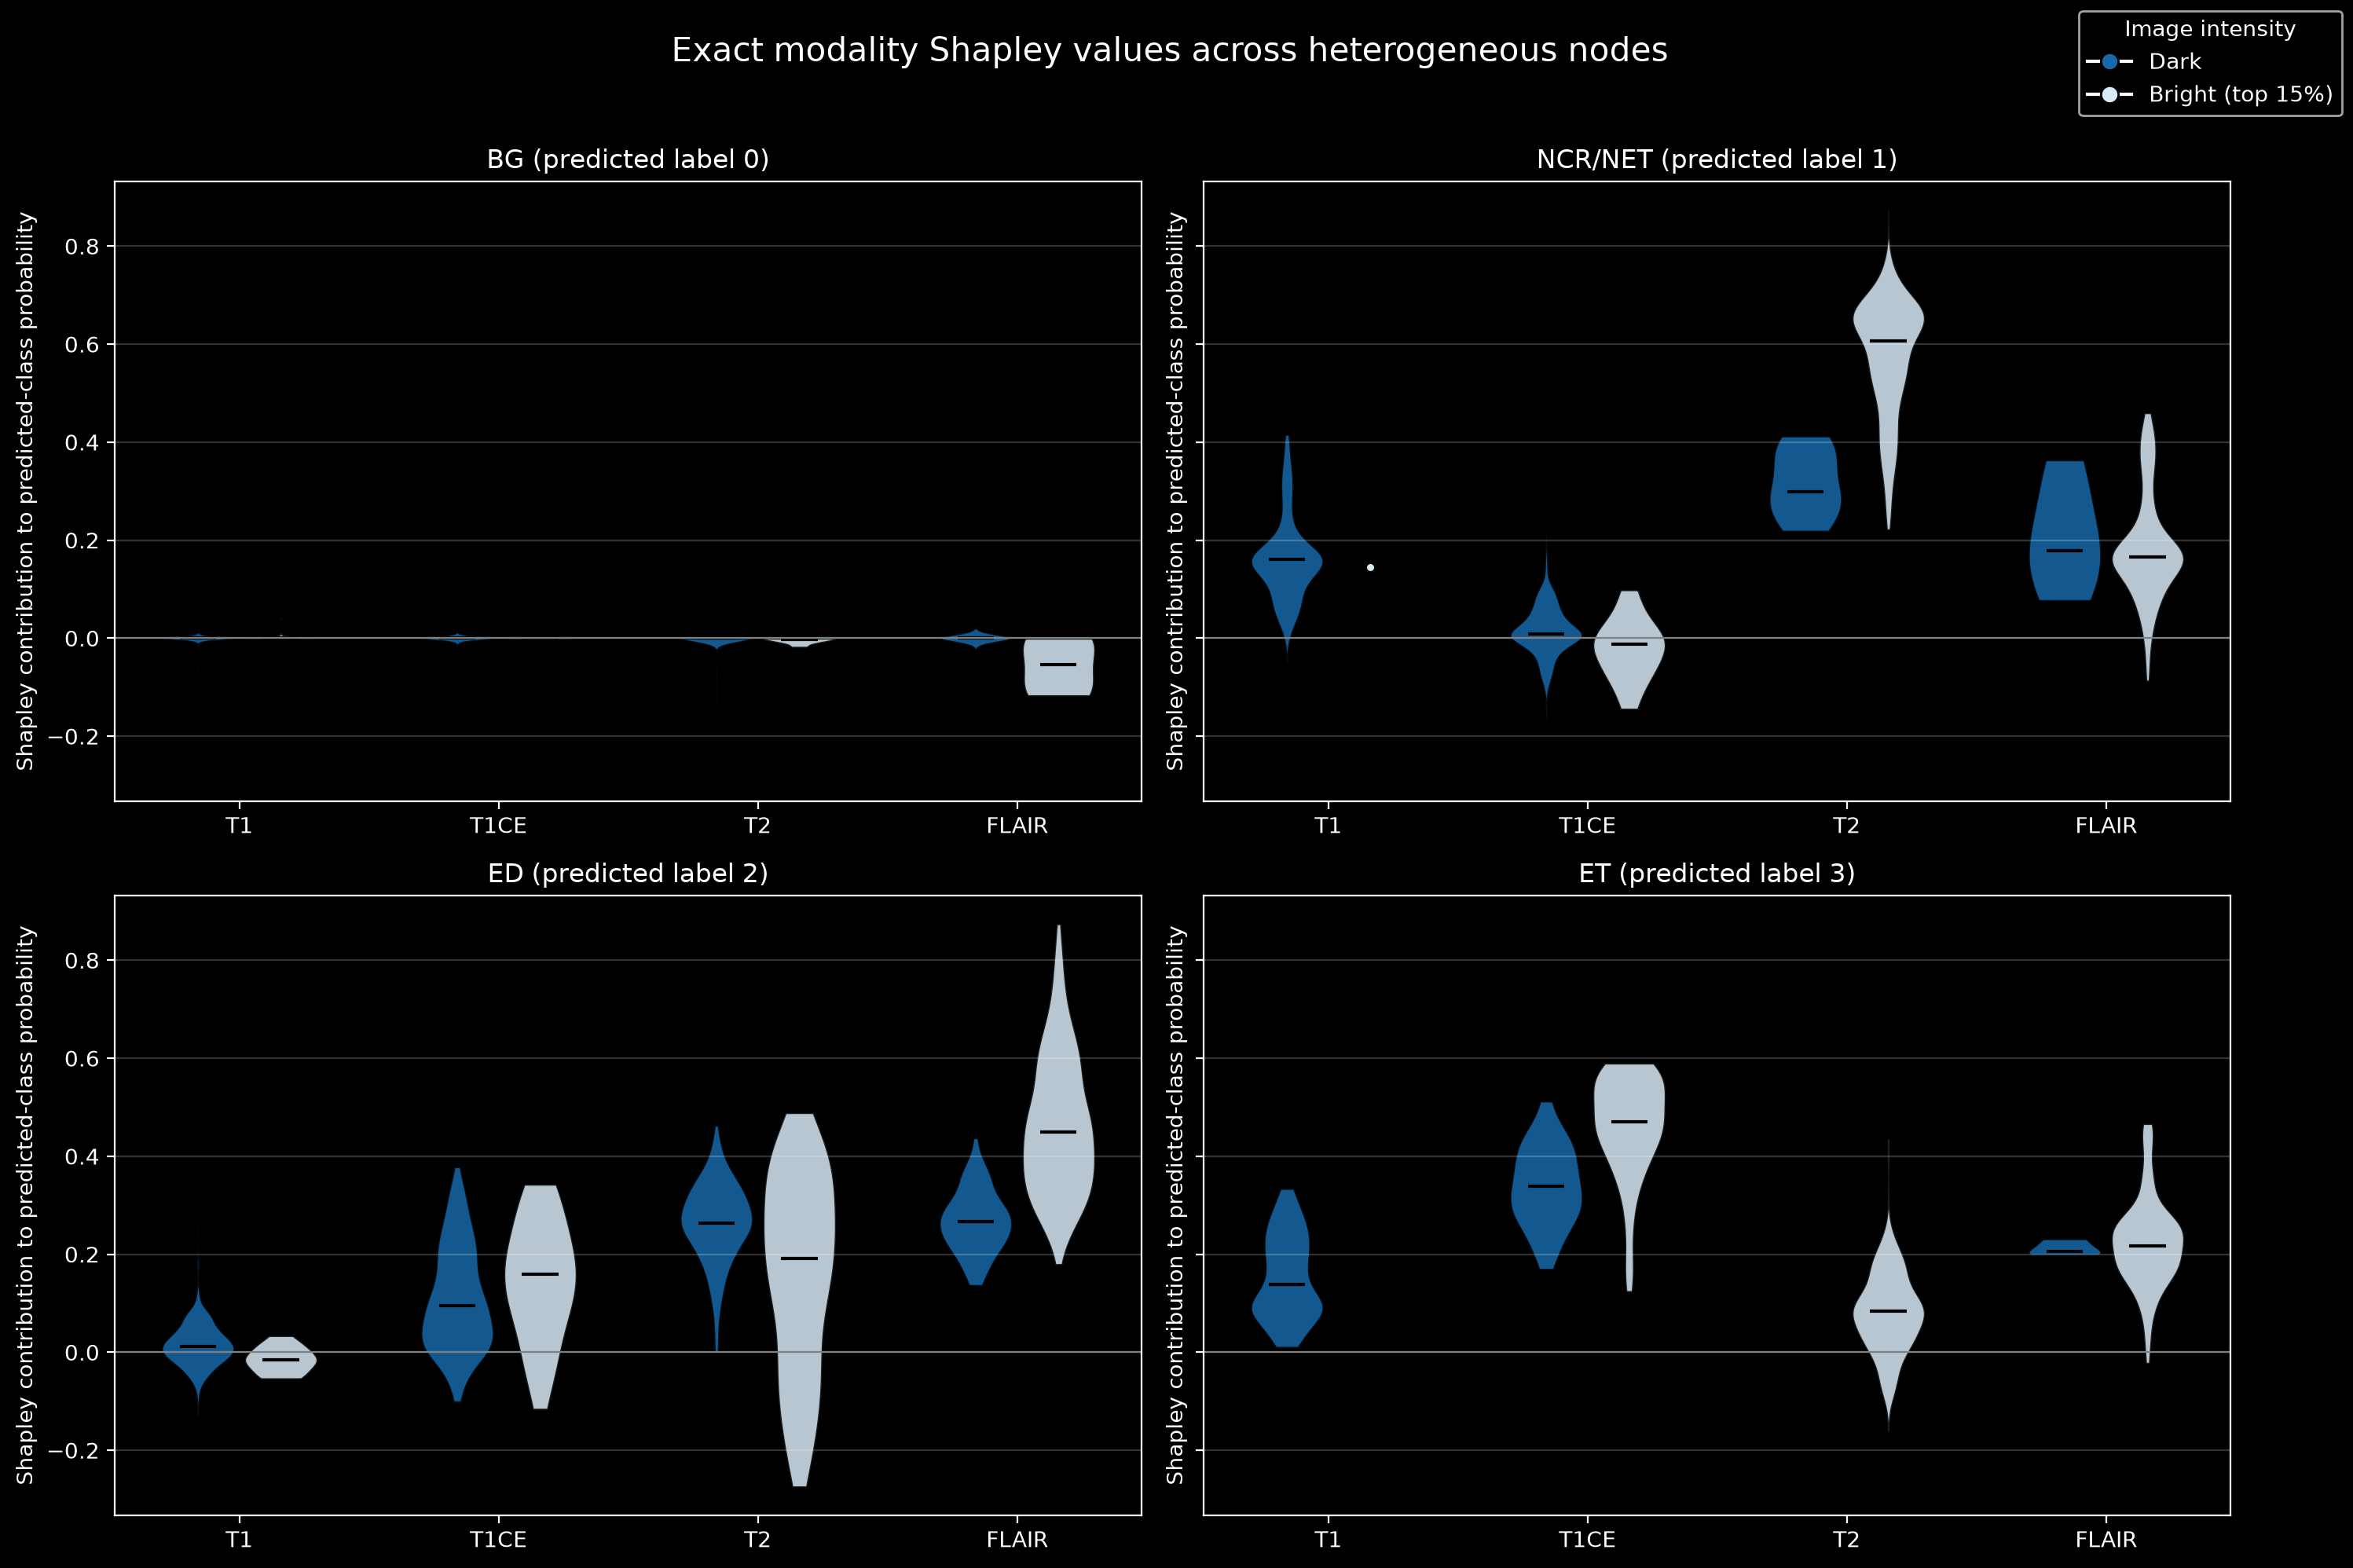

Mean absolute modality contribution:
  t1ce: t1=0.07862  t1ce=0.11029  t2=0.24466  flair=0.21135
       Shapley efficiency max error=1.19e-07
  flair: t1=0.08192  t1ce=0.11015  t2=0.23992  flair=0.21224
       Shapley efficiency max error=1.19e-07


In [ ]:
from itertools import combinations as _xai_combinations

_XAI_GROUP_WIDTH = 2 + len(QUANTILES)
_XAI_MODALITY_SLICES = {
    modality: slice(i * _XAI_GROUP_WIDTH, (i + 1) * _XAI_GROUP_WIDTH)
    for i, modality in enumerate(MODALITIES)
}


def build_xai_background(items, sample_nodes=500, seed=SEED + 701):
    """Randomly sample training nodes while preserving empirical label prevalence."""
    rng = np.random.default_rng(seed)
    background = {}
    for nt in NODE_TYPES:
        sizes = np.asarray([data[nt].x.size(0) for data, _ in items], dtype=np.int64)
        cumulative = np.cumsum(sizes)
        total = int(cumulative[-1])
        chosen = rng.choice(total, size=min(sample_nodes, total), replace=False)
        vectors, labels = [], []
        for global_index in chosen:
            graph_index = int(np.searchsorted(cumulative, global_index, side="right"))
            previous = 0 if graph_index == 0 else int(cumulative[graph_index - 1])
            local_index = int(global_index - previous)
            vectors.append(items[graph_index][0][nt].x[local_index].float())
            labels.append(int(items[graph_index][0][nt].y[local_index]))
        samples = torch.stack(vectors)
        background[nt] = {
            "mean": samples.mean(dim=0),
            "samples": samples,
            "labels": np.asarray(labels),
            "label_fraction": np.bincount(labels, minlength=NUM_CLASSES) / len(labels),
        }
    return background


@torch.no_grad()
def xai_predict_probabilities(graph):
    graph = graph.to(device)
    if USE_STRUCTURAL_REFINEMENT:
        _, logits, _ = model(graph, teacher_prob=0.0)
    else:
        logits, _ = model(graph)
    return {nt: torch.softmax(logits[nt].float(), dim=-1).cpu() for nt in NODE_TYPES}


@torch.no_grad()
def exact_modality_shapley(item, background, max_nodes_per_class=150, seed=SEED + 702):
    """Exact four-player Shapley attribution for each node's full-model predicted class."""
    data, _ = item
    full_prob = xai_predict_probabilities(data.clone())
    full_class = {nt: full_prob[nt].argmax(dim=1) for nt in NODE_TYPES}
    coalition_outputs = {}
    modality_count = len(MODALITIES)

    for mask in range(1 << modality_count):
        perturbed = data.clone()
        for nt in NODE_TYPES:
            x = perturbed[nt].x.clone()
            baseline = background[nt]["mean"].to(x.device, dtype=x.dtype)
            for modality_index, modality in enumerate(MODALITIES):
                if not (mask & (1 << modality_index)):
                    feature_slice = _XAI_MODALITY_SLICES[modality]
                    x[:, feature_slice] = baseline[feature_slice]
            perturbed[nt].x = x
        probabilities = xai_predict_probabilities(perturbed)
        coalition_outputs[mask] = {
            nt: probabilities[nt].gather(1, full_class[nt].unsqueeze(1)).squeeze(1)
            for nt in NODE_TYPES
        }

    factorial = math.factorial
    results = {}
    rng = np.random.default_rng(seed)
    for nt in NODE_TYPES:
        shapley = torch.zeros(data[nt].x.size(0), modality_count)
        for modality_index in range(modality_count):
            others = [j for j in range(modality_count) if j != modality_index]
            for subset_size in range(modality_count):
                coefficient = (factorial(subset_size) * factorial(modality_count - subset_size - 1)
                               / factorial(modality_count))
                for subset in _xai_combinations(others, subset_size):
                    mask = sum(1 << j for j in subset)
                    shapley[:, modality_index] += coefficient * (
                        coalition_outputs[mask | (1 << modality_index)][nt] - coalition_outputs[mask][nt])

        selected = []
        predicted = full_class[nt].numpy()
        for cls in range(NUM_CLASSES):
            candidates = np.flatnonzero(predicted == cls)
            if len(candidates) > max_nodes_per_class:
                candidates = rng.choice(candidates, max_nodes_per_class, replace=False)
            selected.extend(candidates.tolist())
        selected = np.asarray(sorted(selected), dtype=np.int64)
        node_x = data[nt].x.float().cpu().numpy()
        brightness = np.zeros((len(selected), modality_count), dtype=bool)
        thresholds = []
        for modality_index, modality in enumerate(MODALITIES):
            first_feature = _XAI_MODALITY_SLICES[modality].start
            threshold = float(np.quantile(background[nt]["samples"][:, first_feature].cpu().numpy(), 0.85))
            thresholds.append(threshold)
            brightness[:, modality_index] = node_x[selected, first_feature] >= threshold
        results[nt] = {
            "node_index": selected,
            "predicted_class": predicted[selected],
            "true_class": data[nt].y.cpu().numpy()[selected],
            "confidence": full_prob[nt].max(dim=1).values.numpy()[selected],
            "shapley": shapley.numpy()[selected],
            "bright": brightness,
            "brightness_threshold": np.asarray(thresholds),
            "efficiency_error": float((shapley.sum(dim=1) - (
                coalition_outputs[(1 << modality_count) - 1][nt] - coalition_outputs[0][nt]
            )).abs().max()),
        }

    xai_predict_probabilities(data.clone())
    return results


def plot_modality_shapley(results, title="Exact modality Shapley values across heterogeneous nodes"):
    fig, axes = plt.subplots(2, 2, figsize=(15, 10), sharey=True)
    axes = axes.ravel()
    dark_color, bright_color = "#1769aa", "#d9eaf7"
    for cls, axis in enumerate(axes):
        pooled_values = [[[], []] for _ in MODALITIES]
        for result in results.values():
            class_mask = result["predicted_class"] == cls
            for modality_index in range(len(MODALITIES)):
                values = result["shapley"][class_mask, modality_index]
                bright = result["bright"][class_mask, modality_index]
                pooled_values[modality_index][0].extend(values[~bright].tolist())
                pooled_values[modality_index][1].extend(values[bright].tolist())
        for modality_index, (dark_values, bright_values) in enumerate(pooled_values):
            for offset, values, color, name in [
                (-0.16, dark_values, dark_color, "Dark"),
                (0.16, bright_values, bright_color, "Bright"),
            ]:
                if len(values) >= 2:
                    violin = axis.violinplot(values, positions=[modality_index + offset], widths=0.28,
                                             showmeans=False, showmedians=True, showextrema=False)
                    for body in violin["bodies"]:
                        body.set_facecolor(color); body.set_edgecolor("black"); body.set_alpha(0.85)
                    violin["cmedians"].set_color("black")
                elif values:
                    axis.scatter([modality_index + offset], values, color=color, edgecolor="black", s=18)
        axis.axhline(0, color="gray", linewidth=0.8)
        axis.set_xticks(range(len(MODALITIES)), [m.upper() for m in MODALITIES])
        axis.set_title(f"{CLASS_NAMES[cls]} (predicted label {cls})")
        axis.set_ylabel("Shapley contribution to predicted-class probability")
        axis.grid(axis="y", alpha=0.2)
    handles = [plt.Line2D([0], [0], marker="o", color="w", markerfacecolor=dark_color,
                          markeredgecolor="black", label="Dark", markersize=8),
               plt.Line2D([0], [0], marker="o", color="w", markerfacecolor=bright_color,
                          markeredgecolor="black", label="Bright (top 15%)", markersize=8)]
    fig.legend(handles=handles, loc="upper right", title="Image intensity")
    fig.suptitle(title, fontsize=15)
    fig.tight_layout(rect=(0, 0, 0.96, 0.96))
    plt.show()

    print("Mean absolute modality contribution:")
    for nt, result in results.items():
        means = np.abs(result["shapley"]).mean(axis=0)
        print(f"  {nt}: " + "  ".join(f"{m}={v:.5f}" for m, v in zip(MODALITIES, means)))
        print(f"       Shapley efficiency max error={result['efficiency_error']:.2e}")


xai_background = build_xai_background(train_items, sample_nodes=500)
print("XAI background label fractions:")
for _xai_nt in NODE_TYPES:
    print(f"  {_xai_nt}: " + "  ".join(
        f"{name}={fraction:.3f}" for name, fraction in zip(CLASS_NAMES, xai_background[_xai_nt]["label_fraction"])))
modality_shapley = exact_modality_shapley(test_items[0], xai_background) if test_items else None
if modality_shapley is not None:
    plot_modality_shapley(modality_shapley)

## 18. Labelled heterogeneous explanation graph

A full patient graph contains roughly 30,000 nodes and is not visually interpretable. This view therefore selects a clinically relevant target node and displays its bounded heterogeneous neighborhood. Node color is predicted tissue, marker shape is modality-specific node type, node size is confidence, each label contains node ID/class/probability/effective hop, edge color is relation type, and edge opacity/width/numeric labels show the model's learned adaptive gate $\alpha$. Gate weights are averaged over recurrent propagation steps. This is a faithful visualization of signals actually used by adaptive propagation, not a force-directed decorative graph.

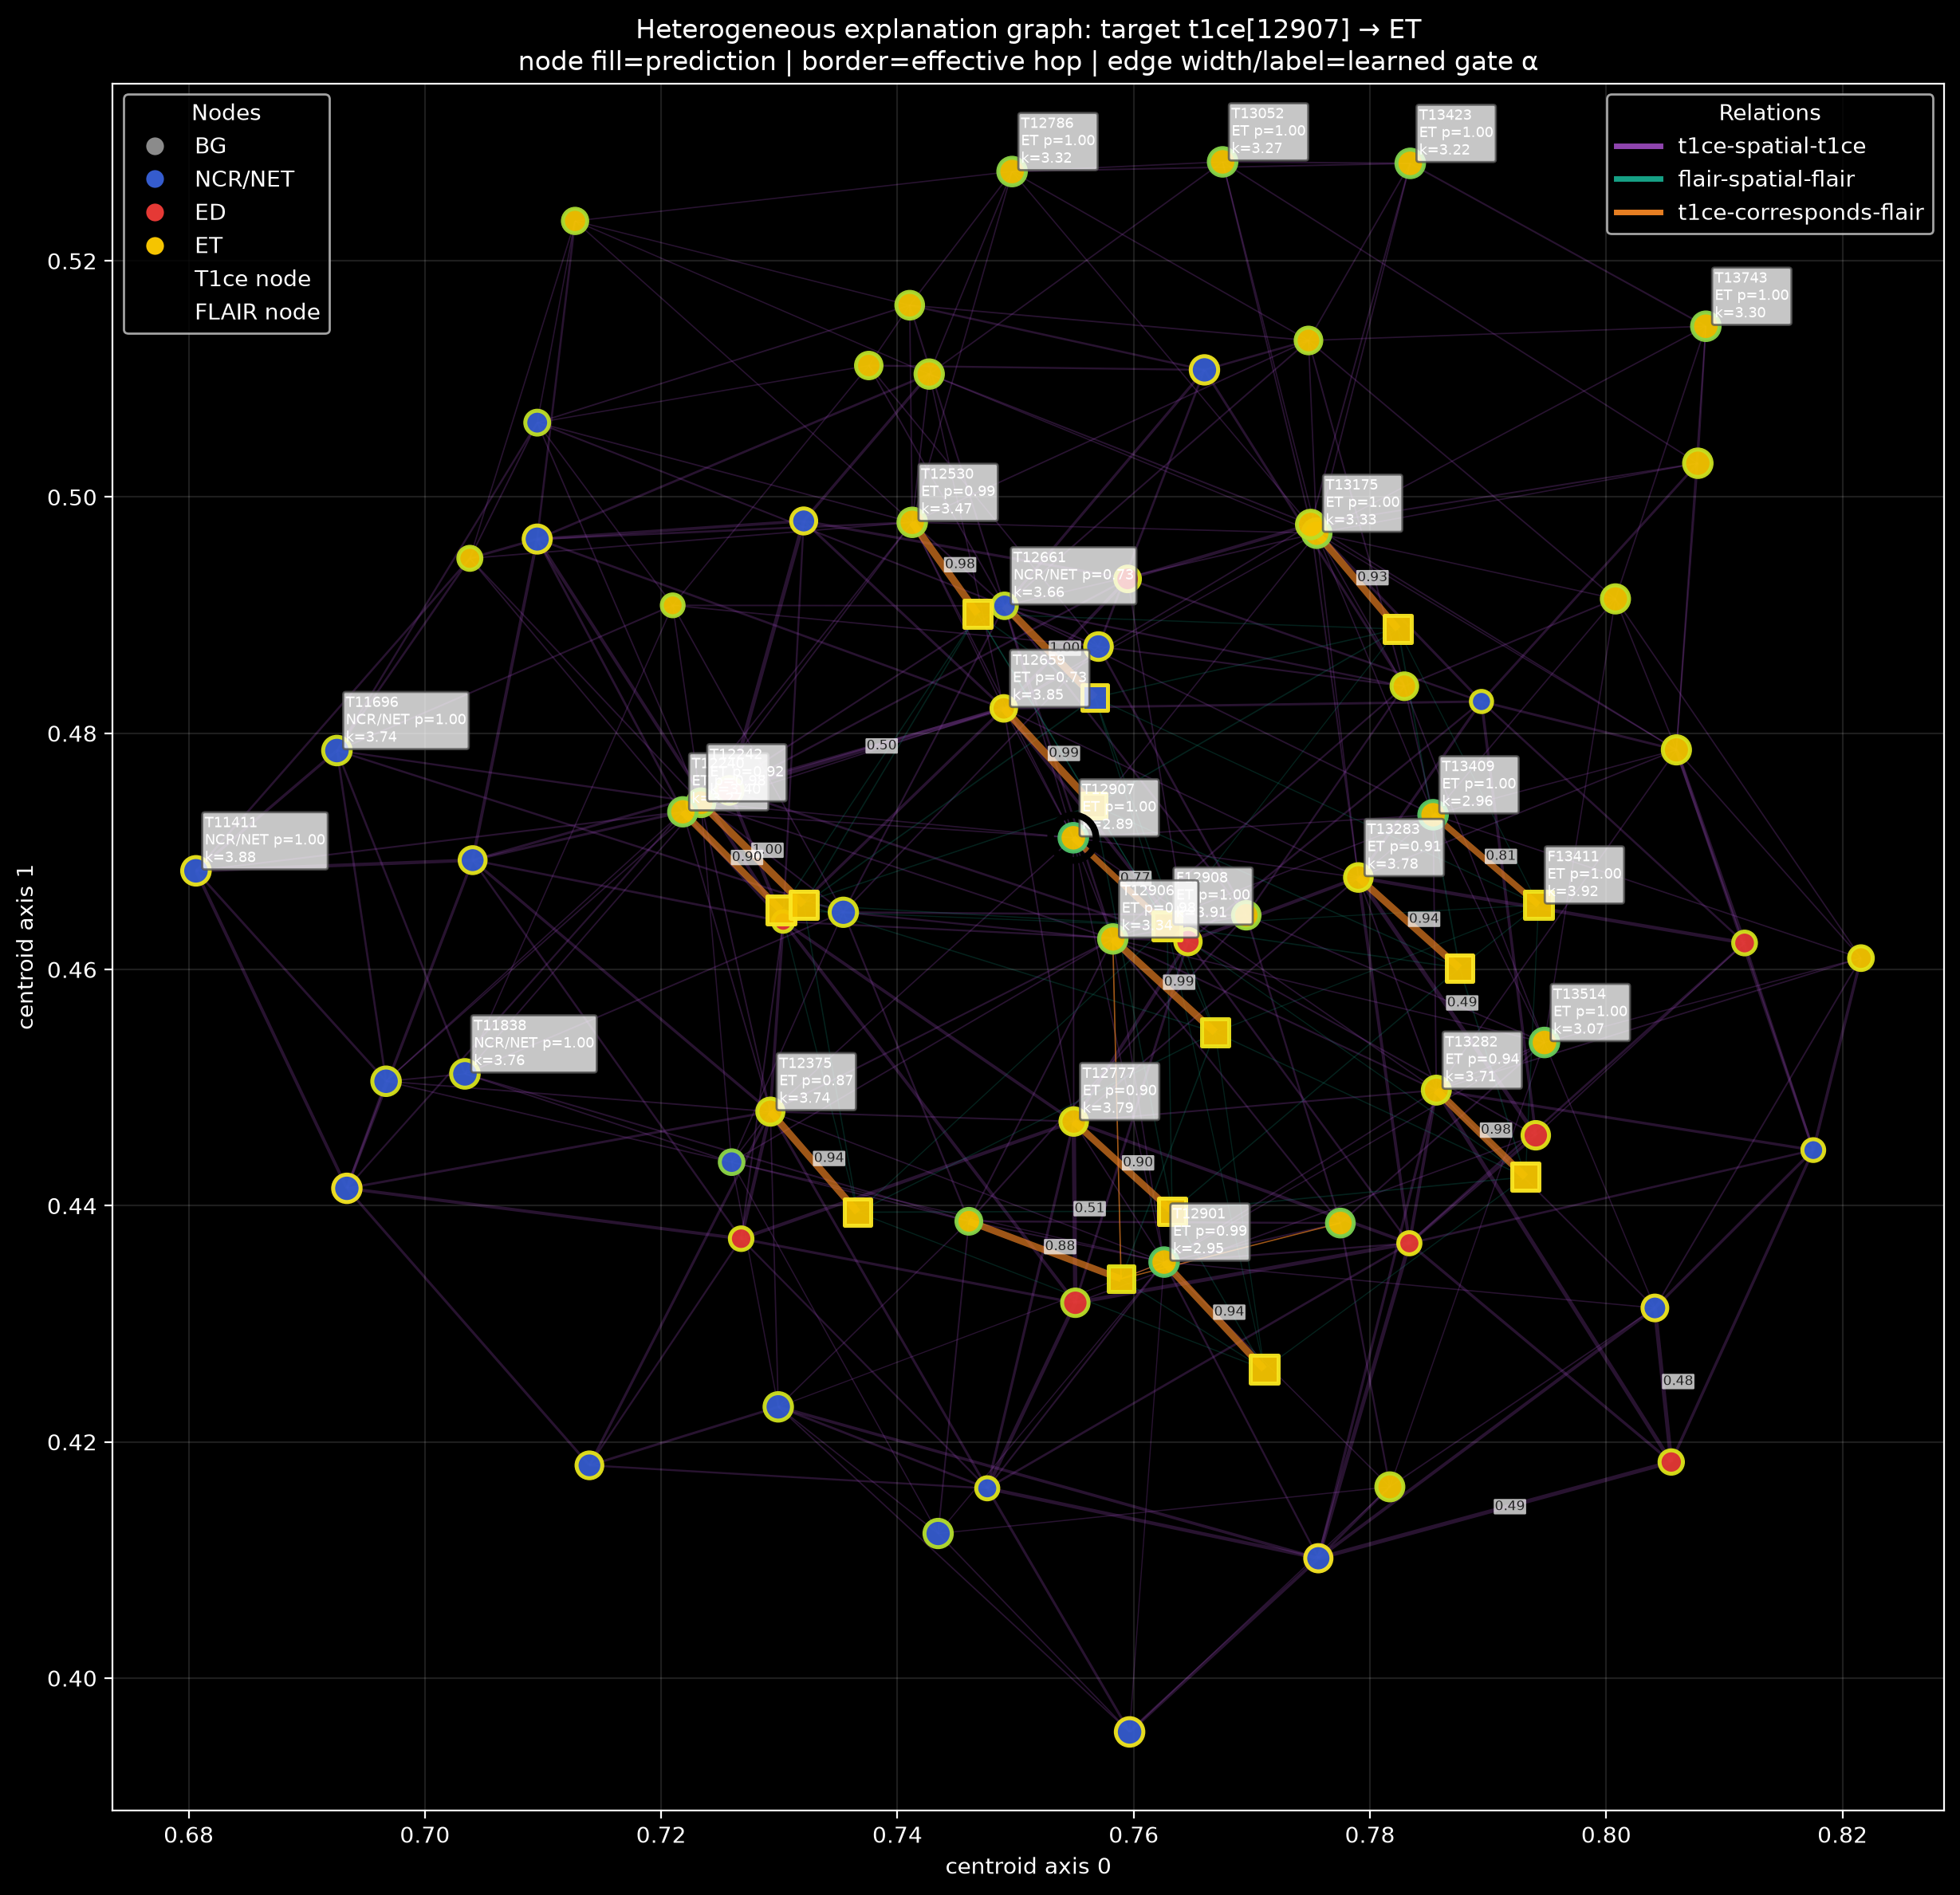

Target: t1ce[12907]  predicted=ET confidence=0.999
Displayed 83 nodes and 375 edges (2-hop neighborhood).
  t1ce-spatial-t1ce: edges=310  mean α=0.155  max α=0.507
  flair-spatial-flair: edges=47  mean α=0.051  max α=0.092
  t1ce-corresponds-flair: edges=18  mean α=0.783  max α=0.999


In [ ]:
from matplotlib.collections import LineCollection as _XAILineCollection
from matplotlib.lines import Line2D as _XAILine2D

_XAI_CLASS_COLORS = np.asarray(["#8b8b8b", "#355cce", "#e53935", "#f5c400"])
_XAI_RELATION_COLORS = {"t1ce-spatial-t1ce": "#8e44ad", "flair-spatial-flair": "#16a085",
                        "t1ce-corresponds-flair": "#e67e22"}
_XAI_DISPLAY_EDGE_TYPES = (
    ("t1ce", "spatial", "t1ce"),
    ("flair", "spatial", "flair"),
    ("t1ce", "corresponds", "flair"),
)


def xai_relation_name(edge_type):
    return "-".join(edge_type)


@torch.no_grad()
def explain_local_hetero_graph(item, target_type="t1ce", target_class=3,
                               neighborhood_hops=2, max_nodes=90, label_nodes=24,
                               display_axes=(0, 1)):
    """Draw a bounded, labelled heterogeneous neighborhood around one target node."""
    data, _ = item
    probabilities = xai_predict_probabilities(data.clone())
    hop_info = base_model.last_hop_info
    gate_history = base_model.last_edge_gates
    predicted = {nt: probabilities[nt].argmax(dim=1).numpy() for nt in NODE_TYPES}
    confidence = {nt: probabilities[nt].max(dim=1).values.numpy() for nt in NODE_TYPES}

    candidates = np.flatnonzero(predicted[target_type] == target_class)
    if len(candidates):
        target_index = int(candidates[np.argmax(confidence[target_type][candidates])])
    else:
        target_index = int(probabilities[target_type][:, target_class].argmax())
        print(f"No predicted class-{target_class} {target_type} node; using highest class probability instead.")
    target = (target_type, target_index)

    edge_arrays = {edge_type: data[edge_type].edge_index.cpu().numpy() for edge_type in _XAI_DISPLAY_EDGE_TYPES}
    distance = {target: 0}
    frontier = {target}
    for depth in range(1, neighborhood_hops + 1):
        discovered = set()
        for edge_type, edge_index in edge_arrays.items():
            src_type, _, dst_type = edge_type
            src, dst = edge_index
            frontier_src = np.asarray([index for nt, index in frontier if nt == src_type], dtype=np.int64)
            frontier_dst = np.asarray([index for nt, index in frontier if nt == dst_type], dtype=np.int64)
            if len(frontier_src):
                for index in dst[np.isin(src, frontier_src)]:
                    discovered.add((dst_type, int(index)))
            if len(frontier_dst):
                for index in src[np.isin(dst, frontier_dst)]:
                    discovered.add((src_type, int(index)))
        discovered -= set(distance)
        for node in discovered:
            distance[node] = depth
        frontier = discovered
        if not frontier:
            break

    nodes = list(distance)
    if len(nodes) > max_nodes:
        nodes = sorted(nodes, key=lambda node: (
            distance[node], -float(confidence[node[0]][node[1]]), node[0], node[1]))[:max_nodes]
    node_set = set(nodes)
    positions = {}
    for nt, index in nodes:
        centroid = data[nt].x[index, 28:31].cpu().numpy()
        offset = np.asarray([0.004, -0.004]) if nt == "flair" else np.asarray([-0.004, 0.004])
        positions[(nt, index)] = centroid[list(display_axes)] + offset

    averaged_gates = {}
    if gate_history:
        for edge_type in _XAI_DISPLAY_EDGE_TYPES:
            available = [step[edge_type].cpu().numpy() for step in gate_history if edge_type in step]
            if available:
                averaged_gates[edge_type] = np.mean(np.stack(available), axis=0)

    visible_edges = []
    for edge_type, edge_index in edge_arrays.items():
        src_type, _, dst_type = edge_type
        weights = averaged_gates.get(edge_type)
        for edge_id, (src, dst) in enumerate(edge_index.T):
            source, destination = (src_type, int(src)), (dst_type, int(dst))
            if source in node_set and destination in node_set and source != destination:
                weight = float(weights[edge_id]) if weights is not None else 0.5
                visible_edges.append((source, destination, edge_type, edge_id, weight))

    # Spatial edge_index commonly stores both directions. Collapse each displayed
    # anatomical connection and average its directional gates for a clean figure.
    deduplicated = {}
    for source, destination, edge_type, edge_id, weight in visible_edges:
        canonical = tuple(sorted((source, destination)))
        key = (edge_type, canonical)
        deduplicated.setdefault(key, []).append((edge_id, weight))
    visible_edges = [
        (canonical[0], canonical[1], edge_type, values[0][0],
         float(np.mean([weight for _, weight in values])))
        for (edge_type, canonical), values in deduplicated.items()
    ]

    fig, axis = plt.subplots(figsize=(15, 12))
    for edge_type in _XAI_DISPLAY_EDGE_TYPES:
        relation_edges = [edge for edge in visible_edges if edge[2] == edge_type]
        if not relation_edges:
            continue
        segments = [[positions[edge[0]], positions[edge[1]]] for edge in relation_edges]
        weights = np.asarray([edge[4] for edge in relation_edges])
        collection = _XAILineCollection(
            segments, colors=_XAI_RELATION_COLORS[xai_relation_name(edge_type)],
            linewidths=0.4 + 3.0 * weights, alpha=float(np.clip(0.18 + 0.65 * weights.mean(), 0.2, 0.85)),
            zorder=1)
        axis.add_collection(collection)

    for nt, marker in [("t1ce", "o"), ("flair", "s")]:
        typed_nodes = [node for node in nodes if node[0] == nt]
        if not typed_nodes:
            continue
        xy = np.stack([positions[node] for node in typed_nodes])
        cls = np.asarray([predicted[nt][node[1]] for node in typed_nodes])
        conf = np.asarray([confidence[nt][node[1]] for node in typed_nodes])
        effective = np.asarray([
            float(hop_info[nt]["effective_hop"][node[1]].cpu()) if hop_info else float(HOPS)
            for node in typed_nodes])
        axis.scatter(xy[:, 0], xy[:, 1], c=_XAI_CLASS_COLORS[cls], marker=marker,
                     s=35 + 120 * conf, edgecolors=plt.cm.viridis(effective / max(K_MAX, 1)),
                     linewidths=1.8, alpha=0.95, zorder=3)

    ranked_nodes = sorted(nodes, key=lambda node: (
        node != target, distance[node], -float(confidence[node[0]][node[1]])))[:label_nodes]
    for nt, index in ranked_nodes:
        cls = int(predicted[nt][index])
        eff = float(hop_info[nt]["effective_hop"][index].cpu()) if hop_info else float(HOPS)
        text = f"{nt[0].upper()}{index}\n{CLASS_NAMES[cls]} p={confidence[nt][index]:.2f}\nk={eff:.2f}"
        axis.annotate(text, positions[(nt, index)], xytext=(4, 4), textcoords="offset points",
                      fontsize=6.5, bbox=dict(boxstyle="round,pad=0.18", fc="white", ec="#555", alpha=0.78),
                      zorder=5)

    for source, destination, edge_type, _, weight in sorted(
            visible_edges, key=lambda edge: edge[4], reverse=True)[:min(20, len(visible_edges))]:
        midpoint = (positions[source] + positions[destination]) / 2
        axis.text(midpoint[0], midpoint[1], f"{weight:.2f}", fontsize=6, color="#222",
                  bbox=dict(boxstyle="round,pad=0.08", fc="white", ec="none", alpha=0.72), zorder=4)

    target_xy = positions[target]
    axis.scatter([target_xy[0]], [target_xy[1]], s=420, facecolors="none", edgecolors="black",
                 linewidths=3, zorder=6)
    class_handles = [_XAILine2D([0], [0], marker="o", linestyle="", markerfacecolor=color,
                                markeredgecolor="black", label=name, markersize=9)
                     for color, name in zip(_XAI_CLASS_COLORS, CLASS_NAMES)]
    type_handles = [_XAILine2D([0], [0], marker="o", linestyle="", color="black", label="T1ce node"),
                    _XAILine2D([0], [0], marker="s", linestyle="", color="black", label="FLAIR node")]
    relation_handles = [_XAILine2D([0], [0], color=color, linewidth=2.5, label=name)
                        for name, color in _XAI_RELATION_COLORS.items()]
    legend_one = axis.legend(handles=class_handles + type_handles, loc="upper left", title="Nodes")
    axis.add_artist(legend_one)
    axis.legend(handles=relation_handles, loc="upper right", title="Relations")
    axis.set(title=(f"Heterogeneous explanation graph: target {target_type}[{target_index}] "
                    f"→ {CLASS_NAMES[predicted[target_type][target_index]]}\n"
                    f"node fill=prediction | border=effective hop | edge width/label=learned gate α"),
             xlabel=f"centroid axis {display_axes[0]}", ylabel=f"centroid axis {display_axes[1]}", aspect="equal")
    axis.grid(alpha=0.12)
    fig.tight_layout()
    plt.show()

    relation_summary = {}
    print(f"Target: {target_type}[{target_index}]  predicted={CLASS_NAMES[predicted[target_type][target_index]]} "
          f"confidence={confidence[target_type][target_index]:.3f}")
    print(f"Displayed {len(nodes)} nodes and {len(visible_edges)} edges ({neighborhood_hops}-hop neighborhood).")
    for edge_type in _XAI_DISPLAY_EDGE_TYPES:
        values = np.asarray([edge[4] for edge in visible_edges if edge[2] == edge_type])
        if len(values):
            relation_summary[xai_relation_name(edge_type)] = {
                "count": int(len(values)), "mean_gate": float(values.mean()),
                "max_gate": float(values.max()), "std_gate": float(values.std())}
            print(f"  {xai_relation_name(edge_type)}: edges={len(values)}  mean α={values.mean():.3f}  "
                  f"max α={values.max():.3f}")
    return {"target": target, "nodes": nodes, "edges": visible_edges,
            "relation_summary": relation_summary}


local_graph_explanation = explain_local_hetero_graph(
    test_items[0], target_type="t1ce", target_class=3, neighborhood_hops=2,
    max_nodes=90, label_nodes=24) if test_items else None

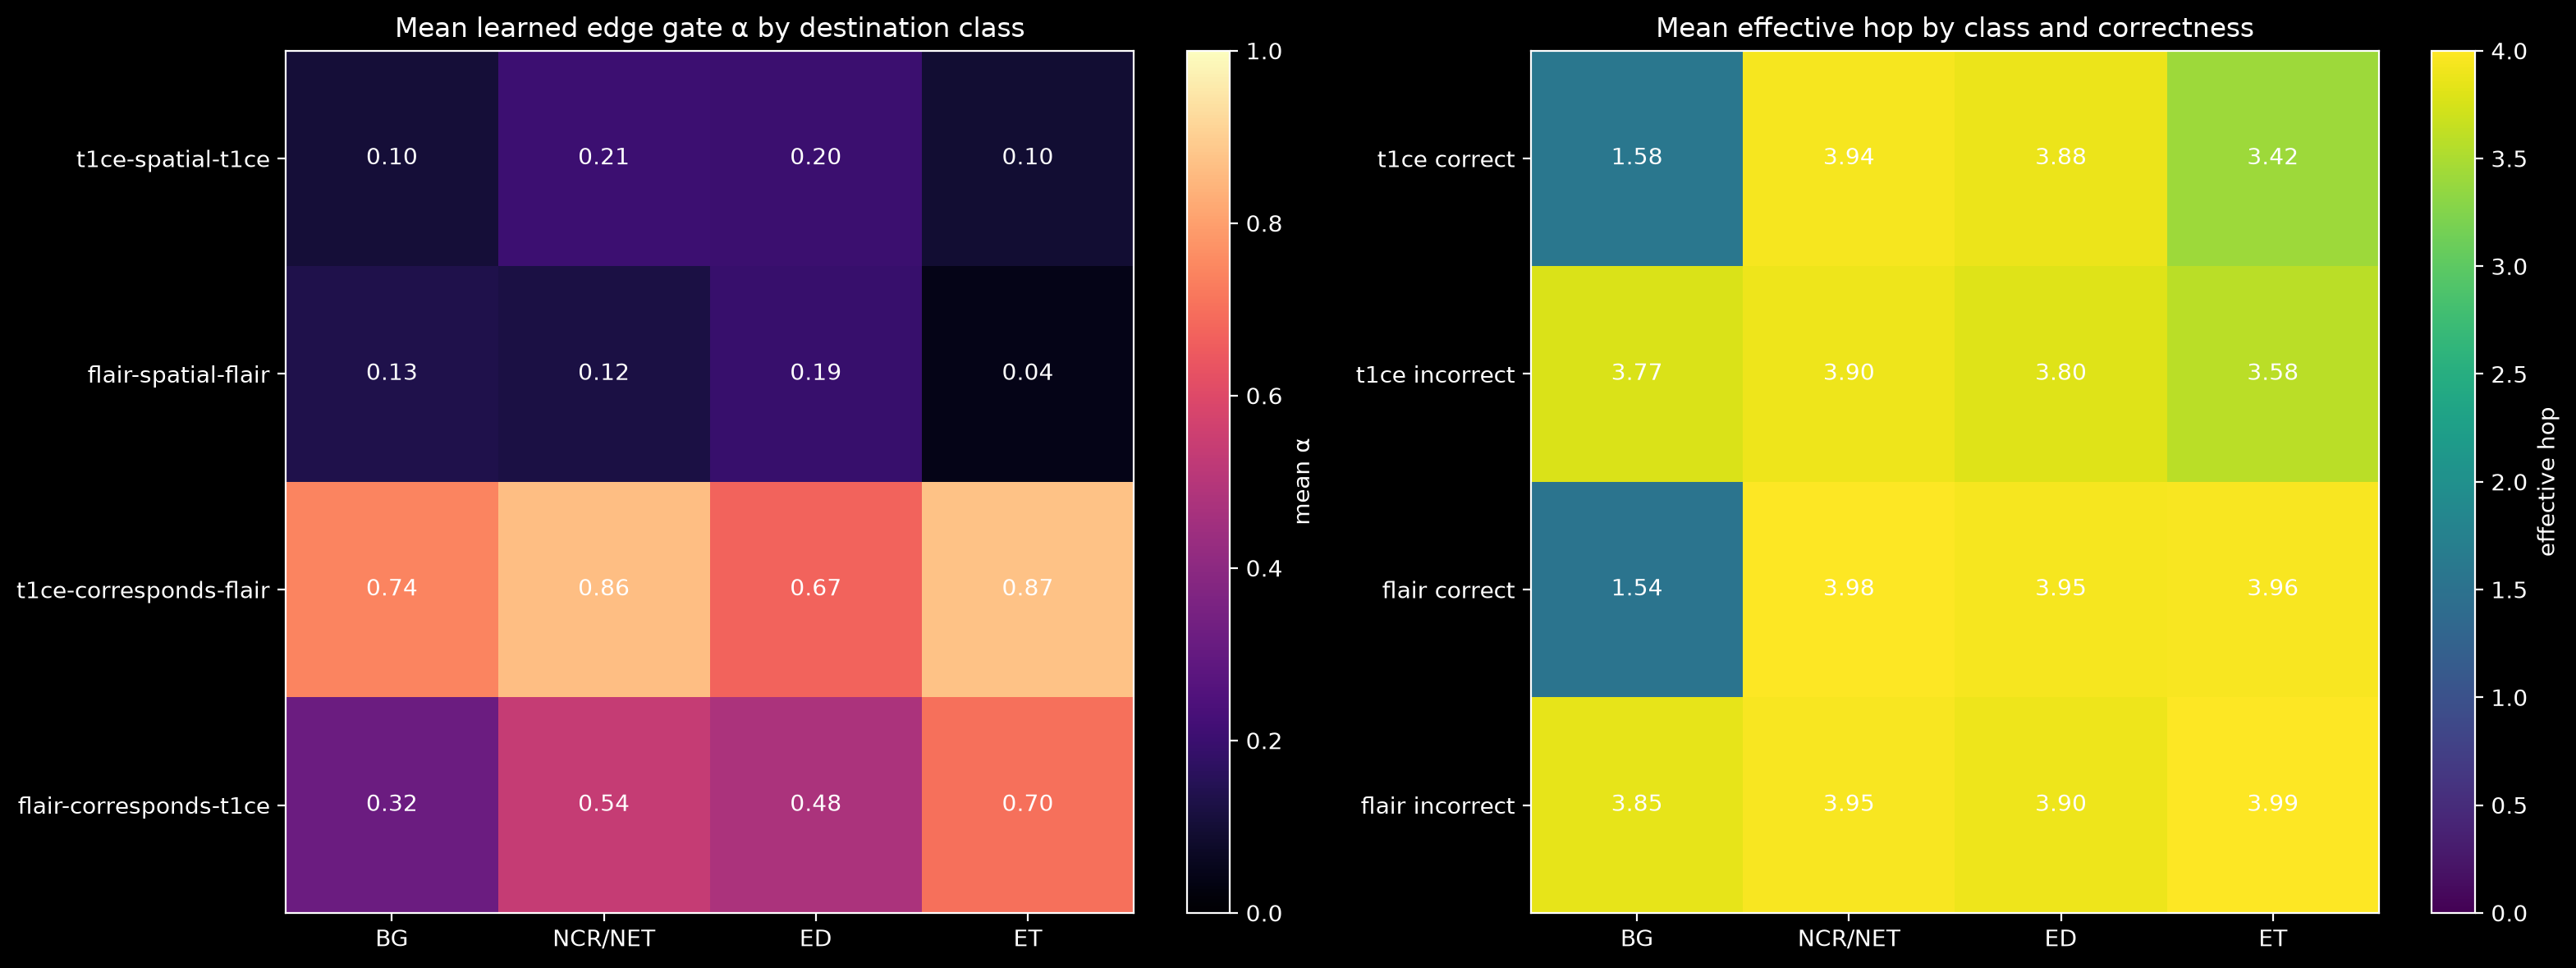

In [ ]:
@torch.no_grad()
def global_graph_explanation_summary(item):
    """Aggregate learned relation gates and effective hops by class and correctness."""
    data, _ = item
    probabilities = xai_predict_probabilities(data.clone())
    predicted = {nt: probabilities[nt].argmax(dim=1).numpy() for nt in NODE_TYPES}
    truth = {nt: data[nt].y.cpu().numpy() for nt in NODE_TYPES}
    gates = base_model.last_edge_gates
    hop_info = base_model.last_hop_info
    relation_names = [xai_relation_name(et) for et in base_model.metadata[1]]
    gate_matrix = np.full((len(relation_names), NUM_CLASSES), np.nan, dtype=np.float32)

    for relation_index, edge_type in enumerate(base_model.metadata[1]):
        if not gates:
            continue
        step_values = [step[edge_type].cpu().numpy() for step in gates if edge_type in step]
        if not step_values:
            continue
        alpha = np.mean(np.stack(step_values), axis=0)
        destinations = data[edge_type].edge_index[1].cpu().numpy()
        destination_class = predicted[edge_type[2]][destinations]
        for cls in range(NUM_CLASSES):
            mask = destination_class == cls
            if mask.any():
                gate_matrix[relation_index, cls] = float(alpha[mask].mean())

    hop_matrix = np.full((len(NODE_TYPES) * 2, NUM_CLASSES), np.nan, dtype=np.float32)
    hop_rows = []
    for node_type_index, nt in enumerate(NODE_TYPES):
        effective = hop_info[nt]["effective_hop"].cpu().numpy() if hop_info else np.full(len(predicted[nt]), HOPS)
        correct = predicted[nt] == truth[nt]
        for correctness_index, (name, correctness) in enumerate([("correct", True), ("incorrect", False)]):
            row = node_type_index * 2 + correctness_index
            hop_rows.append(f"{nt} {name}")
            for cls in range(NUM_CLASSES):
                mask = (predicted[nt] == cls) & (correct == correctness)
                if mask.any():
                    hop_matrix[row, cls] = float(effective[mask].mean())

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    gate_image = axes[0].imshow(gate_matrix, cmap="magma", aspect="auto", vmin=0, vmax=1)
    axes[0].set(xticks=range(NUM_CLASSES), xticklabels=CLASS_NAMES,
                yticks=range(len(relation_names)), yticklabels=relation_names,
                title="Mean learned edge gate α by destination class")
    for row in range(gate_matrix.shape[0]):
        for col in range(gate_matrix.shape[1]):
            if np.isfinite(gate_matrix[row, col]):
                axes[0].text(col, row, f"{gate_matrix[row, col]:.2f}", ha="center", va="center", color="white")
    fig.colorbar(gate_image, ax=axes[0], label="mean α")

    hop_image = axes[1].imshow(hop_matrix, cmap="viridis", aspect="auto", vmin=0, vmax=K_MAX)
    axes[1].set(xticks=range(NUM_CLASSES), xticklabels=CLASS_NAMES,
                yticks=range(len(hop_rows)), yticklabels=hop_rows,
                title="Mean effective hop by class and correctness")
    for row in range(hop_matrix.shape[0]):
        for col in range(hop_matrix.shape[1]):
            if np.isfinite(hop_matrix[row, col]):
                axes[1].text(col, row, f"{hop_matrix[row, col]:.2f}", ha="center", va="center", color="white")
    fig.colorbar(hop_image, ax=axes[1], label="effective hop")
    fig.tight_layout()
    plt.show()
    return {"relation_names": relation_names, "gate_by_class": gate_matrix,
            "hop_rows": hop_rows, "effective_hop_by_class": hop_matrix}


graph_explanation_summary = global_graph_explanation_summary(test_items[0]) if test_items else None

## 19. How to interpret and report the explanations

The three explanation channels answer different questions and should be reported together:

1. **Exact modality Shapley:** which MRI modality supports or opposes a node's predicted tissue class? This is a coalition-based perturbation explanation adapted from Saueressig et al. Exactness applies to the four modality groups and the chosen background-replacement game—not to every individual intensity statistic.
2. **Adaptive edge gate $\alpha$:** which spatial or cross-modal messages did the propagation module permit strongly? This is a native model quantity, but a high gate is not by itself causal proof; it should be interpreted alongside modality ablation and prediction changes.
3. **Effective hop $k_{eff}$:** how much graph context did a node select? This measures learned receptive-field depth over the fixed graph, not learned topology.

Recommended figures and tables:

- Four-panel Shapley violin plot by predicted class, modality, and bright/dark intensity, matching the paper's presentation.
- One correctly predicted ET, one incorrect ET, and one edema local explanation graph per test cohort.
- Mean $|\phi|$ by modality and class.
- Mean gate $\alpha$ by relation, class, and correct/incorrect prediction.
- Effective-hop distributions by node type, class, uncertainty quartile, and correctness.
- Sanity check: randomize model weights or labels and verify that explanations change materially.

The local graph is deliberately bounded. Rendering the full approximately 30k-node heterogeneous graph would hide rather than explain its structure. Numeric edge labels are therefore restricted to the 20 strongest displayed edges.

## 20. ET threshold tuning, TTA, and the leakage audit

Three things happen here, in order.

**1. Leakage audit.** The voxel head only refines inside a bounding box. Until now that box was taken from `meta["seg"]` — the ground truth — at evaluation time, which tells the model where the tumour is. This cell reports the same test set scored both ways so the size of that leak is explicit. Only the *predicted-window* column is a reportable result.

**2. `ET_MIN_VOXELS` tuned on validation.** The 300-voxel cut was inherited from nnU-Net-era BraTS practice, not fitted here, and on the last run it *cost* test ET (raw 0.6557 → post-processed 0.6499). It is now swept over `ET_SWEEP_VALUES` on validation and the argmax is carried to test — selected on val, applied once to test, never tuned on test.

**3. Flip TTA.** Eight axis-flip views averaged in probability space. No retraining; it mainly stabilises the cases where a single view is a coin-flip, which is where this pipeline currently bleeds ET.

In [ ]:
if USE_VOXEL_REFINEMENT:
    # ---- 1. Leakage audit: predicted-window vs GT-window on the SAME test set ----
    def _eval_box_mode(items, use_gt_box, tta):
        rows = []
        for _d, _mpath in items:
            _meta = load_meta(_mpath)
            _pred = reconstruct_case_voxel(model, voxel_head, _d, _meta, postprocess=True,
                                           use_gt_box=use_gt_box, tta=tta)
            rows.append(segmentation_metrics(_pred, _meta["seg"]))
        return {k: float(np.mean([r[k] for r in rows])) for k in rows[0]}

    _honest = _eval_box_mode(test_items, use_gt_box=False, tta=False)
    _leaked = _eval_box_mode(test_items, use_gt_box=True, tta=False)

    print("=" * 70)
    print("LEAKAGE AUDIT (test set, same trained voxel head, box source varied)")
    print("=" * 70)
    print(f"Predicted window (honest, reportable) : {fmt_metrics(_honest)}")
    print(f"Ground-truth window (leaked, DO NOT report as a result): {fmt_metrics(_leaked)}")
    print(f"Gap attributable to the leak            : "
          f"WT {_leaked['Dice_WT'] - _honest['Dice_WT']:+.4f}  "
          f"TC {_leaked['Dice_TC'] - _honest['Dice_TC']:+.4f}  "
          f"ET {_leaked['Dice_ET'] - _honest['Dice_ET']:+.4f}")

    # ---- 2. Re-tune ET_MIN_VOXELS on VAL (honest window), carry the pick to TEST ----
    def _et_sweep(items, use_gt_box, tta):
        best_thr, best_et = ET_MIN_VOXELS, -1.0
        table = []
        for thr in ET_SWEEP_VALUES:
            rows = []
            for _d, _mpath in items:
                _meta = load_meta(_mpath)
                _pred = reconstruct_case_voxel(model, voxel_head, _d, _meta, postprocess=True,
                                               use_gt_box=use_gt_box, tta=tta, et_min_voxels=thr)
                rows.append(segmentation_metrics(_pred, _meta["seg"]))
            m = {k: float(np.mean([r[k] for r in rows])) for k in rows[0]}
            table.append((thr, m))
            if m["Dice_ET"] > best_et:
                best_et, best_thr = m["Dice_ET"], thr
        return best_thr, table

    print("\n" + "=" * 70)
    print("ET_MIN_VOXELS sweep on VAL (predicted window, no TTA — selection only)")
    print("=" * 70)
    ET_MIN_VOXELS_TUNED, _sweep_table = _et_sweep(val_items, use_gt_box=False, tta=False)
    for thr, m in _sweep_table:
        marker = "  <-- selected" if thr == ET_MIN_VOXELS_TUNED else ""
        print(f"  thr={thr:4d}: {fmt_metrics(m)}{marker}")
    print(f"\nET_MIN_VOXELS: {ET_MIN_VOXELS} (original) -> {ET_MIN_VOXELS_TUNED} (tuned on VAL)")

    # ---- 3. Final honest TEST numbers: predicted window + tuned threshold + TTA ----
    def _final_eval(items, name):
        rows = []
        for _d, _mpath in items:
            _meta = load_meta(_mpath)
            _pred = reconstruct_case_voxel(model, voxel_head, _d, _meta, postprocess=True,
                                           use_gt_box=False, tta=VOXEL_TTA,
                                           et_min_voxels=ET_MIN_VOXELS_TUNED)
            rows.append(segmentation_metrics(_pred, _meta["seg"]))
        m = {k: float(np.mean([r[k] for r in rows])) for k in rows[0]}
        print(f"{name} mean (predicted window, tuned threshold, TTA={VOXEL_TTA}): {fmt_metrics(m)}")
        return m

    print("\n" + "=" * 70)
    print("FINAL HONEST NUMBERS (no GT leakage, tuned ET threshold, flip TTA)")
    print("=" * 70)
    val_final_metrics = _final_eval(val_items, "VAL")
    test_final_metrics = _final_eval(test_items, "TEST")
else:
    print("Voxel refinement disabled; nothing to audit.")